# Compare usage across multiple words: similarity matrix + PCA dimension analysis

Generalizes the two-word comparison to **N words at once**:

1. Builds an N×N similarity matrix and an N×N pairwise-distinguishability matrix, using **(A) BERT contextual embeddings** and **(B) Word2Vec collocate vectors**.
2. Runs **PCA across all example vectors together** and interprets what each principal component captures — by reading the actual sentences that sit at each axis's extremes, and by seeing where each word's average sits along each axis.

**Input assumption:** one plain-text file per word, one sentence per line, already filtered to only the usage you care about (e.g., as degree modifiers). This notebook does *not* do that filtering — use the Gemini classification prompts for that step first.

In [39]:
for row in en_df_stats.itertuples():
    if abs(row.frequency - row.avg_probability)>0.01:
        print(row.frequency,row.avg_probability,row.modifier)

0.12865988036520096 0.0886836380282773 only
0.022457760520516318 0.0120419197075509 at all
0.013222793577500263 0.0026984811717861 significantly
0.011123937454087521 0.0545488823442718 just
0.003043341378948473 0.0140717089666212 directly


In [38]:
for row in jp_df_stats.itertuples():
    if abs(row.frequency - row.avg_probability)>0.01:
        print(row.frequency,row.avg_probability,row.modifier)

0.06596965536663499 0.0546160304807117 少し
0.05438800295701764 0.0393717214465316 全く
0.04534093709297004 0.0268142442376065 非常に
0.04463688527475622 0.0303519275290453 大変
0.03995494068363432 0.0263490610762692 あまり
0.03316084063787095 0.0208008067743448 ちょっと
0.025944309501179288 0.0085478746439988 これ以上
0.023796951455627133 0.0066209878490839 少なくとも
0.02267046854648502 0.0025579314755038 もう少し
0.01886858872813039 0.001111479496536 十分
0.01506670890977576 0.0024690932105474 どうしても
0.0109832083641356 0.047328966597667 なるべく
0.007779772591262717 0.0199369264908955 さらに


In [ ]:
import pandas as pd
import json
import numpy as np


def average_probability_per_modifier(csv_path, log_all_col="log_all"):
    """
    Reads a combined *_data_logprob_combined.csv file (containing a JSON-encoded
    `log_all` column -- the relative log-probability every candidate modifier
    received at the masked position, for every row), and computes, for each
    candidate modifier, its average PROBABILITY (not log-probability) across
    every row in the dataset.

    This is NOT limited to rows where the modifier was the actual/correct one
    used in that sentence -- since `log_all` contains a score for every
    candidate at every row (the whole candidate set is scored against every
    masked position), this averages a modifier's assigned probability across
    ALL rows, regardless of whether it was the modifier the sentence actually
    used.

    Returns a pandas Series: index = modifier, value = average probability,
    sorted descending.
    """
    df = pd.read_csv(csv_path)

    # parse the JSON string in each row into a dict {modifier: log_relative}
    parsed = df[log_all_col].apply(json.loads)

    # convert to a DataFrame: one column per modifier, one row per sentence
    # (rows/columns not present for a given row -- e.g. if that row's
    # candidate set genuinely differs -- become NaN and are excluded from
    # the mean automatically)
    log_matrix = pd.DataFrame(list(parsed))

    # convert log-probabilities to actual probabilities
    prob_matrix = np.exp(log_matrix)

    # average probability per modifier across all rows, ignoring NaNs
    avg_probs = prob_matrix.mean(axis=0, skipna=True)

    return avg_probs.sort_values(ascending=False)
for lang in ["en", "jp"]:
    path = f"./data/results/{lang}_data_logprob_combinedJul21.csv"
    avg_probs = average_probability_per_modifier(path)

    print(f"\n=== {lang}: average probability per modifier (across all rows) ===")
    print(avg_probs)

    out_path = f"./data/results/{lang}_avg_modifier_probability.csv"
    avg_probs.to_csv(out_path, header=["avg_probability"], encoding="utf-8-sig")
    print(f"Saved to {out_path}")


In [ ]:
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch
import os
import re

templated_sentence_parts = ["If you only meant to make", "One ping only", "working on it further", "are strictly for discussing improvements to their associated", "seemed less than neutral", "|Read this Signpost in full]", "Read this edition in full]", "not sufficiently notable for inclusion in Wikipedia", "a page which you created or substantially contributed to","which you recently created, substantially expanded,","without adequately explaining why","adequately supported by","unsourced or poorly sourced","poorly sourced]","poorly referenced]", "投稿ブロック]]の対象","幅広く利用する事が出来ます"]
# en_df and jp_df are the outputs of get_bert_probs.py combined into one file each
en_df = pd.read_csv("/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/en_data_logprob_combinedJul21.csv")
jp_df = pd.read_csv("/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_data_logprob_combinedJul21.csv")
jp_df = jp_df[~jp_df['log_relative'].isna()]
jp_df = jp_df[~jp_df['sentence'].str.contains('|'.join(re.escape(p) for p in templated_sentence_parts))]
en_df = en_df[~en_df['sentence'].str.contains('|'.join(re.escape(p) for p in templated_sentence_parts))]
en_df = en_df[~en_df['log_relative'].isna()]

# only use the top 20 most frequent modifiers in each language for the analysis
en_top_modifiers = en_df['modifier'].value_counts().nlargest(50).index
jp_top_modifiers = jp_df['modifier'].value_counts().nlargest(50).index

# average PROBABILITY (not log-probability) placed on each modifier across
# every row's full candidate distribution, regardless of whether that
# modifier was the actual/correct one used in that row (see avg_modifier_prob.py)
en_avg_prob = pd.read_csv(
    "/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/en_avg_modifier_probability.csv"
)
jp_avg_prob = pd.read_csv(
    "/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_avg_modifier_probability.csv"
)
# normalize whatever the index/first column got named on export to "modifier"
en_avg_prob.columns = ["modifier", "avg_probability"]
jp_avg_prob.columns = ["modifier", "avg_probability"]


# make table for number of times modifier appears in modifier column, and the average log relative for each modifier
def create_stats_table(df, avg_prob_df):
    modifier_counts = df['modifier'].value_counts().reset_index()
    modifier_counts.columns = ['modifier', 'count']
    # eliminate modifiers with count less than 10
    modifier_counts = modifier_counts[modifier_counts['count'] >= 10]
    df = df[df['modifier'].isin(modifier_counts['modifier'])]
    # frequency is the count of the modifier divided by the total number of rows in the dataframe
    modifier_counts['frequency'] = modifier_counts['count'] / modifier_counts['count'].sum()

    modifier_avg_log_relative = df.groupby('modifier')['log_relative'].mean().reset_index()
    modifier_avg_log_relative.columns = ['modifier', 'avg_log_relative']
 
    modifier_stats = pd.merge(modifier_counts, modifier_avg_log_relative, on='modifier')
    modifier_stats = pd.merge(modifier_stats, avg_prob_df, on='modifier', how='left') # avg_ prob comes from here
    # avg_log_relative now comes from log(avg probability across ALL candidate 
    # scorings for this modifier) rather than the mean of log_relative taken
    # only over rows where the modifier was the one actually used. Taking the
    # log here (rather than assigning the raw probability directly) keeps this
    # column consistent with the log-space math used further down (the
    # frequency-weighted sum and the mutual-info subtraction both assume
    # everything going in is already in log space).
    modifier_stats["log_avg_probability"] = np.log(modifier_stats["avg_probability"])

    # modifier_stats["frequency"] = modifier_stats["count"] / modifier_stats["count"].sum()
    # modifier_stats["log_frequency"] = np.log(modifier_stats["frequency"])
    return modifier_stats


en_df_stats = create_stats_table(en_df[en_df['modifier'].isin(en_top_modifiers)], en_avg_prob)
jp_df_stats = create_stats_table(jp_df[jp_df['modifier'].isin(jp_top_modifiers)], jp_avg_prob)
print(en_df_stats.columns)
# compute average log_relative for each modifier in both languages where it is weighted by the frequency of the modifier in that language
avg_log_frequency_weighted_jp = (jp_df_stats['log_avg_probability'] * jp_df_stats['avg_probability']).sum()
avg_log_frequency_weighted_en = (en_df_stats['log_avg_probability'] * en_df_stats['avg_probability']).sum()
avg_log_relative_weighted_jp = (jp_df_stats['avg_log_relative'] * jp_df_stats['avg_probability']).sum()
avg_log_relative_weighted_en = (en_df_stats['avg_log_relative'] * en_df_stats['avg_probability']).sum()
# print total sentences and count of biggest modifier in each language along with what it is
print("Total sentences in Japanese:", len(jp_df))
print("Total sentences in English:", len(en_df))
print("Average log_relative weighted by frequency for Japanese. This corresponds to average log (P(modifier|context)):", avg_log_relative_weighted_jp)
print("Average log_relative weighted by frequency for English. This corresponds to average log (P(modifier|context)):", avg_log_relative_weighted_en)
print("Average log_frequency weighted by frequency for Japanese. This corresponds to average log P(modifier):", avg_log_frequency_weighted_jp)
print("Average log_frequency weighted by frequency for English. This corresponds to average log P(modifier):", avg_log_frequency_weighted_en)
print("bigger difference means more shared info between context and modifier")
print("mutual info for Japanese:", avg_log_relative_weighted_jp - avg_log_frequency_weighted_jp)
print("mutual info for English:", avg_log_relative_weighted_en - avg_log_frequency_weighted_en)

Index(['modifier', 'count', 'frequency', 'avg_log_relative', 'avg_probability',
       'log_avg_probability'],
      dtype='object')
Total sentences in Japanese: 32956
Total sentences in English: 9807
Count of biggest modifier in Japanese: 1874 for modifier: 少し
Count of biggest modifier in English: 1226 for modifier: only
Average log_relative weighted by frequency for Japanese. This corresponds to average log (P(modifier|context)): -1.7222778479419272
Average log_relative weighted by frequency for English. This corresponds to average log (P(modifier|context)): -1.366286500237658
Average log_frequency weighted by frequency for Japanese. This corresponds to average log P(modifier): -3.1498098696162837
Average log_frequency weighted by frequency for English. This corresponds to average log P(modifier): -3.212712556986884
bigger difference means more shared info between context and modifier
mutual info for Japanese: 1.4275320216743566
mutual info for English: 1.8464260567492259


In [1]:
import spacy
import pandas as pd

nlp = spacy.load(
    "ja_ginza_electra",
    config={"components": {"compound_splitter": {"split_mode": "C"}}},
)


def modifier_aligns_with_word_boundary(sentence, modifier):
    """
    Uses GiNZA's morphological segmentation to check whether `modifier`'s
    character span in `sentence` lines up exactly with a contiguous run of
    GiNZA tokens -- i.e. the modifier is a "real" word/phrase boundary
    according to a proper Japanese morphological analyzer, not a substring
    that cuts through the middle of a token.

    Returns a dict with:
      - "aligned": bool, True if the modifier's start/end match token boundaries
      - "start_ok": bool, whether the modifier starts exactly at a token start
      - "end_ok": bool, whether the modifier ends exactly at a token end
      - "overlapping_tokens": list of the GiNZA token texts that overlap the
        modifier's character span (useful for inspecting mismatches)
    """
    idx = sentence.find(modifier)
    if idx == -1:
        return {
            "aligned": False,
            "start_ok": False,
            "end_ok": False,
            "overlapping_tokens": [],
            "error": f"{modifier!r} not found in sentence",
        }

    mod_start = idx
    mod_end = idx + len(modifier)

    doc = nlp(sentence)

    overlapping = [
        tok for tok in doc
        if tok.idx < mod_end and (tok.idx + len(tok.text)) > mod_start
    ]

    if not overlapping:
        return {
            "aligned": False,
            "start_ok": False,
            "end_ok": False,
            "overlapping_tokens": [],
            "error": "no overlapping tokens found",
        }

    start_ok = overlapping[0].idx == mod_start
    end_ok = (overlapping[-1].idx + len(overlapping[-1].text)) == mod_end

    return {
        "aligned": start_ok and end_ok,
        "start_ok": start_ok,
        "end_ok": end_ok,
        "overlapping_tokens": [tok.text for tok in overlapping],
    }


if __name__ == "__main__":
    # quick manual test
    examples = [
        ("けっこう分かりやすい表示だと、自分では気に入っていたのですが", "けっこう"),
        ("そして、残念なことに、議論はいささか険悪なかたちで行き詰っております", "いささか"),
    ]
    for sentence, modifier in examples:
        result = modifier_aligns_with_word_boundary(sentence, modifier)
        print(f"sentence: {sentence}")
        print(f"modifier: {modifier}")
        print(result)
        print()

    # example of applying this to a full dataframe before running MLM scoring:
    #
    # jp_data = pd.read_csv("/nlp/scr/ymachino/jp_data.csv")
    # results = jp_data.apply(
    #     lambda row: modifier_aligns_with_word_boundary(row["sentence"], row["modifier"]),
    #     axis=1,
    # )
    # jp_data["boundary_aligned"] = results.apply(lambda r: r["aligned"])
    # jp_data["overlapping_tokens"] = results.apply(lambda r: r["overlapping_tokens"])
    #
    # # rows where the modifier doesn't line up with a real GiNZA word boundary:
    # misaligned = jp_data[~jp_data["boundary_aligned"]]
    # print(f"{len(misaligned)} / {len(jp_data)} rows have a misaligned modifier")
    # misaligned.to_csv("/nlp/scr/ymachino/jp_data_misaligned_modifiers.csv", index=False)

/opt/homebrew/Caskroom/miniconda/base/envs/bert_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/homebrew/Caskroom/miniconda/base/envs/bert_env/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
error We couldn't connect to 'https://huggingface.co' to load this file, couldn't find it in the cached files and it looks like megagonlabs/transformers-ud-japanese-electra-base-ginza-510 is not the path to a directory containing a file named config.json.
Checkout your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/transformers/installat

sentence: けっこう分かりやすい表示だと、自分では気に入っていたのですが
modifier: けっこう
{'aligned': True, 'start_ok': True, 'end_ok': True, 'overlapping_tokens': ['けっこう']}

sentence: そして、残念なことに、議論はいささか険悪なかたちで行き詰っております
modifier: いささか
{'aligned': True, 'start_ok': True, 'end_ok': True, 'overlapping_tokens': ['いささか']}



succeded


In [4]:
import spacy

nlp = spacy.load(
    "ja_ginza_electra",
    config={"components": {"compound_splitter": {"split_mode": "C"}}},
)

sentence = "どうも今では常識になっている[[南京大虐殺]]の否定説を編集する者は無期限ブロックされている利用者Peaceと看做される風潮が流行っているようで"
doc = nlp(sentence)

for token in doc:
    print(f"{token.text!r:15} lemma={token.lemma_:15} pos={token.pos_:8} tag={token.tag_}")

'どう'            lemma=どう              pos=ADV      tag=副詞
'も'             lemma=も               pos=ADP      tag=助詞-係助詞
'今'             lemma=今               pos=NOUN     tag=名詞-普通名詞-副詞可能
'で'             lemma=で               pos=ADP      tag=助詞-格助詞
'は'             lemma=は               pos=ADP      tag=助詞-係助詞
'常識'            lemma=常識              pos=NOUN     tag=名詞-普通名詞-一般
'に'             lemma=に               pos=ADP      tag=助詞-格助詞
'なっ'            lemma=なる              pos=VERB     tag=動詞-非自立可能
'て'             lemma=て               pos=SCONJ    tag=助詞-接続助詞
'いる'            lemma=いる              pos=VERB     tag=動詞-非自立可能
'['             lemma=[               pos=PUNCT    tag=補助記号-括弧開
'['             lemma=[               pos=PUNCT    tag=補助記号-括弧開
'南京'            lemma=南京              pos=PROPN    tag=名詞-固有名詞-地名-一般
'大'             lemma=大               pos=NOUN     tag=接尾辞-名詞的-一般
'虐殺'            lemma=虐殺              pos=NOUN     tag=名詞-普通名詞-サ変可能
']'             lemma=]               

In [82]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch

tokenizer = AutoTokenizer.from_pretrained("cl-tohoku/bert-base-japanese-v3")
model = AutoModelForMaskedLM.from_pretrained("cl-tohoku/bert-base-japanese-v3")
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

cls_id = tokenizer.cls_token_id
sep_id = tokenizer.sep_token_id


def score_word_in_sentence(sentence, target_word):
    """
    PLL-word-l2r log-probability (Kauf & Ivanova, 2023) of `target_word` at its
    position in `sentence`: masks each subword piece left to right, revealing
    prior pieces of the word as their true tokens, and sums the log-probs.
    """
    idx = sentence.find(target_word)
    if idx == -1:
        raise ValueError(f"{target_word!r} not found in sentence")

    prefix = sentence[:idx]
    suffix = sentence[idx + len(target_word):]

    prefix_ids = tokenizer.encode(prefix, add_special_tokens=False)
    print("Prefix IDs:", prefix_ids)

    print("Prefix tokens:", tokenizer.convert_ids_to_tokens(prefix_ids))
    suffix_ids = tokenizer.encode(suffix, add_special_tokens=False)
    print("Suffix IDs:", suffix_ids)
    print("Suffix tokens:", tokenizer.convert_ids_to_tokens(suffix_ids))
    word_ids_full = tokenizer.encode(target_word, add_special_tokens=False)
    prefix_len = len(prefix_ids)
    k = len(word_ids_full)

    log_prob_sum = 0.0
    with torch.inference_mode():
        for i in range(k):
            word_ids = word_ids_full[:i] + [tokenizer.mask_token_id] * (k - i)
            full_ids = [cls_id] + prefix_ids + word_ids + suffix_ids + [sep_id]
            input_ids = torch.tensor([full_ids], device=device)

            target_pos = 1 + prefix_len + i
            logits = model(input_ids).logits[0]
            log_probs = torch.log_softmax(logits[target_pos], dim=-1)
            log_prob_sum += log_probs[word_ids_full[i]].item()

    return log_prob_sum


sentence = "こちらこそいささか口うるさかったようです。"
log_prob = score_word_in_sentence(sentence, "いささか")

print("Log-probability sum:", log_prob)
print("Probability (product across subwords):", torch.exp(torch.tensor(log_prob)).item())

Loading weights: 100%|██████████| 204/204 [00:00<00:00, 29319.74it/s]
[transformers] BertForMaskedLM LOAD REPORT from: cl-tohoku/bert-base-japanese-v3
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Prefix IDs: [15506, 15347]
Prefix tokens: ['こちら', 'こそ']
Suffix IDs: [1196, 7112, 7056, 24990, 7126, 449, 12515, 13037, 385]
Suffix tokens: ['口', '##う', '##る', '##さか', '##っ', 'た', 'よう', 'です', '。']
Log-probability sum: -6.630122538655996
Probability (product across subwords): 0.0013200012035667896


In [44]:
# print sentences with log_relative less than -1 for each modifier in English and Japanese
#print the top 20 sentences with highest log_relative for each modifier in English and Japanese
# sort the dataframes by modifier and log_relative
en_df_sorted = en_df.sort_values(by='log_relative', ascending=True )
jp_df_sorted = jp_df.sort_values(by='log_relative', ascending=True )
# get the top 20 sentences for each modifier in English
en_df_sorted = en_df_sorted[~en_df_sorted['sentence'].str.contains("more than")]
en_df_sorted = en_df_sorted[~en_df_sorted['sentence'].str.contains("you very much")]
jp_df_sorted = jp_df_sorted[~jp_df_sorted['sentence'].str.contains("幅広く")]
jp_df_sorted = jp_df_sorted[~jp_df_sorted['sentence'].str.contains("興味深く")]
# count how many are more than -0.01 in each language
en_count = len(en_df_sorted[en_df_sorted['log_relative'] > -0.1])
jp_count = len(jp_df_sorted[jp_df_sorted['log_relative'] > -0.1])
print("Number of sentences with log_relative > -0.01 in English:", en_count)
print("Number of sentences with log_relative > -0.01 in Japanese:", jp_count)
for i,row in enumerate(en_df_sorted.itertuples()):
    print(row.modifier, row.sentence, row.log_relative)
    if i >= 100:
        break
for i,row in enumerate(jp_df_sorted.itertuples()):
    print(row.modifier, row.sentence, row.log_relative)
    if i >= 100:
        break

Number of sentences with log_relative > -0.01 in English: 1554
Number of sentences with log_relative > -0.01 in Japanese: 1277
strictly :I’ve been supporting him by reviewing and maintaining his Wikipedia page, ensuring that all added information strictly adheres to Wikipedia's content guidelines. -14.855536460876465
merely   Wikipedia is not a place to merely share information, and is not a place for businesses to tell about themselves, their offerings, and their activities. -13.855934143066406
wholly   We don't want to know what it says about itself, we want to know what others wholly unconnected with the organization say about it. -13.66956901550293
wholly   Wikipedia is not a place for organizations to tell about themselves and what they do, we want to know what others wholly unconnected with an organization say about it. -13.50927734375
essentially {{stop}} Above, it was noted that it is [[Wikipedia:Disruptive editing|disruptive]] to continually submit the essentially same page fo

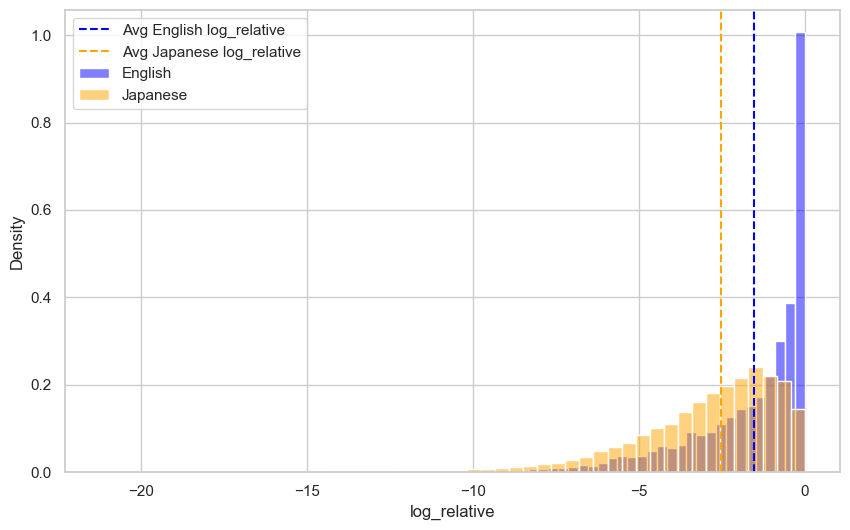

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(en_df['log_relative'], label='English', color='blue', alpha=0.5, stat='density', bins=50)
sns.histplot(jp_df['log_relative'], label='Japanese', color='orange', alpha=0.5, stat='density', bins=50)

plt.axvline(avg_log_relative_weighted_en, color='blue', linestyle='--', label='Avg English log_relative')
plt.axvline(avg_log_relative_weighted_jp, color='orange', linestyle='--', label='Avg Japanese log_relative')

plt.xlabel('log_relative')
plt.ylabel('Density')
plt.legend()
plt.show()

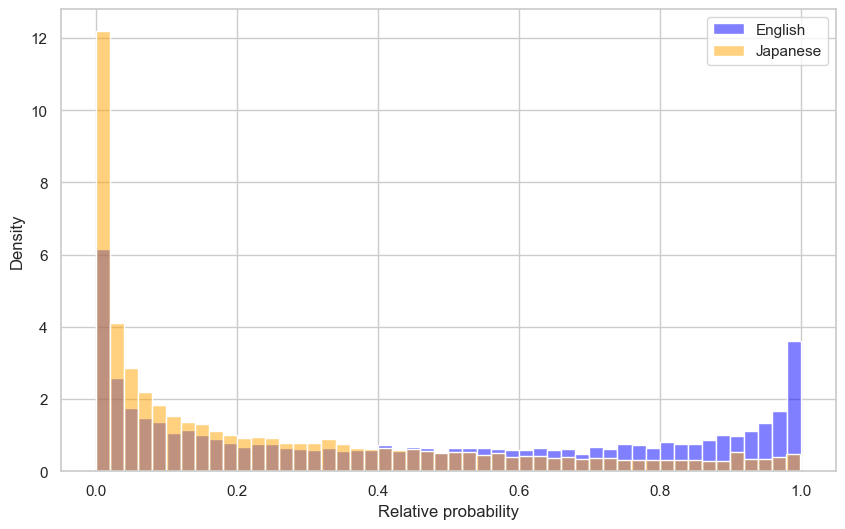

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

en_df['relative_prob'] = np.exp(en_df['log_relative'])
jp_df['relative_prob'] = np.exp(jp_df['log_relative'])

avg_relative_prob_en = en_df['relative_prob'].mean()
avg_relative_prob_jp = jp_df['relative_prob'].mean()

plt.figure(figsize=(10, 6))

sns.histplot(en_df['relative_prob'], label='English', color='blue', alpha=0.5, stat='density', bins=50)
sns.histplot(jp_df['relative_prob'], label='Japanese', color='orange', alpha=0.5, stat='density', bins=50)
plt.xlabel('Relative probability')
plt.ylabel('Density')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch
import os
import re
os.chdir('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/')
jp_data = pd.read_csv("data/results/jp_hedged_sentences_category_checkedJul12.csv")
en_data = pd.read_csv("data/results/en_hedged_sentences_category_checkedJul12.csv")

en_data['masked_sentence'] = en_data.apply(
    lambda row: re.sub(r'\b' + re.escape(row['modifier']) + r'\b', '<mask>', row['sentence']),
    axis=1
)
jp_data['masked_sentence'] = jp_data.apply(
    lambda row: row['sentence'].replace(row['modifier'], '<mask>'),
    axis=1
)

# ignore rows with multiple masks
en_data = en_data[en_data['masked_sentence'].str.count('<mask>') == 1]
jp_data = jp_data[jp_data['masked_sentence'].str.count('<mask>') == 1]

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
model = AutoModelForMaskedLM.from_pretrained("xlm-roberta-base")
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

special_ids = set(tokenizer.all_special_ids)


def score_candidates_at_mask(masked_sentence, candidates):
    """
    Returns: list of (candidate, log_prob_sum) tuples, one per candidate.
    """
    prefix, suffix = masked_sentence.split("<mask>", 1)
 
    prefix_ids = tokenizer.encode(prefix, add_special_tokens=False)
    suffix_ids = tokenizer.encode(suffix, add_special_tokens=False)
    prefix_len = len(prefix_ids)
 
    results = []
    with torch.inference_mode():
        for cand in candidates:
            cand_ids = tokenizer.encode(cand, add_special_tokens=False)
            k = len(cand_ids)
            if k == 0:
                results.append((cand, float("-inf")))
                continue
 
            log_prob_sum = 0.0
            for i in range(k):
                # pieces 0..i-1 revealed (true tokens); piece i and all pieces
                # after it are masked
                word_ids = cand_ids[:i] + [tokenizer.mask_token_id] * (k - i)
 
                full_ids = (
                    [tokenizer.bos_token_id]
                    + prefix_ids
                    + word_ids
                    + suffix_ids
                    + [tokenizer.eos_token_id]
                )
                input_ids = torch.tensor([full_ids], device=device)  # (1, seq_len)
 
                target_pos = 1 + prefix_len + i  # position of piece i (the current target)
 
                logits = model(input_ids).logits[0]                # (seq_len, vocab)
                log_probs = torch.log_softmax(logits[target_pos], dim=-1)
                log_prob_sum += log_probs[cand_ids[i]].item()
 
            results.append((cand, log_prob_sum))
 
    return results


def compare_hedges(masked_sentence, candidates):
    """
    Scores every candidate hedge at the masked position and normalizes them
    against each other with log_softmax, so the result is interpretable as a
    relative preference among the candidate set (matches the same normalization
    style used for the whole-sentence PLL comparison).
    """
    results = score_candidates_at_mask(masked_sentence, candidates)
    log_prob_tensor = torch.tensor([lp for _, lp in results])
    log_relative = torch.log_softmax(log_prob_tensor, dim=0)
    return {cand: rel.item() for (cand, _), rel in zip(results, log_relative)}


for lang, data in [("jp", jp_data), ("en", en_data)]:
    modifier_counts = data['modifier'].value_counts()
    modifiers = modifier_counts[modifier_counts >= 10].index.values
    data = data[data['modifier'].isin(modifiers)].copy()

    data["log_relative"] = None

    for row in data.itertuples():
        rel_scores = compare_hedges(row.masked_sentence, modifiers)
        data.at[row.Index, "log_relative"] = rel_scores[row.modifier]
        break
    # data.to_csv(f"/nlp/scr6/ymachino/{lang}_data_logprob_wordscore.csv", index=False, encoding="utf-8-sig")

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 13139.93it/s]
[transformers] XLMRobertaForMaskedLM LOAD REPORT from: xlm-roberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [18]:
rel_scores

{'further': -10.219128608703613,
 'only': -7.809018135070801,
 'more': -4.2321672439575195,
 'very': -1.7290163040161133,
 'adequately': -10.092395782470703,
 'so': -3.687352180480957,
 'most': -6.844639778137207,
 'in full': -11.135857582092285,
 'much': -7.030919075012207,
 'too': -1.8510026931762695,
 'really': -4.783886909484863,
 'poorly': -7.983488082885742,
 'substantially': -9.035905838012695,
 'quite': -2.464138984680176,
 'especially': -7.798520088195801,
 'fully': -9.994450569152832,
 'well': -9.11928653717041,
 'strictly': -6.084993362426758,
 'at all': -7.48348331451416,
 'enough': -9.624451637268066,
 'a bit': -2.1385650634765625,
 'less than': -5.362539291381836,
 'completely': -3.207737922668457,
 'entirely': -4.083653450012207,
 'the most': -6.047451972961426,
 'almost': -4.2274065017700195,
 'significantly': -9.268315315246582,
 'strongly': -6.139500617980957,
 'a little': -3.133087158203125,
 'just': -6.572705268859863,
 'highly': -6.180821418762207,
 'absolutely': -

## Setup

Run once.

In [ ]:
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch
import os
import re
os.chdir('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/')
jp_data = pd.read_csv("data/results/jp_hedged_sentences_category_checkedJul12.csv")
# delete row if row contains any of the templated_sentence_parts
# if modifier appears less than 10 times, remove it from the dataframe
templated_sentence_parts = ["If you only meant to make", "One ping only", "working on it further", "are strictly for discussing improvements to their associated", "seemed less than neutral", "|Read this Signpost in full]", "Read this edition in full]", "not sufficiently notable for inclusion in Wikipedia", "a page which you created or substantially contributed to","which you recently created, substantially expanded,","without adequately explaining why","adequately supported by","unsourced or poorly sourced","poorly sourced]","poorly referenced]", "投稿ブロック]]の対象"]
jp_data = jp_data[~jp_data['sentence'].str.contains('|'.join(re.escape(p) for p in templated_sentence_parts))]
modifier_counts = jp_data['modifier'].value_counts()
jp_modifiers = modifier_counts[modifier_counts >= 10].index.values
jp_data = jp_data[jp_data['modifier'].isin(jp_modifiers)]
jp_data.to_csv("data/results/jp_hedged_sentences_category_checkedJul12_filtered.csv", index=False, encoding="utf-8-sig")

en_data = pd.read_csv("data/results/en_hedged_sentences_category_checkedJul12.csv")
# delete row if row contains any of the templated_sentence_parts
# if modifier appears less than 10 times, remove it from the dataframe
templated_sentence_parts = ["If you only meant to make", "One ping only", "working on it further", "are strictly for discussing improvements to their associated", "seemed less than neutral", "|Read this Signpost in full]", "Read this edition in full]", "not sufficiently notable for inclusion in Wikipedia", "a page which you created or substantially contributed to","which you recently created, substantially expanded,","without adequately explaining why","adequately supported by","unsourced or poorly sourced","poorly sourced]","poorly referenced]", "投稿ブロック]]の対象"]
en_data = en_data[~en_data['sentence'].str.contains('|'.join(re.escape(p) for p in templated_sentence_parts))]
modifier_counts = en_data['modifier'].value_counts()
en_modifiers = modifier_counts[modifier_counts >= 10].index.values
en_data = en_data[en_data['modifier'].isin(en_modifiers)]
en_data.to_csv("data/results/en_hedged_sentences_category_checkedJul12_filtered.csv", index=False, encoding="utf-8-sig")


In [ ]:
import re

en_data['masked_sentence'] = en_data.apply(
    lambda row: re.sub(r'\b' + re.escape(row['modifier']) + r'\b', '<mask>', row['sentence']),
    axis=1
)
jp_data['masked_sentence'] = jp_data.apply(
    lambda row: row['sentence'].replace(row['modifier'], '<mask>'),
    axis=1
)
# ignore row with multiple masks
en_data = en_data[en_data['masked_sentence'].str.count('<mask>') == 1]  
jp_data = jp_data[jp_data['masked_sentence'].str.count('<mask>') == 1]
for row in jp_data.itertuples():
    print(row.masked_sentence,row.modifier)
    if row.Index > 10:
        break
# print(jp_data.head())

10491
9831
33581
32997
あなたが現在ご利用になっております[[利用者:Kst01/ユーザーボックス 利用鉄道|鉄道利用ユーザーボックス]]についてですが、諸事情により<mask>削除されたため、お手数ですがお早目の取り外しをお願いします。 全て
<mask>の場合、即座に履歴を書いておけば大丈夫になるので私がやっておきました。 ほとんど
もしこの利用者名でもかまわなければ、<mask>する必要はありません。 何も
なお、このメッセージは主に利用者‐会話ページに<mask>記入されていない方に投稿しております。 何も
なお、このメッセージは<mask>利用者‐会話ページに何も記入されていない方に投稿しております。 主に
:削除対象となるような「重要な記載もれ！」をしておりましたご連絡、<mask>ありがとうございます。 本当に
寒波星人さんの利用者ページより拝見いたしましたところすばらしい翻訳記事を<mask>ご執筆されておられまして、はじめての翻訳作業参加なのですが、お手本を探しておりましたので、是非、閲覧させていただき、勉強させていただきたく存じます。 たくさん
僕が（投稿者本人以外が）移動をすると、要約欄への書き込みなど<mask>ややこしい部分があるので、できればあなたに移動をしていただきたいと思います。 いろいろ
::[[Wikipedia:井戸端 (告知)]]の方は別の人に取り消されましたので、投稿した内容と<mask>同じ内容を[[Wikipedia:井戸端]]に書くだけでいいです。 ほぼ
[[ノート:ドラゴンボールの登場人物]]に関してですが、[[Wikipedia:礼儀を忘れない]]を<mask>お読みになられた上で冷静な対応を望むものであります。 良く
記事を<mask>よい方向へ持っていきたいと言う考えにおいては皆が同じである事を頭に入れてください。 より


In [23]:
len(jp_modifiers)

118

In [ ]:
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch
import os
import re
en_data['masked_sentence'] = en_data.apply(
    lambda row: re.sub(r'\b' + re.escape(row['modifier']) + r'\b', '<mask>', row['sentence']),
    axis=1
)
jp_data['masked_sentence'] = jp_data.apply(
    lambda row: row['sentence'].replace(row['modifier'], '<mask>'),
    axis=1
)
# ignore row with multiple masks
en_data = en_data[en_data['masked_sentence'].str.count('<mask>') == 1]  
jp_data = jp_data[jp_data['masked_sentence'].str.count('<mask>') == 1]

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
model = AutoModelForMaskedLM.from_pretrained("xlm-roberta-base")
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

special_ids = set(tokenizer.all_special_ids)  # set lookup instead of list

def pll_score(sentence):
    input_ids = tokenizer(sentence, return_tensors="pt").input_ids[0]
    positions = [i for i in range(input_ids.size(0)) if input_ids[i].item() not in special_ids]
    if not positions:
        return 0.0, 0

    n = len(positions)
    # build a batch of n copies of the sentence, one mask per row
    batch = input_ids.unsqueeze(0).repeat(n, 1).to(device)      # (n, seq_len)
    true_token_ids = input_ids[positions].to(device)             # (n,)
    row_idx = torch.arange(n, device=device)
    pos_idx = torch.tensor(positions, device=device)
    batch[row_idx, pos_idx] = tokenizer.mask_token_id

    with torch.inference_mode():
        logits = model(batch).logits                             # (n, seq_len, vocab)
        logits_at_mask = logits[row_idx, pos_idx]                 # (n, vocab)
        log_probs = torch.log_softmax(logits_at_mask, dim=-1)
        token_log_probs = log_probs[row_idx, true_token_ids]      # (n,)

    return token_log_probs.sum().item(), n

for lang, data in [("jp",jp_data), ("en", en_data)]:
    modifier_counts = data['modifier'].value_counts()
    modifiers = modifier_counts[modifier_counts >= 10].index.values
    data = data[data['modifier'].isin(modifiers)]
    modifier_to_index = {mod: idx for idx, mod in enumerate(modifiers)}
    data["log_relative"] = None
    for row in data.itertuples():
        # sentences contain all combinations of replacements of <mask> with modifier in modifiers
        sentences = [row.masked_sentence.replace("<mask>", mod) for mod in modifiers]
        results = []
        for s in sentences:
            total, n = pll_score(s)
            avg = total / n
            results.append((s, total, n, avg))
        avg_tensor = torch.tensor([r[3] for r in results])
        log_relative = torch.log_softmax(avg_tensor, dim=0)
        # store the log_relative for the index which is that of row.modifier
        modifier_to_index = {mod: idx for idx, mod in enumerate(modifiers)}
        data.at[row.Index, "log_relative"] = log_relative[modifier_to_index[row.modifier]].item()
        break
    break


Loading weights: 100%|██████████| 202/202 [00:00<00:00, 13192.92it/s]
[transformers] XLMRobertaForMaskedLM LOAD REPORT from: xlm-roberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# make a dict from modifier to it's position in en_modifiers
modifier_to_index = {mod: idx for idx, mod in enumerate(en_modifiers)}
en_data["log_relative"] = None
for row in en_data.itertuples():
    # sentences contain all combinations of replacements of <mask> with modifier in en_modifiers
    sentences = [row.masked_sentence.replace("<mask>", mod) for mod in en_modifiers]
    results = []
    for s in sentences:
        total, n = pll_score(s)
        avg = total / n
        results.append((s, total, n, avg))
    avg_tensor = torch.tensor([r[3] for r in results])
    log_relative = torch.log_softmax(avg_tensor, dim=0)
    # store the log_relative for the index which is that of row.modifier
    en_data.at[row.Index, "log_relative"] = log_relative[modifier_to_index[row.modifier]].item()
    print(en_data.at[row.Index, "log_relative"])
    # break after 10 rows for testing
    if row.Index >= 10:
        break

# results = []
# for s in sentences:
#     total, n = pll_score(s)
#     avg = total / n
#     results.append((s, total, n, avg))

# # Relative probability across this candidate set, using length-normalized avg PLL
# avg_tensor = torch.tensor([r[3] for r in results])
# log_relative = torch.log_softmax(avg_tensor, dim=0)

# print(f"{'sentence':30} {'total PLL':>10} {'tokens':>7} {'avg/token':>10} {'relative %':>11}")
# for (s, total, n, avg), rel in sorted(zip(results, relative), key=lambda x: -x[1]):
#     print(f"{s:30} {total:10.3f} {n:7d} {avg:10.3f} {rel.item()*100:10.2f}%")



-4.097360610961914
-4.075559616088867
-4.059088230133057
-4.078457832336426
-3.957451581954956
-4.0771942138671875
-3.954179048538208
-4.097136497497559
-3.7796852588653564


KeyboardInterrupt: 

In [ ]:
print(log_relative)
print("modifier {}","sentence",modifier_to_index[row.modifier])

tensor([-4.5214, -4.4582, -4.1628, -4.1410, -4.1189, -4.2811, -4.2967, -4.4220,
        -4.4431, -4.2280, -4.3025, -4.3370, -4.2079, -4.2129, -4.3805, -4.4254,
        -4.5129, -4.1442, -4.2036, -4.5312, -4.1198, -4.0720, -4.0974, -4.1307,
        -4.2332, -4.1544, -4.4519, -4.2282, -4.3599, -4.1677, -4.2880, -4.2340,
        -4.3141, -4.2770, -4.2132, -4.3180, -3.9466, -4.0650, -4.1702, -4.2180,
        -4.2724, -4.1811, -4.2050, -4.1284, -4.3238, -4.2954, -4.2820, -3.9719,
        -4.2896, -4.3246, -4.1944, -4.3105, -4.4634, -3.9573, -4.1473, -4.0561,
        -4.0962, -4.4107, -4.3265, -4.1665, -4.3179, -4.2457, -4.0436, -4.1641,
        -4.0800, -4.5095, -4.0863, -4.1085, -4.4775])
22


In [11]:
import pandas as pd
import re
df = pd.read_csv("data/results/en_hedged_sentences_category_checkedJul12.csv")
templated_sentence_parts = ["If you only meant to make", "One ping only", "working on it further", "are strictly for discussing improvements to their associated", "seemed less than neutral", "|Read this Signpost in full]", "Read this edition in full]", "not sufficiently notable for inclusion in Wikipedia", "a page which you created or substantially contributed to","which you recently created, substantially expanded,","without adequately explaining why","adequately supported by","unsourced or poorly sourced","poorly sourced]","poorly referenced]", "投稿ブロック]]の対象"]
df=df[~df['sentence'].str.contains('|'.join(re.escape(p) for p in templated_sentence_parts))]
for index, row in df.iterrows():
    print(f"degree modifier: {row.modifier},","sentence:",row.sentence)
    if index>500:
        break

degree modifier: rather, sentence: One thing: I see that you have started editing a rather contentious topic: the biography of [[George Floyd]].
degree modifier: more, sentence:  It's usually advisable to stick to less controversial topics until you're more experienced with the ins and outs of editing Wikipedia.
degree modifier: closely, sentence: svg |imagesize=50px | bg = #E5F8FF | text  = You have recently edited a page related to '''post-1992 politics of the United States and closely related people''', a topic designated as '''''[[WP:AC/CT|contentious]]'''''.
degree modifier: more, sentence:  When editing a contentious topic, Wikipedia's norms and policies are more strictly enforced, and Wikipedia [[WP:ADMIN|administrators]] have an expanded level of powers and discretion in order to reduce disruption to the project.
degree modifier: strictly, sentence:  When editing a contentious topic, Wikipedia's norms and policies are more strictly enforced, and Wikipedia [[WP:ADMIN|administrat

In [ ]:
# download /Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_hedged_sentences_modifier_checked.csv
import pandas as pd

jp_modifier_checked = pd.read_csv("data/results/en_hedged_sentences_category_checkedJul12.csv")
# order modifiers by frequency
jp_modifier_checked["modifier"].value_counts().sort_values(ascending=False)
print(jp_modifier_checked["modifier"].value_counts().sort_values(ascending=False))

modifier
further           2114
only              1559
more              1190
very              1184
adequately         834
                  ... 
sorta                1
comparatively        1
proportionally       1
marginally           1
downright            1
Name: count, Length: 113, dtype: int64


## Inputs

List every word you want to compare and the file with its example sentences (one sentence per line). Add as many entries as you like — the rest of the notebook works for any number of words.

In [7]:
# read csv
df = pd.read_csv("/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_hedged_sentencesJune26.csv")  
# this has columns hedge and sentence
words = df['hedge'].unique().tolist()

## Shared helper functions

Reused for both BERT vectors and Word2Vec vectors — they only care about a `{word: array_of_vectors}` dictionary.

In [68]:
def check_no_empty(vectors_by_word):
    """
    Raise a clear error (instead of a cryptic NaN error inside sklearn) if
    any word ended up with zero vectors -- this usually means the word was
    never actually located in its own example sentences (e.g. a tokenizer
    mismatch), so its "centroid" would be NaN.
    """
    empty = [w for w, v in vectors_by_word.items() if len(v) == 0]
    if empty:
        raise ValueError(
            f"These words have zero extracted vectors, so their centroid would be NaN: {empty}. "
            "Check that the word actually appears in its example sentences and that the "
            "tokenizer/offset matching is finding it."
        )


def centroid_similarity_matrix(vectors_by_word):
    """N x N cosine similarity between each word's centroid (mean) vector."""
    words = list(vectors_by_word.keys())
    centroids = np.vstack([vectors_by_word[w].mean(axis=0) for w in words])
    sim = cosine_similarity(centroids)
    return pd.DataFrame(sim, index=words, columns=words)


def pairwise_classifier_accuracy_matrix(vectors_by_word, cv=5):
    """
    N x N matrix of 5-fold CV accuracy distinguishing word i's vectors from
    word j's vectors. Near 0.50 (chance) = the pair is used near-interchangeably.
    Near 1.00 = the pair occupies clearly distinct usage niches.
    """
    words = list(vectors_by_word.keys())
    n = len(words)
    mat = np.full((n, n), np.nan)
    for i in range(n):
        for j in range(i + 1, n):
            X = np.vstack([vectors_by_word[words[i]], vectors_by_word[words[j]]])
            y = np.array([0] * len(vectors_by_word[words[i]]) + [1] * len(vectors_by_word[words[j]]))
            clf = LogisticRegression(max_iter=1000)
            scores = cross_val_score(clf, X, y, cv=cv)
            mat[i, j] = mat[j, i] = scores.mean()
    return pd.DataFrame(mat, index=words, columns=words)


def plot_matrix(df, title, vmin=None, vmax=None, cmap="viridis"):
    fig, ax = plt.subplots(figsize=(1.3 * len(df) + 2, 1.1 * len(df) + 2))
    im = ax.imshow(df.values, vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_xticks(range(len(df.columns)))
    ax.set_xticklabels(df.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(df.index)))
    ax.set_yticklabels(df.index)
    for i in range(len(df.index)):
        for j in range(len(df.columns)):
            val = df.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        color="white" if val < (vmax or 1) * 0.7 else "black", fontsize=8)
    fig.colorbar(im, ax=ax, label=title)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_pca_scatter(vectors_by_word, title, xlim=None, ylim=None):
    """
    Fits a fresh 2D PCA on whatever vectors are passed in (so calling this
    with a single {word: vectors} dict gives that word's own local PCA,
    useful for inspecting its internal spread/shape). Pass xlim/ylim to
    keep the axis scale consistent across separate per-word calls so the
    plots are visually comparable. Returns (coords, labels_all) so callers
    can look up which points sit at the extremes.
    """
    words = list(vectors_by_word.keys())
    X_all = np.vstack([vectors_by_word[w] for w in words])
    labels_all = np.concatenate([[w] * len(vectors_by_word[w]) for w in words])
    coords = PCA(n_components=2).fit_transform(X_all)

    plt.figure(figsize=(7, 6))
    for w in words:
        mask = labels_all == w
        plt.scatter(coords[mask, 0], coords[mask, 1], label=w, alpha=0.6)
    plt.legend()
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    if xlim is not None:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)
    plt.show()
    return coords, labels_all



def fit_pca_projection(vectors_by_word, n_components=2):
    """
    Fit PCA ONCE on all words' vectors pooled together, and return the fitted
    pca object, the projected coords for every example, and which word each
    row belongs to. Reuse the same `coords`/`labels_all` for every subplot
    (rather than refitting PCA per word) so that PC1/PC2 mean the same thing
    in every plot and each word's dots can be compared to the full space.
    """
    words = list(vectors_by_word.keys())
    X_all = np.vstack([vectors_by_word[w] for w in words])
    labels_all = np.concatenate([[w] * len(vectors_by_word[w]) for w in words])
    pca = PCA(n_components=n_components)
    coords = pca.fit_transform(X_all)
    return pca, coords, labels_all


def plot_pca_scatter_precomputed(coords, labels_all, words_to_show, title, xlim=None, ylim=None,
                                  all_words_faint=True):
    """
    Plot a subset of words (words_to_show) using an already-fitted PCA
    projection (coords/labels_all from fit_pca_projection), so the axes are
    identical across every call. Optionally draws every other word's point
    faintly in the background for spatial context.
    """
    plt.figure(figsize=(7, 6))
    if all_words_faint:
        other_mask = ~np.isin(labels_all, words_to_show)
        plt.scatter(coords[other_mask, 0], coords[other_mask, 1],
                    color="lightgray", alpha=0.3, label="other words")
    for w in words_to_show:
        mask = labels_all == w
        plt.scatter(coords[mask, 0], coords[mask, 1], label=w, alpha=0.7)
    plt.legend()
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    if xlim is not None:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)
    plt.show()

## Part A: BERT-based contextual embedding comparison

The same word gets a different vector depending on the sentence it appears in. Pulling the vector for each target word out of every one of its example sentences gives a cloud of points per word; comparing those clouds pairwise shows how similar (or distinct) each pair's actual usage is.

In [14]:
def load_bert(model_name="cl-tohoku/bert-base-japanese-v3"):
    from transformers import AutoTokenizer, AutoModel
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name, output_hidden_states=True)
    model.eval()
    return tokenizer, model


def _reconstruct_offsets(tokenizer, sentence, raw_tokens):
    """
    cl-tohoku/bert-base-japanese-* ships a "slow" (MeCab-based) tokenizer,
    which does not support return_offsets_mapping. This manually walks the
    subword tokens and finds each one's character span in the original
    sentence, so we can later select tokens by character position instead
    of by exact token-sequence matching.

    Character-position matching (rather than matching the target word's own
    tokenization) is important because MeCab's morpheme segmentation is
    context-dependent: the same word (e.g. 本当に) can be split into one
    token or two (本当 + に) depending on the surrounding sentence.
    """
    import unicodedata

    offsets = []
    cursor = 0
    for tok in raw_tokens:
        piece = tok[2:] if tok.startswith("##") else tok
        if not piece or piece in ("[UNK]",):
            offsets.append(None)
            continue

        idx = sentence.find(piece, cursor)
        if idx == -1:
            norm_sent = unicodedata.normalize("NFKC", sentence)
            norm_piece = unicodedata.normalize("NFKC", piece)
            idx = norm_sent.find(norm_piece, cursor)
            if idx == -1:
                idx = norm_sent.find(norm_piece)
        if idx == -1:
            offsets.append(None)
            continue

        offsets.append((idx, idx + len(piece)))
        cursor = idx + len(piece)
    return offsets


def get_bert_vectors(sentences, target_word, tokenizer, model, max_length=512):
    """
    For each sentence, locate the *character span* of target_word, find every
    subword token whose span overlaps it (there may be 1 or more -- e.g.
    本当に may come out as one token or as 本当 + に depending on context),
    and return the mean-pooled hidden state (average of the last 4 layers,
    averaged again across those tokens) for that occurrence. Also returns
    the sentence it came from (for later interpretation of PCA axes).
    Returns (vectors: (N, hidden), kept_sentences: list[str]).

    Sentences longer than `max_length` tokens are truncated (BERT's position
    embeddings only go up to 512) -- raw_tokens is derived from the already
    -truncated encoding so offsets always line up with what's actually fed
    to the model. If truncation happens to cut off the target word, that
    sentence is skipped (counted separately below) rather than erroring.

    If the word appears more than once in a sentence, only the first
    occurrence is used.
    """
    import torch

    vectors, kept_sentences = [], []
    skipped = 0
    truncated_count = 0
    for sent in sentences:
        idx = sent.find(target_word)
        if idx == -1:
            skipped += 1
            continue
        target_start, target_end = idx, idx + len(target_word)

        enc = tokenizer(sent, return_tensors="pt", truncation=True, max_length=max_length)
        input_ids = enc["input_ids"][0]
        all_tokens = tokenizer.convert_ids_to_tokens(input_ids)
        raw_tokens = all_tokens[1:-1]  # strip [CLS] / [SEP]

        if input_ids.shape[0] >= max_length:
            truncated_count += 1

        offsets = _reconstruct_offsets(tokenizer, sent, raw_tokens)

        token_positions_in_raw = [
            i for i, off in enumerate(offsets)
            if off is not None and off[0] < target_end and off[1] > target_start
        ]
        if not token_positions_in_raw:
            skipped += 1
            continue

        # standard encoding is [CLS] + raw_tokens + [SEP], so raw index i -> encoded index i+1
        token_positions = [p + 1 for p in token_positions_in_raw]

        with torch.no_grad():
            out = model(**enc)

        hidden_states = torch.stack(out.hidden_states[-4:]).mean(0)[0]
        word_vec = hidden_states[token_positions].mean(0).numpy()
        vectors.append(word_vec)
        kept_sentences.append(sent)

    if skipped:
        print(f"[BERT] skipped {skipped} sentence(s) where '{target_word}' couldn't be reliably located")
    if truncated_count:
        print(f"[BERT] {truncated_count} sentence(s) were truncated to {max_length} tokens "
              f"(if the target word fell past the cutoff, that sentence is included in the skipped count above)")
    return np.array(vectors), kept_sentences


In [15]:
tokenizer, bert_model = load_bert()

bert_vectors_by_word = {}
bert_sentences_by_word = {}
for w in words:
    print(f"Extracting BERT vectors for {w}...")
    # sents are all 
    df_filtered = df[df['hedge'] == w]
    sents = df_filtered['sentence'].tolist()
    vecs, kept = get_bert_vectors(sents, w, tokenizer, bert_model)
    bert_vectors_by_word[w] = vecs
    bert_sentences_by_word[w] = kept


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 35791.87it/s]
[transformers] BertModel LOAD REPORT from: cl-tohoku/bert-base-japanese-v3
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting BERT vectors for やや...
[BERT] skipped 1 sentence(s) where 'やや' couldn't be reliably located
[BERT] 1 sentence(s) were truncated to 512 tokens (if the target word fell past the cutoff, that sentence is included in the skipped count above)
Extracting BERT vectors for 少し...
[BERT] skipped 2 sentence(s) where '少し' couldn't be reliably located
[BERT] 5 sentence(s) were truncated to 512 tokens (if the target word fell past the cutoff, that sentence is included in the skipped count above)
Extracting BERT vectors for あまり...
[BERT] skipped 5 sentence(s) where 'あまり' couldn't be reliably located
[BERT] 11 sentence(s) were truncated to 512 tokens (if the target word fell past the cutoff, that sentence is included in the skipped count above)
Extracting BERT vectors for 大変...
[BERT] skipped 2 sentence(s) where '大変' couldn't be reliably located
[BERT] 5 sentence(s) were truncated to 512 tokens (if the target word fell past the cutoff, that sentence is included in the skipped count above)
E

In [16]:
check_no_empty(bert_vectors_by_word)
bert_sim_matrix = centroid_similarity_matrix(bert_vectors_by_word)
bert_sim_matrix


,やや,少し,あまり,大変,ちょっと,十分,かなり,結構,相当,非常に,...,とても,それなり,ずいぶん,ある程度,若干,とっても,わりと,いささか,すごく,ちょっぴり
やや,1.000000,0.822927,0.773649,0.723237,0.820715,0.734385,0.850398,0.667534,0.764439,0.729994,...,0.762616,0.683792,0.795211,0.708628,0.883344,0.676638,0.793096,0.824240,0.695675,0.751870
少し,0.822927,1.000000,0.760841,0.697786,0.903662,0.724731,0.820458,0.688408,0.743695,0.686143,...,0.731530,0.704462,0.732142,0.764815,0.856970,0.634773,0.767314,0.717682,0.697234,0.732821
あまり,0.773649,0.760841,1.000000,0.715343,0.767239,0.800539,0.864148,0.678251,0.778840,0.773146,...,0.800949,0.734417,0.740715,0.749308,0.759250,0.691909,0.812342,0.739053,0.768382,0.695152
大変,0.723237,0.697786,0.715343,1.000000,0.716426,0.727456,0.794202,0.777335,0.728110,0.837202,...,0.878343,0.640925,0.663635,0.630580,0.715154,0.653534,0.710378,0.696949,0.794089,0.655340
ちょっと,0.820715,0.903662,0.767239,0.716426,1.000000,0.721251,0.829012,0.700680,0.738166,0.691813,...,0.771661,0.672892,0.755715,0.710663,0.832035,0.651295,0.791128,0.783365,0.748763,0.772265
十分,0.734385,0.724731,0.800539,0.727456,0.721251,1.000000,0.785027,0.701954,0.800456,0.714188,...,0.721329,0.738100,0.703418,0.753926,0.764599,0.663092,0.795127,0.710118,0.682744,0.643268
かなり,0.850398,0.820458,0.864148,0.794202,0.829012,0.785027,1.000000,0.745178,0.870955,0.823859,...,0.856310,0.756362,0.794987,0.804064,0.857844,0.694893,0.815372,0.796679,0.839086,0.742169
結構,0.667534,0.688408,0.678251,0.777335,0.700680,0.701954,0.745178,1.000000,0.727768,0.706456,...,0.728452,0.710358,0.706575,0.677198,0.682937,0.616861,0.759833,0.672441,0.750448,0.727126
相当,0.764439,0.743695,0.778840,0.728110,0.738166,0.800456,0.870955,0.727768,1.000001,0.743303,...,0.752457,0.716828,0.700919,0.758024,0.801814,0.679655,0.824886,0.713325,0.724652,0.657474
非常に,0.729994,0.686143,0.773146,0.837202,0.691813,0.714188,0.823859,0.706456,0.743303,1.000000,...,0.883500,0.684391,0.708898,0.690784,0.690396,0.711479,0.755476,0.723643,0.879174,0.706775


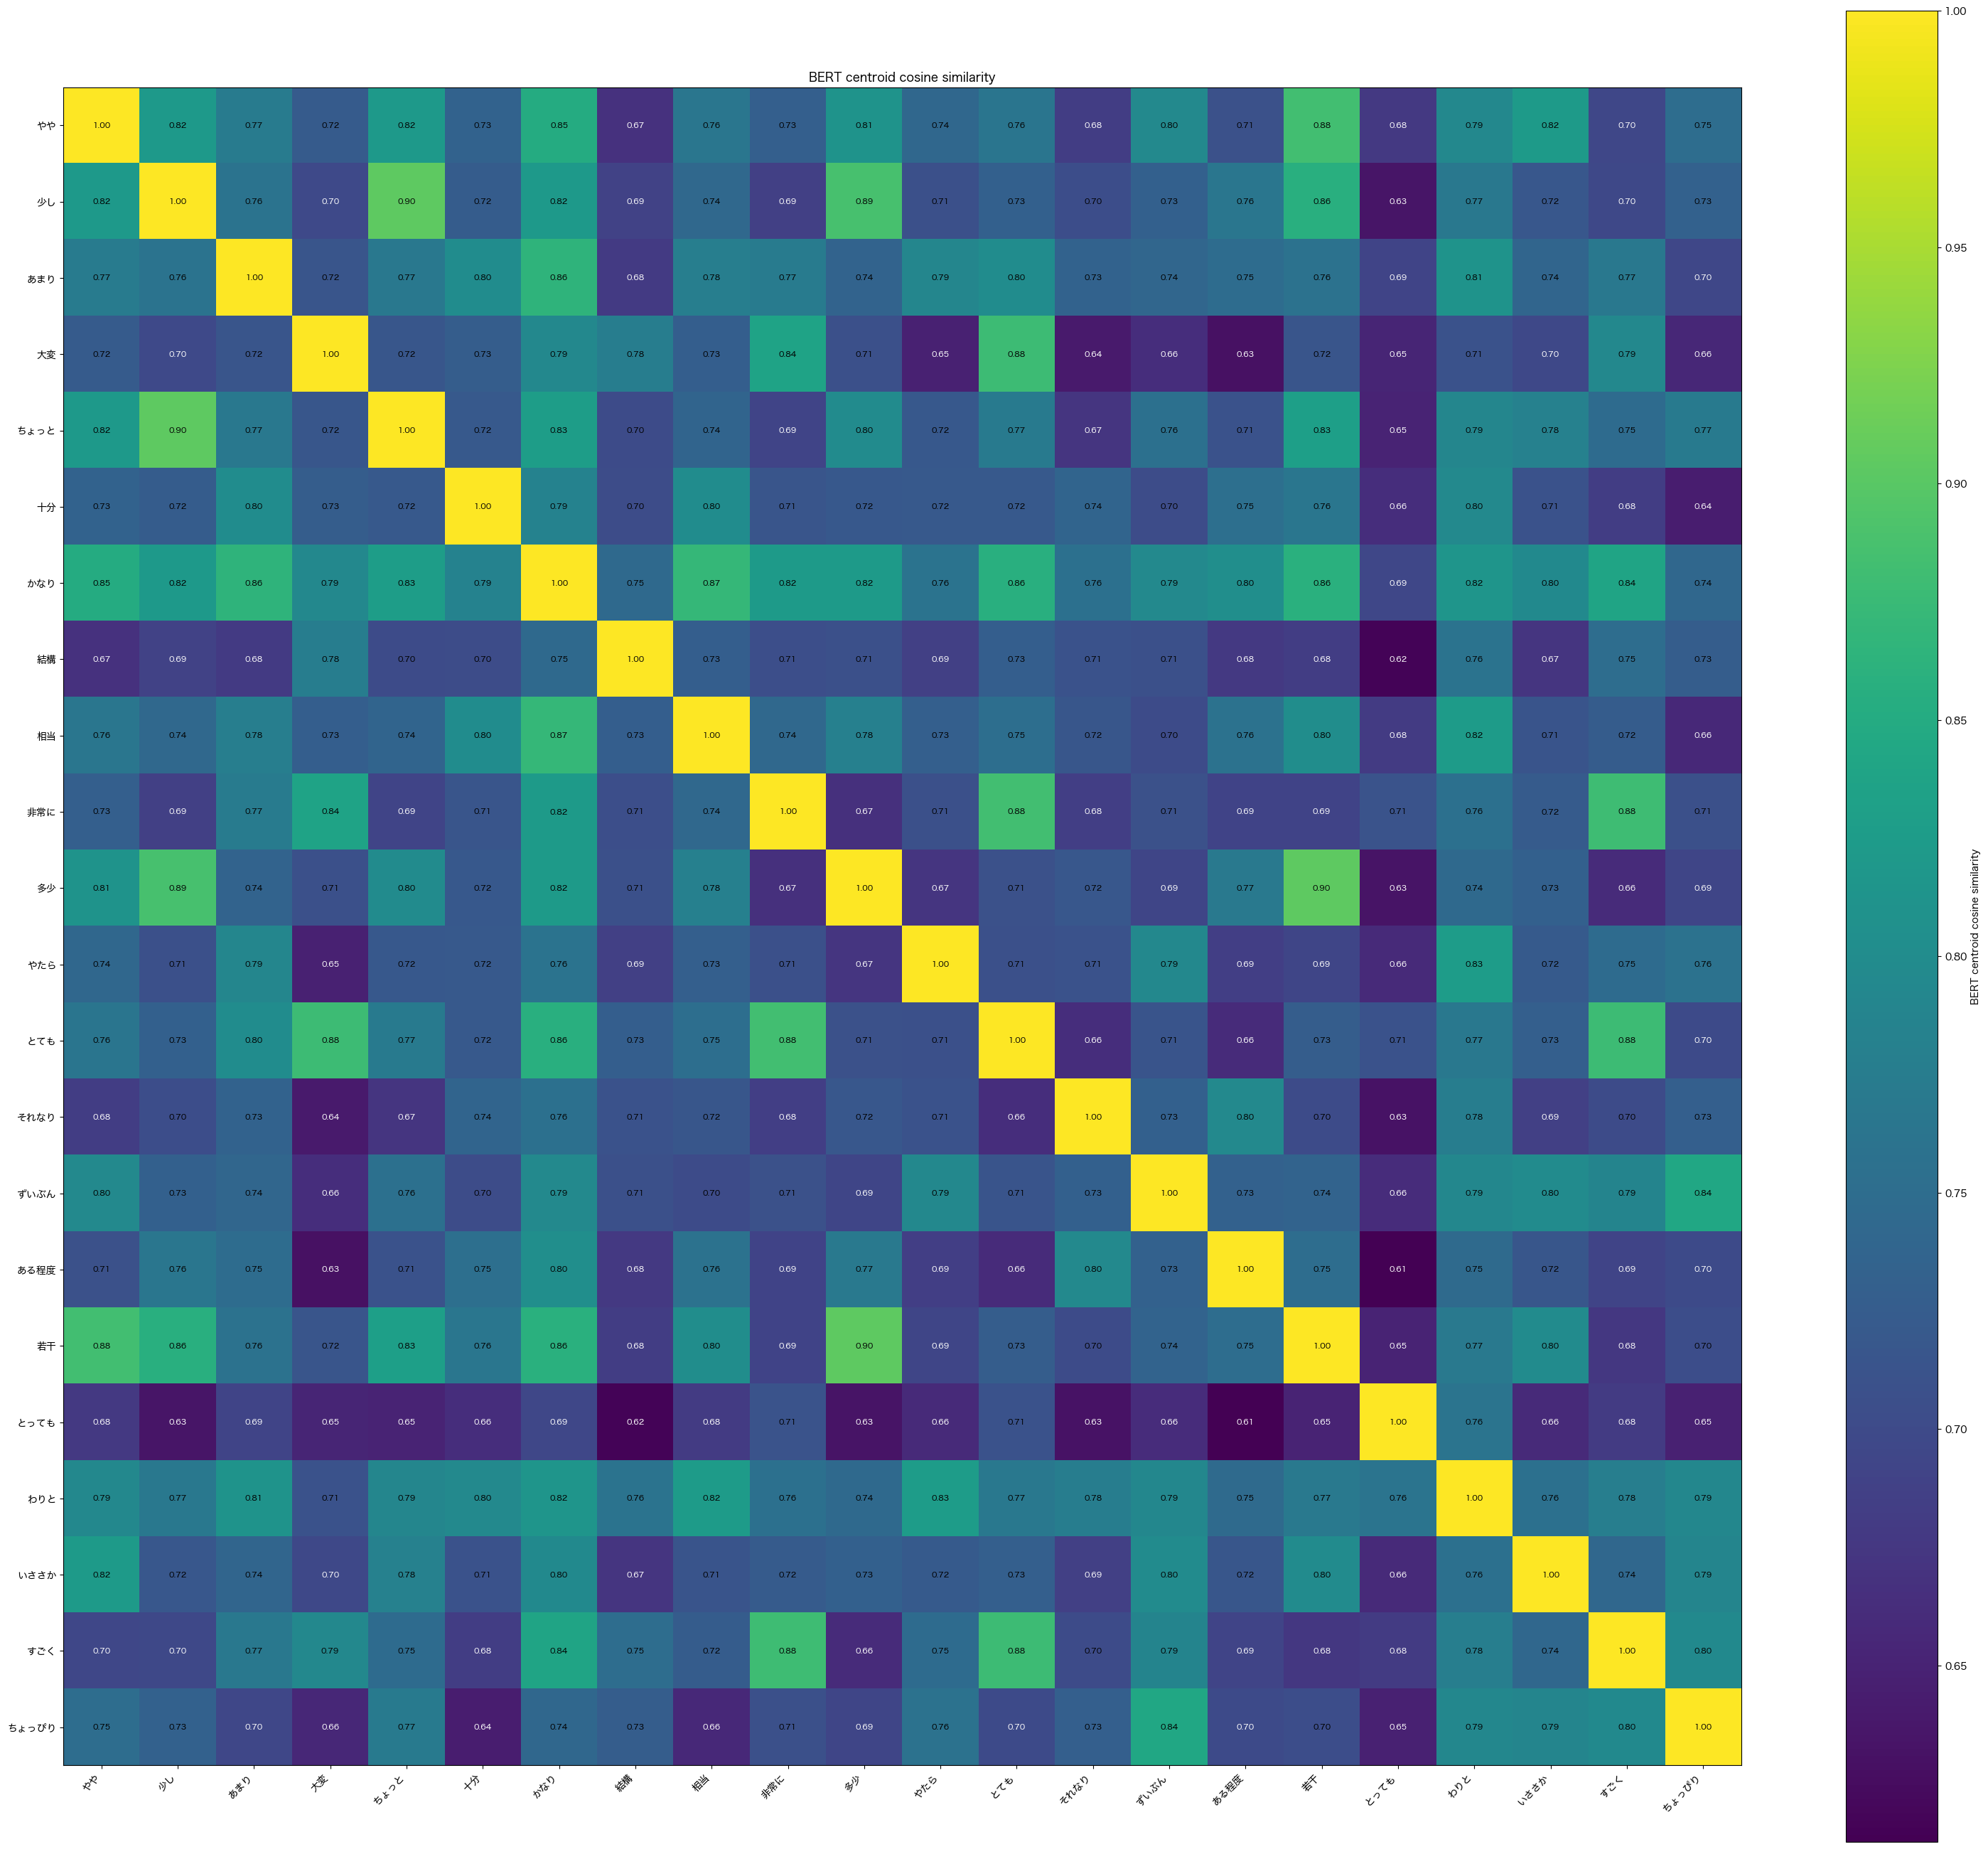

In [19]:
# add rcparams
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['MS Gothic', 'Yu Gothic', 'Hiragino Sans', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False  # Fix minus sign display
plot_matrix(bert_sim_matrix, "BERT centroid cosine similarity")


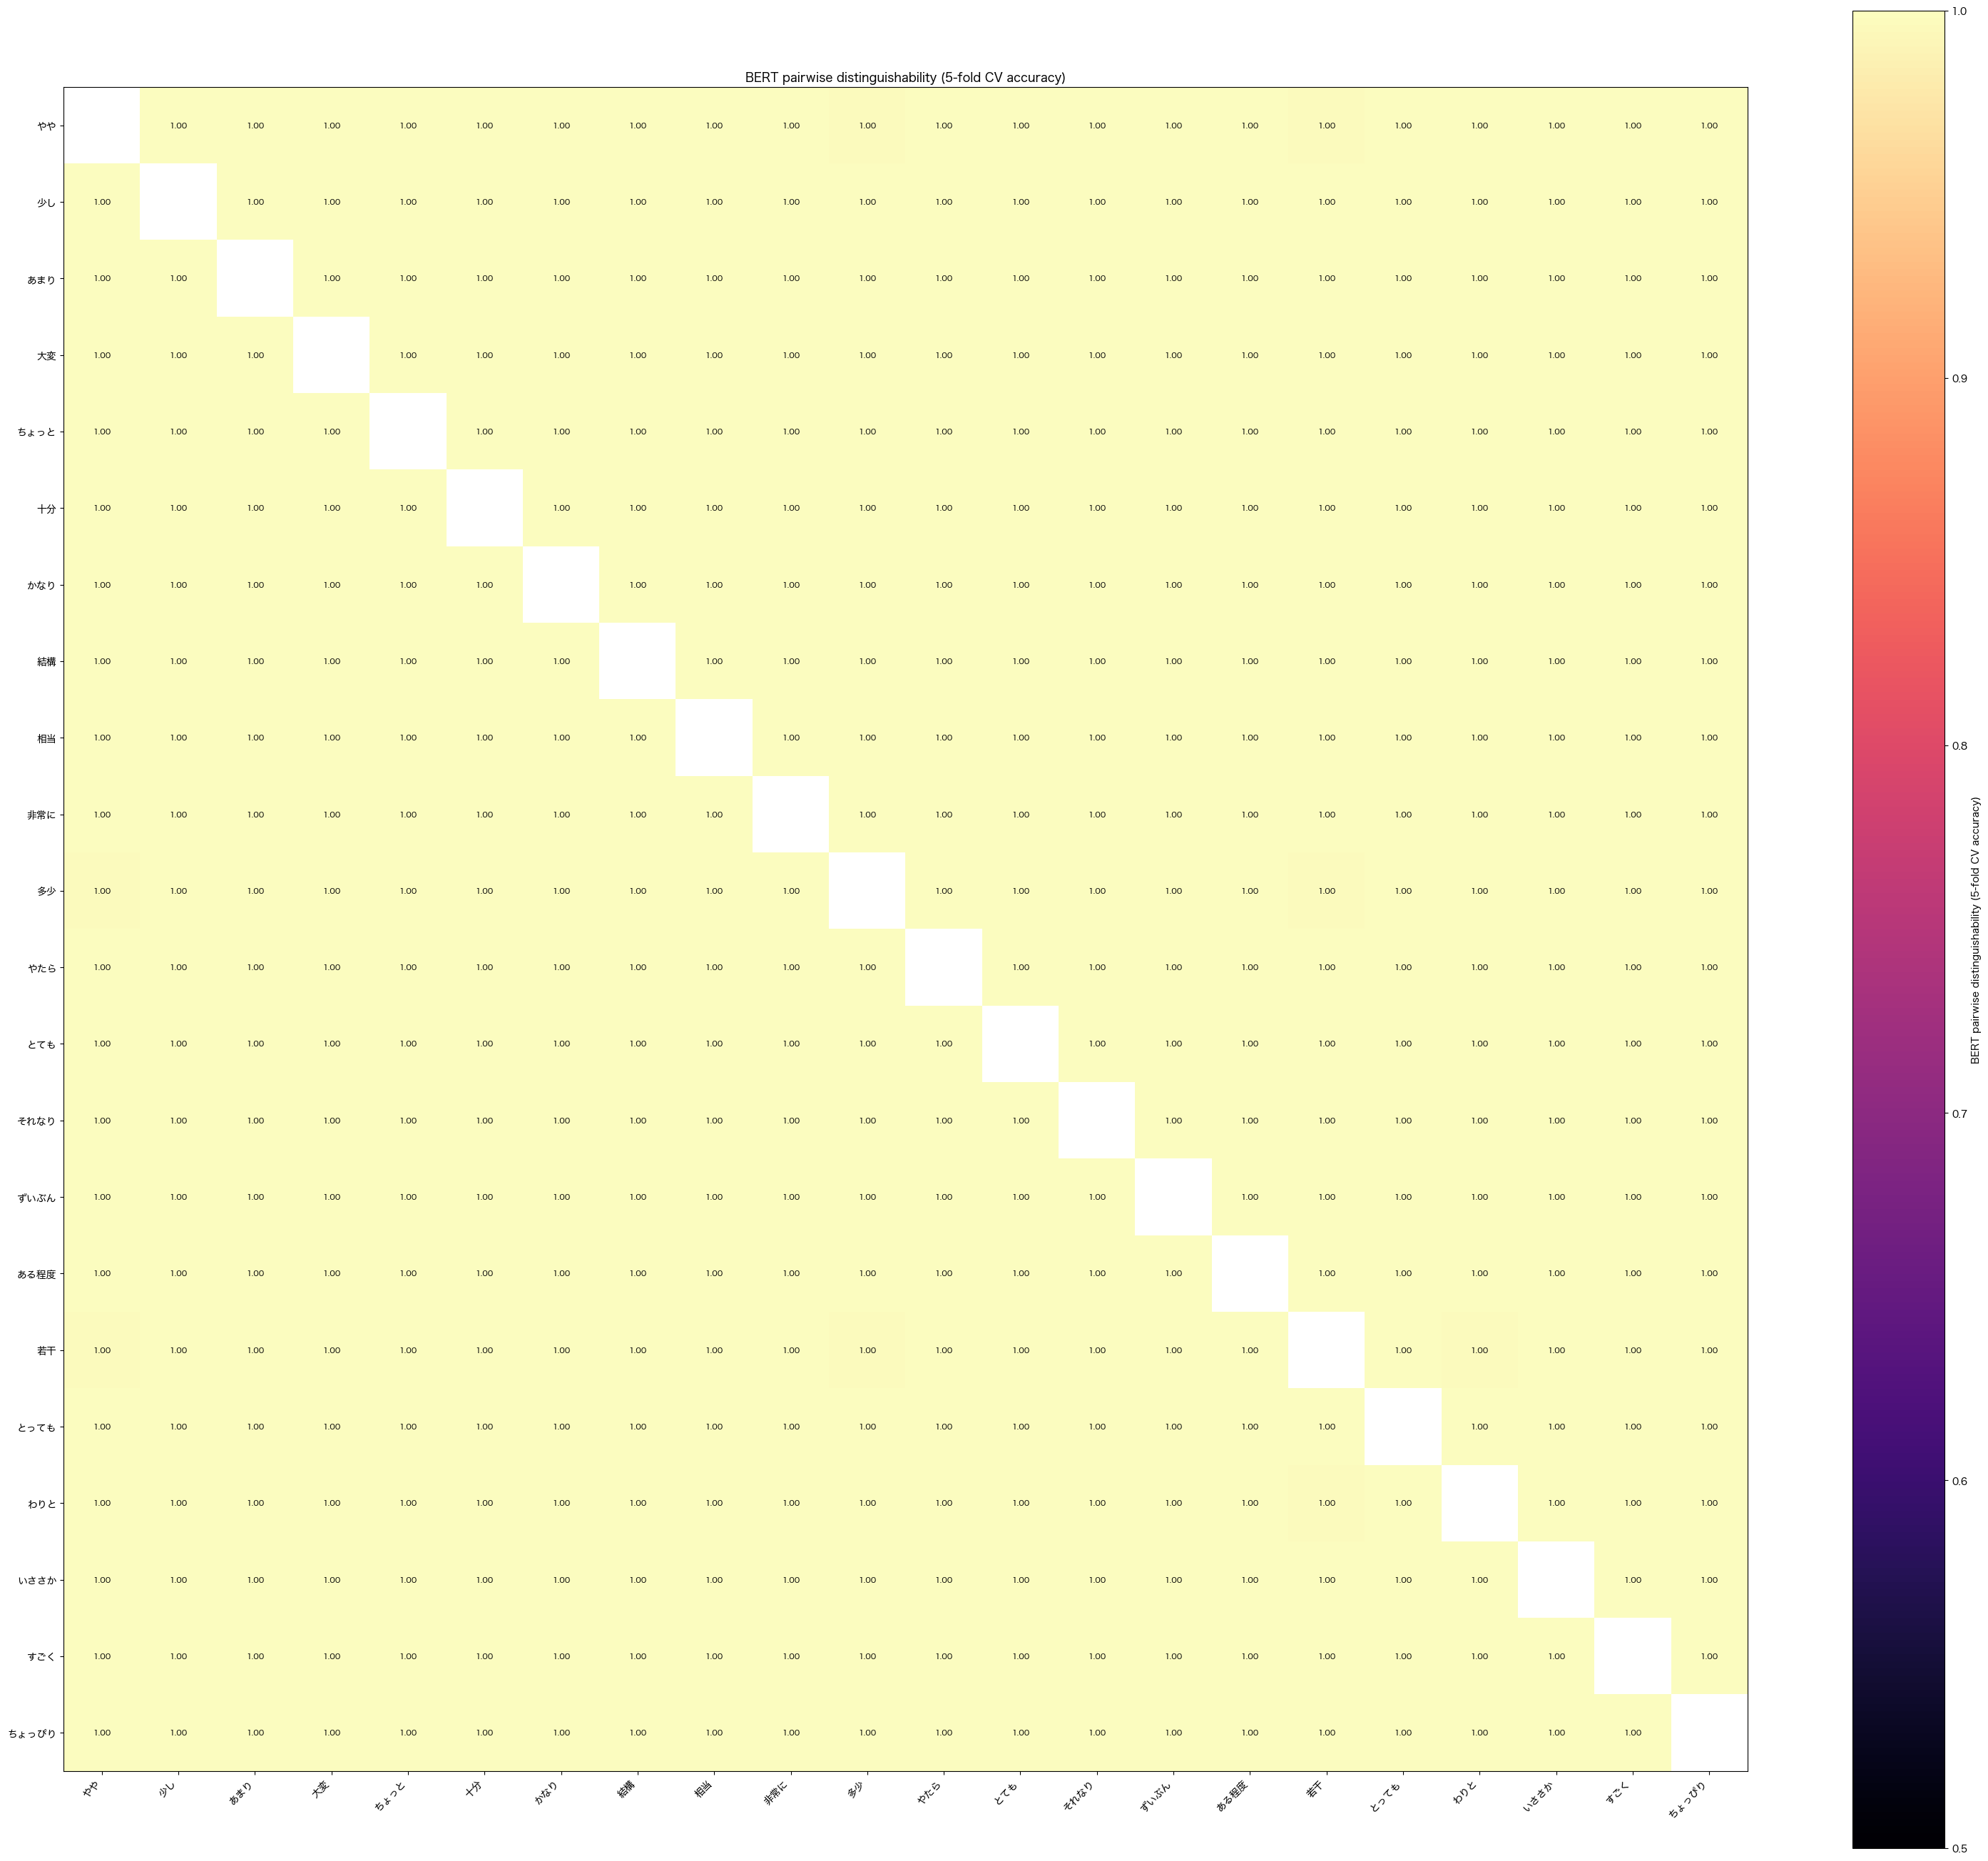

In [20]:
bert_accuracy_matrix = pairwise_classifier_accuracy_matrix(bert_vectors_by_word)
plot_matrix(bert_accuracy_matrix, "BERT pairwise distinguishability (5-fold CV accuracy)", vmin=0.5, vmax=1.0, cmap="magma")


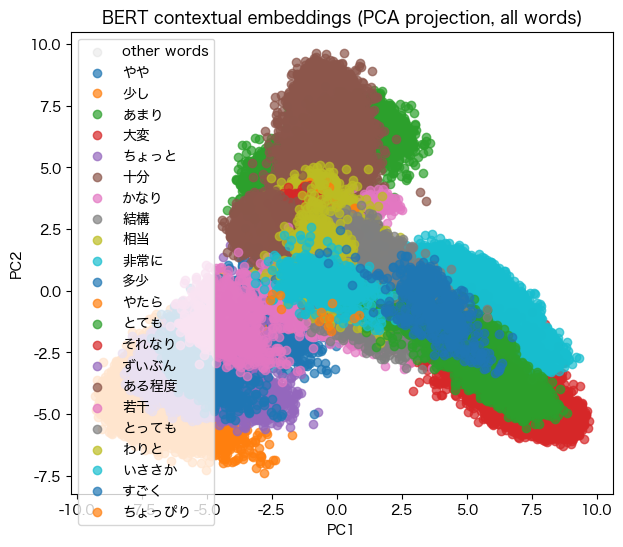

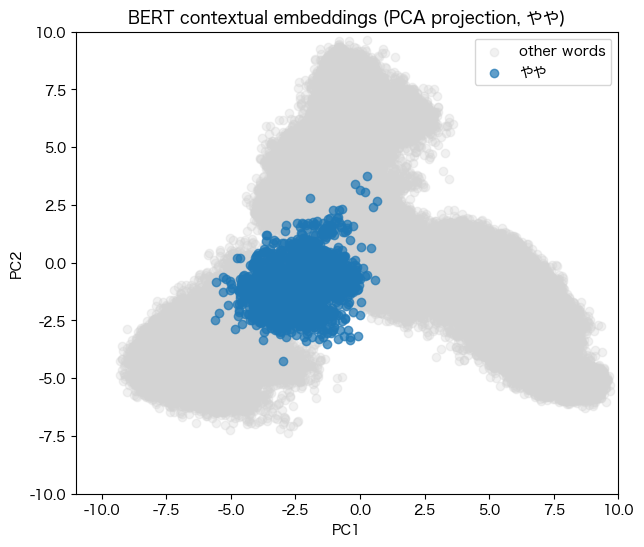

--- やや: PC1 low ---
  (-5.60) ギガスマキナに関しては機体の説明にやや変更を加える形で記載しようと思いますので、更新時、文面に「これは瑣末な文だな」と思うような文がある場合はよろしくお願いします。
  (-5.60) :[[公認心理師]]の件で検討したのですが、私からの提案は、"公認心理師記事として立項"しているので、"本文はその主張をベースとするが、やや昔のものであってもその主張に通ずる文言、本質を捉えるのに有効な文言、類似する文言があった場合には[[脚注]]にURLを追加し、もし本文に追加したい時は現状の主張としてそれらの文言を編集前にカスタマイズをして、脚注ともに追加すること。
  (-5.46) ル・クレジオの記事の方にはやや出典を追加されたようですが（それでもまだ私論的な部分がありましたので、調整を施しておきました）、芳川泰久の記事の方には記述の出典がありませんので、出典があるならば是非追加をお願いいたします。
--- やや: PC1 high ---
  (+0.67) ::{{Fullurl diff|内本喜夫|50294630|内本喜夫}}で「''明らかな素人知識の間違いを訂正''」と称して{{[[Template:特筆性|特筆性]]}}を剥がしたり、{{Fullurl diff|内本喜夫|50297100|内本喜夫}}で「''16年以上もブランクのある人物がはたして現役の第一線のプロ現代音楽作曲家に復帰は可能なのかと疑問視する楽壇の有識者の冷ややかな目は当然多くあった。しかし有識者の予想に反して現時点では予想以上の実績（新作品の高評価など）を残してはいる、しかし最終的に楽壇に完全に定着出来るのかは現時点では予測不可能''」と書いたりすることは、「''ウェブサイトのアドレスを最新のものに訂正する、といった類の変更''」とは言いがたいです。
  (+0.60) :懐疑論関係ほかに現れたいくつかのアカウントがブロックされてますが、このIPさんも {{User2|Tokuninasi}} さんだったのでしょうか…　ややこしいですね。
  (+0.49) ただ、あんまり告知ばかりしていても周囲の方々から冷ややかな目で見られてしまいそうですしまだお勧め記事のほうには提出したばかりなのでこちらでも成果が得られなければ・・・という形で気

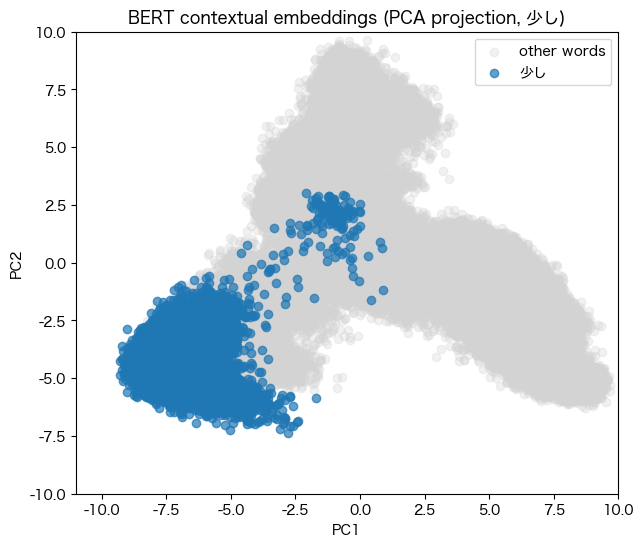

--- 少し: PC1 low ---
  (-9.29) そして改めてお願いしたいのは、こちらの節のタイトルにもありますように、少し調べたらわかりそうな内容もあるのですから、そのあたりはちゃんと「取捨選択」をしていただきたいて、「要出典タグ」をつけるなどしていただきたく思います。
  (-9.29) JapaneseAさん、少し私の愚痴を聞いてください。
  (-9.22) 出典を挙げて記事を加筆することは歓迎されることですが、持ち込まれる出典が少し調べればこのような問題がでてくるものばかりなのはいかがなものでしょうか。
--- 少し: PC1 high ---
  (+0.89) 現段階で、好きすぎるあまり、思いを込めすぎてルールからブレてしまいそうになるかもしれない…と少し反省しております。
  (+0.86) ……ゴールデンウィーク明けまで当方が少々忙しいもので少し遅れますが、いずれ正式に[[Wikipedia:投稿ブロック依頼/ダルメーター 解除]]を提出させて頂こう、と思っています。
  (+0.76) ただもう一人の管理者様が発言されてましたがほとんどもう一人の管理者様の意見の通りなんですよね…妥協案としては出させていただきましたが、IP様は脅しめいたことまで言ってます…削除側の総意としてどういう風に書くか示せとか、私とIP様が合意してもほかの方が削除したら、納得してない人がまた復活させ編集合戦になると言ってます…はだはだあきれ返ります…少しお願いというか確認をお願いしたいのですがハッスルワンを編集合戦してたIPと上のIP様が同一人物か確認できたらして貰いたいです。
--- 少し: PC2 low ---
  (-7.39) 議長を差し置いて編集してしまい少し申し訳なく思います……任せて下さりありがとうございました。
  (-7.26) Penn Station さんも活発に参加していらっしゃる[[Wikipedia:良質な記事]]という興味深い企画の立ち上げに参画できなかったことが少し心残りではありますが、今後そちらでも何かお役に立てることがあればと考えています。
  (-7.18) お返事の考え中に投稿してしまって少し申し訳ないです。
--- 少し: PC2 high ---
  (+3.00) この変更は、かつての方法で日本全体、世界全体を学ばせ

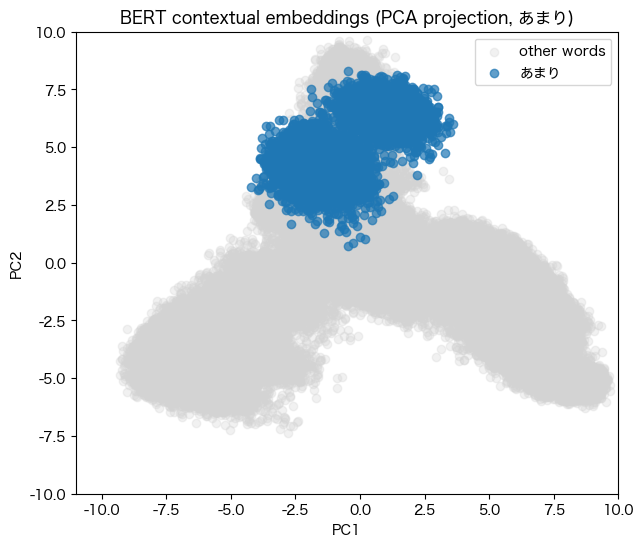

--- あまり: PC1 low ---
  (-4.23) あまり分けなければそもそも意味がわからなくなりその上みずらいと思います。
  (-4.02) 私が、あまり写真を挿入すると、[[エンレイソウ属]]のようにＫｓさんに削られるので、[[白花変種]]のページ構造は、あとはＫｓさんにおまかせします。
  (-3.96) == あまり消すのは止めて。
--- あまり: PC1 high ---
  (+3.59) でも、私の巻き添えをくらって、何の関係も無い別人がブロックされるのは、あまりに気の毒であり、またこのような不正義を為す人たちは許し難いものです。
  (+3.50) [[アニメガタリズ]]にて記事の差し戻しをなされましたが、正しい記述まで消去してしまうのは、あまりに横暴です。
  (+3.44) 途中で私の説明要求を無視したのに、他人の論に迎合して再登場というのはあまりに不誠実です。
--- あまり: PC2 low ---
  (+0.71) 証拠て……あまり喧嘩腰にならないで頂けますか？
  (+0.84) いつも[[Portal:数学]]のメンテナンスお疲れ様です．虎子算さんが翻訳途中の [[:en:Barnes G-function]] の原文に少しだけ手を加えたので一応報告しておきます．読みにくい数式とか間違った数式とかは，気付けば翻訳時に直していくといいと思います．オイラー作用素は投稿されないのかなと思っていましたが，先ほどあのページに気付きまして，なるほどそういうことですか……まああまり臆病になりすぎなくてもいいのではと思います．翻訳とか記事作成とかは少しずつ慣れていけばいいですし，もし間違いがあっても私あるいは他の人が気付けば直すでしょう．ちなみに "As in one variable" は，「一変数のときと同様に」という意味です．それでは．[[利用者:新規作成|新規作成 (利用者名) ]]（[[利用者‐会話:新規作成|会話]]） 2015年10月29日 (木) 13:38 (UTC)
  (+1.03) :[[利用者:Opponent|Opponent]]様へ……「あまりにも一方的な削除」との事ですが、[[新型インフルエンザ]]の[[ノート:新型インフルエンザ|ノート]]にはこのような記述を危惧する意見が以前から示されておりましたよ。

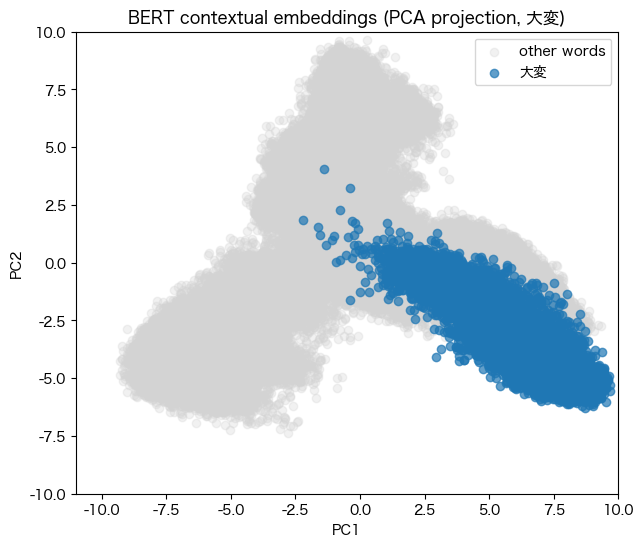

--- 大変: PC1 low ---
  (-2.23) これまでの作成されたアカウントは{{user2|Lwld}}・{{user2|おやつ}}・{{user2|大変}}・{{user2|同上}}・{{user2|同様}}・{{user2|たかも}}など。
  (-1.62) Freetrashboxさんの「…''別人です''…」と言い切っている言葉を大変自信に満ちていると感じましたので、Freetrashboxさんの裁量にお任せいたします。
  (-1.55) *:しかしながら今の脆過ぎる精神状態では最悪心が壊れてしまうかも分かりません……　むしろ精神が崩壊した状態でウィキペディアに関わったら大変なことになる気がします……
--- 大変: PC1 high ---
  (+9.69) この度は当方の思慮を欠いた独善的行為によりご迷惑をおかけしてしまい、大変申し訳ございませんでした。
  (+9.68) さて、[[LTA:ISECHIKA]]案件の件なのですけれども、各記事での歌詞転載荒らし頻発を受けて、2月28日に私が『[[:Wikipedia:削除依頼/LTA:ISECHIKAによる歌詞転載案件 20110228]]』を作っていたんですが、各記事にサブページへのリンクを貼り忘れてしまったため、今回の新規依頼を立てて下さった貴殿を始め、多くの方のお手数をお掛けすることとなってしまいまして大変申し訳ございません。
  (+9.62) この度はご不快の念をおかけし、大変申し訳ございませんでした。
--- 大変: PC2 low ---
  (-6.31) <br />頂いたメッセージについて、当方で「差し戻してください」と書いたにも拘らず、その後細かい編集を重ねたことで差し戻しが難しい状況を作ってしまったこと、大変申し訳ありません。
  (-6.22) ご指摘通り、ひいては管理業務全体への不信感も招き、他の管理者の方々にも御迷惑をお掛けし、大変申し訳ないです。
  (-6.21) 昨日、「アクセスジャーナル」の記事を新規作成しましたが、ウィキペディアは何ではないかの２の論評（評論）の規約に反し、 一部の主題、特に時事問題や政治に関する項目では、興奮して、つい自分の支持する見解を情熱的に推すような内容の記載をしてしまい、記載内容の間に妥当な釣り合いが取れるように配分

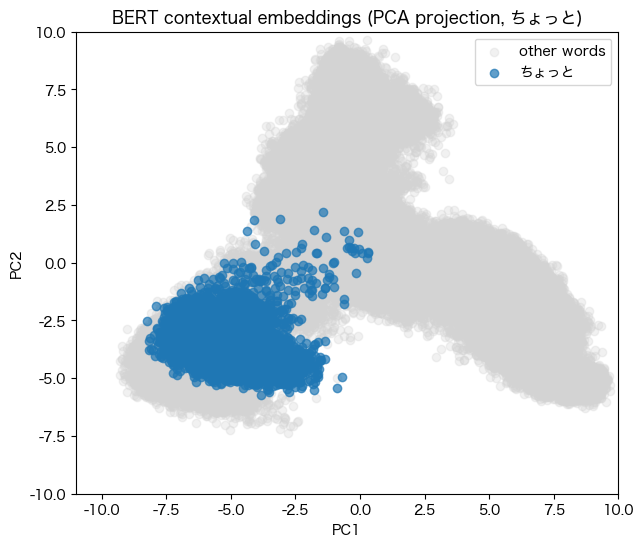

--- ちょっと: PC1 low ---
  (-8.26) ウィキペディアとしては、カテゴリ作りに勤しむくらいなら、ちょっとでも記事を書いてほしいんでしょうねえ。
  (-8.17) 事実としてあってニュースソースもちょっと探せば出てくることについて、要出典とすら書かずいきなり記述を全削除しておきながら「恣意的だ」の何だの言われる筋合いは無い。
  (-8.17) **さえぼーさんなら、ちょっと触れてみれば使い方は分かるかと思います。
--- ちょっと: PC1 high ---
  (+0.32) <br>　「○○空港前」とか「○○ターミナル前」あるいは「○○インターチェンジ周辺」なんて記事が生まれたら…　と考えるとちょっと怖いので、6144さんの捉え方を（率直なトコ）もうちょっとお聞かせ願えるといいなぁと思います。
  (+0.29) 通常は信頼できる二次資料に基づかなければならないウィキペディアの記事において一次資料であるクレジットのみ重要視するのは……と、ちょっといろいろと考えさせられました。
  (+0.28) なお「男性のバーチャルアイドルがほとんど居ない」かどうかに関しては、韓国発のアダムや少々意味合いが違ってくるものの[[ゴリラズ]]の例もあるので、微妙かもしれません…今までのクリエイター側が男性に偏り理想の異性アイドル像として女性キャラクターがメインだった様相を呈しているとはいえ、現在のクリエイター層が男性偏重という訳でもない面や近い将来において未知数というところもありますので…ちょっとそのあたりを含め、今回の対話で思うところを細部調整などしてみます。
--- ちょっと: PC2 low ---
  (-5.71) ちょっと済みませんが、地震の被害で家の中が酷い事になってしまいました。
  (-5.60) きっと社団のように公明正大に振る舞うぞというお気持ちがこもっていると拝察しますが、ちょっと心配です。
  (-5.58) この方針で異が出ましたら、ちょっと残念ですがノートで議論にすれば解決するでしょう。
--- ちょっと: PC2 high ---
  (+2.20) 特徴のコントラバスの記述は最重要事項なので譲歩はちょっと。
  (+1.90) 最初の文面で50ちょっとと書いたのは、5月に出された別表の情報で数の誤りがあるので、
  (+

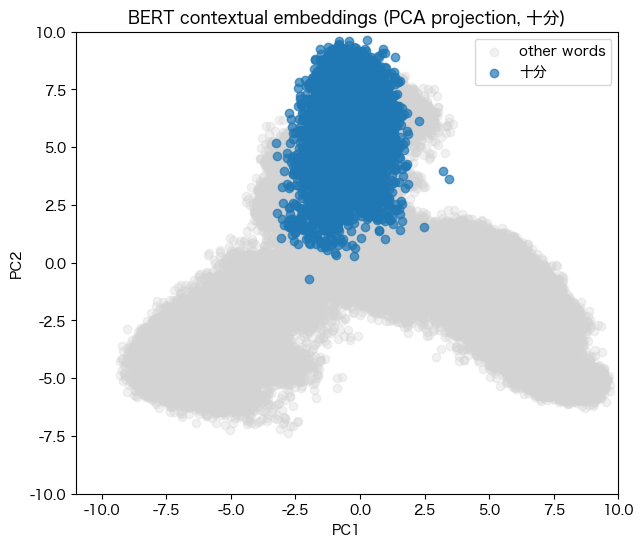

--- 十分: PC1 low ---
  (-3.26) 十分以上のあらゆる側面からの補強証拠がそろったうえでの「相変わらず」や「ハイレベル」という表現。
  (-3.23) 単に、検証することを求められているだけです（検証の手法はルールになっておりません、三十分以上探しても見当たらない場合は「無い」という判断でよいのです）。
  (-3.21) [[Template:出典の明記]]では十分出典があると判断したらはがせるとはありますが、はがす側が出典を出すべきとは記されていません。
--- 十分: PC1 high ---
  (+3.44) について、Nocto様に当方の気持ちを汲んでいただけただけで十分にありがたく思いました。
  (+3.21) 私に報告する義務なんてこれっぽっちもないのに、わざわざご連絡いただいただけでも十分にありがたいです。
  (+2.48) 検証可能性を満たした出典がきちんとあるだけでも、十分ありがたいです。
--- 十分: PC2 low ---
  (-0.70) *同じことを書こうとしてタッチの差で書かれてしまいました…要件はLILOBJTOFU123氏が仰っている通りですので今後十分にお気を付けください。
  (+0.31) 氏の仰る当該編集の際はその点十分留意願います。
  (+0.31) 今後十分注意します。
--- 十分: PC2 high ---
  (+9.65) それが今回も前回もなかったのは、あなたが手を変え品を変え存続に値すると述べた主張や提示された外部記事の出典が、当該記事を存続させるために十分なものと認識されなかったのだということを、ご理解ください。
  (+9.62) 単語の羅列などで定義づけが十分になされていないことを記載すれば記事1対象になるかと思いますので、即時削除タグでの説明を行う際は表現に工夫していただけるでしょうか。
  (+9.59) 基本的には[[Wikipedia:独立記事作成の目安|特筆性]]が十分に示されていない記事は削除され、特筆性が十分に示されている記事は存続とされる、ということです。


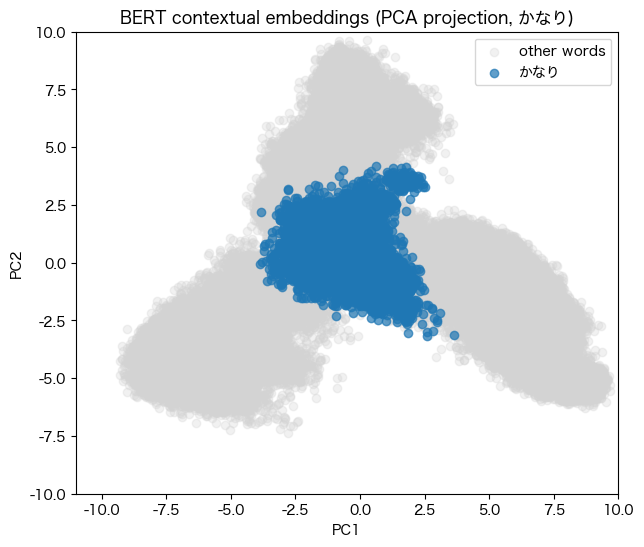

--- かなり: PC1 low ---
  (-3.87) 内容は前回削除時から、問題部分をかなり除去しております。
  (-3.83) comと言った海外ニュース媒体と言った資料を集めて作成の準備は進めて行こうかと思っております（Wordで作成して原稿を整えていく準備は変わらず行き、昔の選手に関してはかなりの資料を探して行けば作れるのではないかと）。
  (-3.78) :それにしても、他の利用者さんが記事本体の約物をかなり修正しても看過なさっているのに、どうして私の編集にだけあんなに反発するのか、そんなにいつまでも長い間、憎しみを保っていられる頭痛さんの真の心は私にもよく見えません。
--- かなり: PC1 high ---
  (+3.65) かなり嬉しいです。
  (+3.08) 私が「無知」と侮辱されたことに対して、森藍亭氏の行為が新規参加者に対する規則を大きく破っていると証明したところ、Calvero氏が森藍亭氏同様、一切の記述を突如、止めるというのはかなり不思議な現象です。
  (+2.99) : '''しかし、もう何年も編集をやっておられるのに、差し戻しの差し戻しをされた点はかなり残念です。
--- かなり: PC2 low ---
  (-3.19) なかなか厳しいことを各依頼で仰っていましたが、他の利用者とは違いSureturn様は決して感情的に意見しているのではないという事が分かってかなり安心致しました。
  (-3.15) かなり嬉しいです。
  (-3.04) ただ、かなり失礼ですが、'''コメントの際は必ず署名していただくようお願い致します。
--- かなり: PC2 high ---
  (+4.18) サービスの内容しか書くことが無いのであれば、それは宣伝にしかなりえず、百科事典に不要な項目なのでしょう。
  (+4.12) 特に[[花谷正]]での[[特別:差分/98819477|このような編集]]は[[WP:NOR]]を超えてもはやただの'''感想'''にほかなりません。
  (+4.11) とくに、根拠を示すことなく、ミートパペット扱いすることは、'''個人攻撃'''にほかなりません。


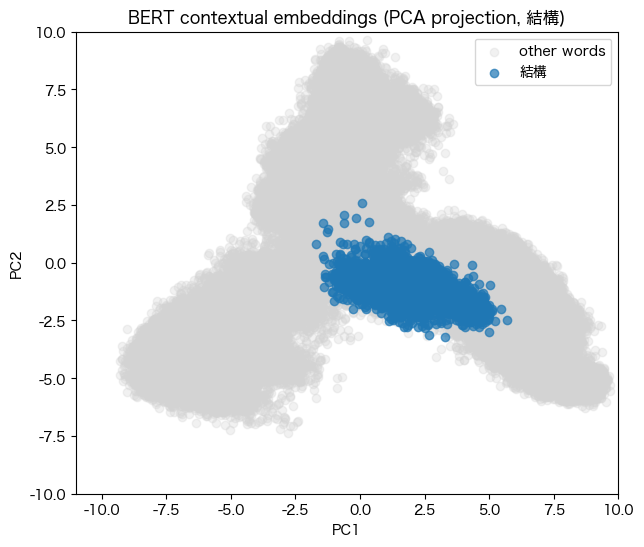

--- 結構: PC1 low ---
  (-1.72) 審議の方は他の2件が削除されているにも関わらず、この項目だけが残っているのも謎ですし、票が集まらない為か、審議が停滞している様ですし… お手すきの時で結構ですのでアドバイス頂ければ幸いです。
  (-1.42) その飛行機の結構は400AC頃の中囯の古い本に記載しました。
  (-1.42) ……こういうの結構苦手ですが、
--- 結構: PC1 high ---
  (+5.68) 元々指摘するつもりの無かったことですし、無視して頂いて結構でございます。
  (+5.46) 私の方で修正しておきますので、この件については無視して頂いて結構でございます。
  (+5.21) 　なお私はアカウントを持っていないIPユーザーであり、チェックユーザーを行われましても何ら支障はありませんので存分に依頼なさって下さって結構ですよ。
--- 結構: PC2 low ---
  (-3.20) また、今までやっていなかった部分なので結構大変ですので協力をお願いします。
  (-3.14) 自分のミスに結構嫌気さしてます。
  (-3.01) 私のコメントも含め、除去して頂いて結構です。
--- 結構: PC2 high ---
  (+2.57) 個人的には今回の[[はやぶさ2]]におけるミネルバ（計3機あるのがまたやっかい……）の活躍を、今後どう記述していくかも結構課題（英語版に限らず日本語版も）だと感じております。
  (+2.07) ::::::どこまでを検証可能とするか、という話になる気もしますが……一応この本古書として売られているんですよね（ぱっとみたところ結構な冊数がセットで50万円は気軽に提案できる額ではないので現実的ではないなと判断しましたが、よく調べたら単品であるかもしれません）。
  (+1.94) 「原型機には付ける、派生機には付けない」と発案したのはあなたなのだから、例え通常ページの編集に関わるつもりがなくても、あなたにはこれに関する質問に答えてもらわなければならず、返信は結構かどうかの問題ではありません。


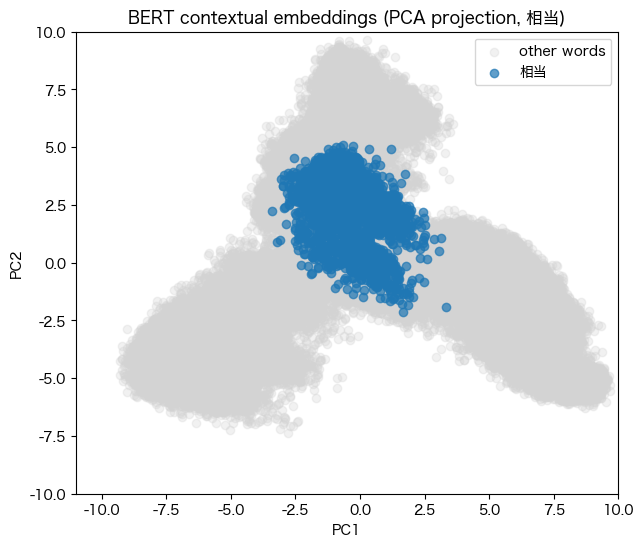

--- 相当: PC1 low ---
  (-3.41) 厳密に定義し、相当集め分類すると本質に近づけていっぱい集めたから世界が理解できている、、知らないことは罪悪に近い、、と善意で考えているらしいと感じられます。
  (-3.21) ）当該利用者名については私も調べてから秘匿化を行いましたが、著作権保護期間外という確証が私も得られなかった一方、某校歌からのそのままの抜き出しであることや、要約には書いておりませんが明らかに特定の利用者を意識した利用者名で、相当調べないと分からないとは思うもののログを遡っていくとその利用者に対するプライバシー侵害にもなりうるようなものであったため、いろいろな「恐れ」が生じる節が払拭できず、念のため秘匿化したと言ったかたちです。
  (-3.09) その後、相当出典も追加いたしましたし。
--- 相当: PC1 high ---
  (+3.31) :[https://ja.wikipedia.org/w/index.php?title=%E3%83%88%E3%83%A8%E3%82%BF%E3%83%BB%E3%82%B3%E3%83%BC%E3%82%B9%E3%82%BF%E3%83%BC&oldid=74531987 この様に]、日本語版で香港仕様の画像で埋め尽くされると相当迷惑です。
  (+3.12) ことに、書類上の１表記だけを抜き出してきて、それが「一次資料に書いてある事だから正しい」などと主張して改名を行なうのは相当に拙速です。
  (+3.05) しかしそれが故、執筆作業自体は他のサーバー等での継続を模索しているくらいなのですから、またムラムラと、と言う気持ちも湧いて来かねませんから、こういう戒めが必要だったのです(私にとっては引退撤回は相当に恥ずかしいことなのです)。
--- 相当: PC2 low ---
  (-2.12) 今は精神面でも肉体面でも相当お疲れでしょうし。
  (-1.92) :[https://ja.wikipedia.org/w/index.php?title=%E3%83%88%E3%83%A8%E3%82%BF%E3%83%BB%E3%82%B3%E3%83%BC%E3%82%B9%E3%82%BF%E3%83%BC&oldid=74531987 この様に]、日本語版で香港仕様の画像で

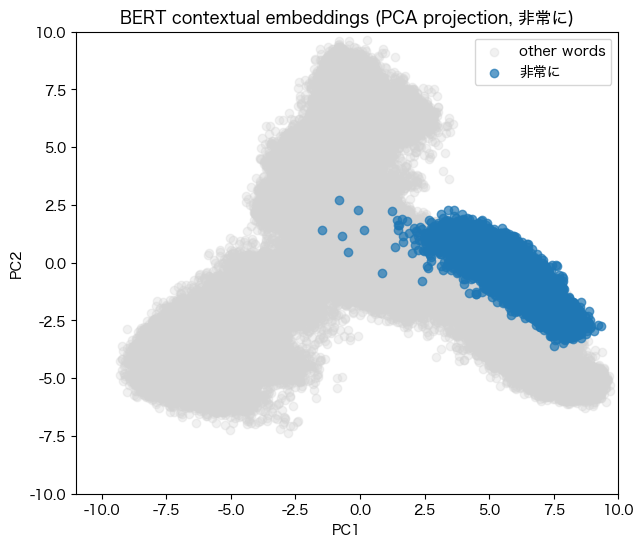

--- 非常に: PC1 low ---
  (-1.46) まあ、このくらいだったらどっちでもよいでしょう、と期待してみたりする……（「イェ」とか「イィ」と書いてしまったページを全部直すのは非常に手間なので……）。
  (-0.80) 何と言えばいいのか……「AはBである」というだけのサブスタブ記事を多数作成されているのですが、このような1行にも満たない非常に短い記事の作成は即刻中止願います。
  (-0.71) [[Wikipedia:善意にとる|善意に理解して]]、何らかのミスなのかな……という推測をしていたのですが、あのような発言では非常に失望させられます。
--- 非常に: PC1 high ---
  (+9.32) :::: この度は第三者の身でありながら、ご都合の悪いタイミングで長々とお時間を頂戴してしまい、非常に申し訳ございませんでした。
  (+9.22) Wikipediaにおいて新規記事を作るのが初めてであったため下書きとして利用していましたが、このような不手際を起こしてしまったのは大変申し訳なく思うとともに、Wikipediaの仕様に関して十分な知識がない当方に分かりやすくご指摘いただけたのは非常にありがたく存じます。
  (+9.04) 4さんが同内容に関する[[WP:SOURCES|Wikipediaにおいて出典として用いることが可能な資料]]をお持ちでしたら、お教えいただけたら非常にありがたく存じます。
--- 非常に: PC2 low ---
  (-3.59) 昔は仲良くやっていたのにこんな事になってしまい非常に残念です。
  (-3.46) 以前の御忠告通りになってしまい非常に残念です。
  (-3.36) 新しい情報が入って非常にうれしいです。
--- 非常に: PC2 high ---
  (+2.72) 何と言えばいいのか……「AはBである」というだけのサブスタブ記事を多数作成されているのですが、このような1行にも満たない非常に短い記事の作成は即刻中止願います。
  (+2.30) :*まず、合意を形成する場合は関連するすべてのページで告知が必要です（関連するページが非常に多い場合は[[Wikipedia:お知らせ]]や[[Wikipedia:コメント依頼]]が利用できます）。
  (+2.28) R|○○|△△|……は、

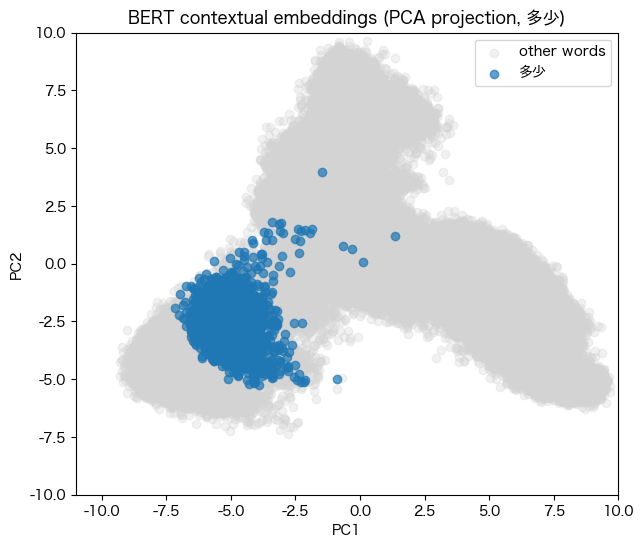

--- 多少: PC1 low ---
  (-7.16) プレビュー機能を使って、多少まとめてからの投稿を心がけて下さい。
  (-7.02) 今回は初版から多少語尾が追加されていても著作権侵害が認められることから、{{T|即時削除}}の[[WP:CSD#G9|全般9]]での対応ができると考えられますので、それで対応しました。
  (-6.97) 作品を読んだ→記事を作成しよう→作品内容を多少書いて立項→他人に丸投げの姿勢は歓迎されません（最近[[Wikipedia:井戸端#「アニメ化してないなろう系ラノベ」の独立記事は作成可能か]]で似たような話をしました）。
--- 多少: PC1 high ---
  (+1.37) また、8年前とまったく同じことを申し上げるのも恐縮ですが…、「編集内容の要約」の記載なく広範囲にわたって修正されているため、多少困惑しております。
  (+0.13) やはり懸念していたように「長期化」してしまうのでしょうか…と考えると多少気重です。
  (-0.30) :じゃあ、私もどうかといえば…多少、感情的にはなってる部分がないといえば嘘ではないでしょうね（笑）。
--- 多少: PC2 low ---
  (-5.26) :この度は当方も多少感情的になり申し訳ありません。
  (-5.20) 多少耳に痛いことかも知れませんが、良くお考え下さい。
  (-5.18) 多少嬉しかったけど、かなり恥ずかしかった。
--- 多少: PC2 high ---
  (+3.97) <br />うーん、注意書きを冒頭にて強調するのは、諸刃の剣ですよね…（抑止効果が多少なりとも期待できそうだから、やむを得ないときはあるでしょう…、と自分は思っていますが。
  (+1.80) さまざまな見方があるのでしょうが、当該人物の場合、実績の多少とは別に、著述家としての一環したスタンスに欠ける面があるように思われます。
  (+1.77) Namioniさんの編集履歴の差分を拝見したところ、加減される文章量の多少にかかわらず、ほとんどの投稿に細部の編集を示すMマークが付いていました。


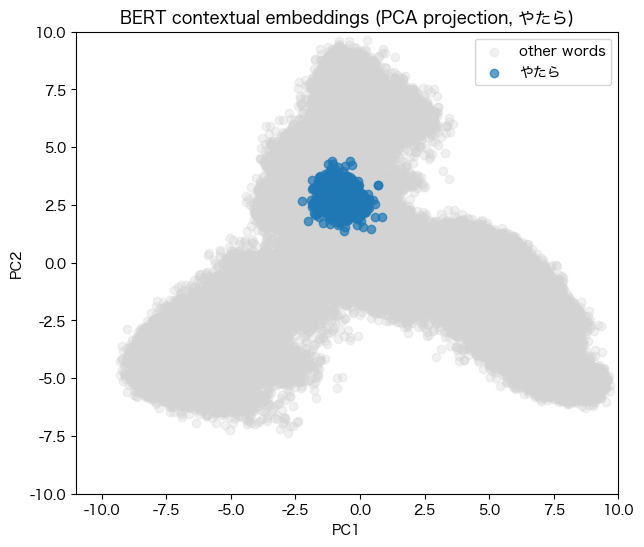

--- やたら: PC1 low ---
  (-2.23) ::また、確かにむやみやたらと月日にリンクを貼るのは私も賛成しないですが、[[Wikipedia:記事どうしをつなぐ#リンクすべきもの]]では「生年月日・没年月日」はリンクすべき、とされているので、少なくとも生没年月日の旧暦リンクぐらいは貼っておいた方が良いのではないかと思います。
  (-2.01) #むやみやたらの情報収集？
  (-1.91) しかしむやみやたらと要出典を貼るだけでは内容に発展がありません。
--- やたら: PC1 high ---
  (+0.85) というか、IPが本文に加筆した文章の日本語表現がやたら幼稚で、見ていて情けない気もしましたが……。
  (+0.71) 数がやたらと多くて申し訳ありませんでした。
  (+0.68) 存命人物の記事で、病歴がやたらに詳しく、本人の履歴の過半を超えて追加されました。
--- やたら: PC2 low ---
  (+1.37) それとやたら競馬を持ち出してますが競輪なので関係ありません。
  (+1.48) なんか、このIPにした途端やたら監視されてるなぁ（笑） 前のIPでも大して行動は変わらなかったのに（笑）
  (+1.57) また文中、やたら伝聞調の文体に差し替えられておられますが、全く持って意味不明です。
--- やたら: PC2 high ---
  (+4.42) Wikipediaは「書いた者勝ち」ではありませんので、Wikipediaの方針に反する不適切な記述をむやみやたらに書かれると削除されることがあります。
  (+4.42) ウィキペディアは「Xについて僕が知っていること」や、ある事象についての自分の中での定義をむやみやたらに書く場ではありません。
  (+4.28) 「カーブ」や「バラエティ」などでむやみやたらに「ヴ」や「ヴァ」に置き換えないでください。


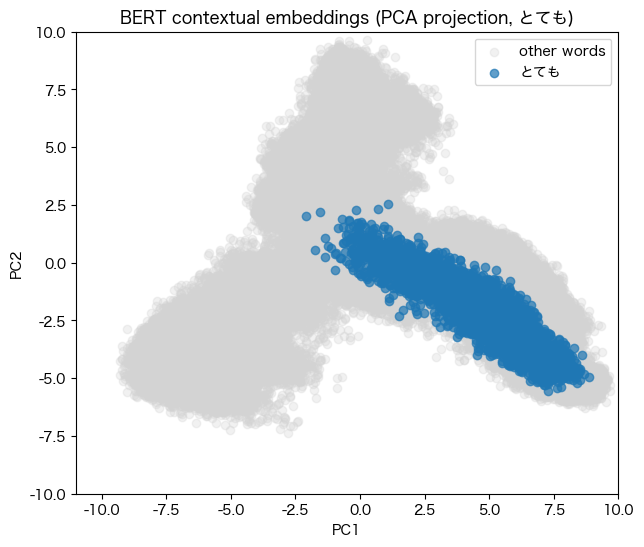

--- とても: PC1 low ---
  (-2.10) * 隣の[[利用者:とてもつ|利用者ページ]]は自己紹介や作業用のスペースとして利用することができます。
  (-1.73) 例えば、Kamedamkさんが「交流・評など」としたセクションの内容は、コラボしたことがあるという内容だとか、刈り上げ友達だとか、SNSにメッセージを残したとか、新しい学校のリーダーズを見た他の著名人のただの印象や感想などとても評などとは言える内容ではなく、『新しい学校のリーダーズ』にの活動に大きく直結しない、些細な内容としか言えない1・2行程度の特筆性も内容もない、百科事典であるWikipediaに記載するには重要な交流の内容だとも言えず、同じく「その他」の内容についても、共同生活をしていた、和食を自炊する事が多い、緊張はしない、反省会の内容など、百科事典の記述として特筆性に欠けており、重要性を全く感じず、必要だとは思えず、「Wikipedia:ウィキペディアは何ではないか/ファンサイト」に該当するファンサイト的な記述内容で「Wikipedia:ウィキペディアは何ではないか#ウィキペディアは情報を無差別に収集する場ではありません」に反していると思います。
  (-1.54) この編集によって記事がとても
--- とても: PC1 high ---
  (+8.85) あと、私の会話ページに記入する場合がある時は、「マークアップが間違っているものも多数手直しして下さり、とてもありがたいです。ただ…」 とか 「[[プロジェクト:テレビドラマ]]に添ってキャストの記載を「演 - ○○○○」という風に修正していただくのはとてもありがたいと思いますが」 などの様な、前置きは要りませんから、本題だけを記入してください。
  (+8.69) 記事によっては大胆というより若干強引な編集を行ってしまったりしたので、活躍とおっしゃっているのを伺うと恐縮してしまうのですが、幅広い記事を執筆されている方がご覧頂いてたのを知ってとても嬉しいです。
  (+8.58) NAGIEさんのご苦労により、仙台市電の記事が拡充していく姿は、そばから見ていてとても嬉しいし、楽しく読ませて頂いてます。
--- とても: PC2 low ---
  (-5.56) また、Benzoylさんに整理して頂き、統一感が出たこと

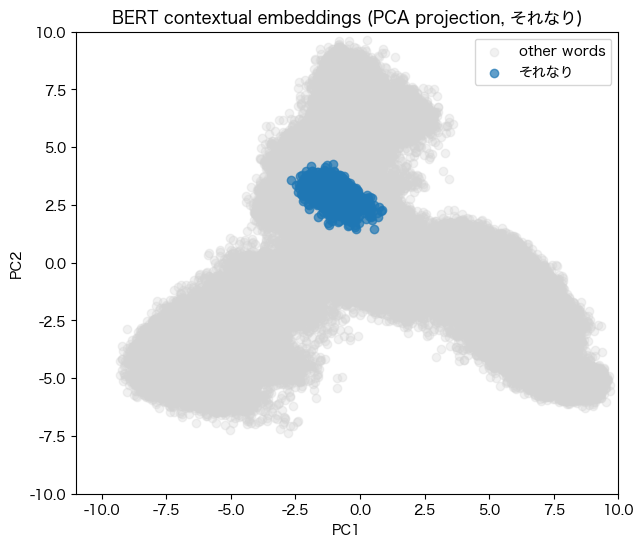

--- それなり: PC1 low ---
  (-2.67) ウィキペディアでは特筆性といって書くべき内容にある程度制限があり、一般的なメディアやそれなりのレベルの論文などで言及されるレベルの政治活動家や政治団体については記述可能ですが、単なる地方議員や右翼団体レベルでは記事作成しないことになっております。
  (-2.48) まあ100は現実的に無理でも、それなりの大多数が参加するほうが望ましい。
  (-2.39) 磐田は3作目でそれなりの役わりを持つ人物。
--- それなり: PC1 high ---
  (+0.85) 単に要出典を加えたりするのではなく、自分で出典を探して、書き加えることもできるということを忘れず、また、出典を確認して加えることは、それなりに面倒なものですし、検証可能性の方針はまだまだ日本語版で定着していませんから、出典を求める場合には、なぜ必要なのかの説明や、出典の書き方の説明なども含めて、執筆者が納得・理解して出典を加えるように、丁寧な対処をお願いしたいところ、ではあります。
  (+0.80) サーバーを用意し運用することはそれなりに大変なことですがFaubyさんの提案が他者にとっても十分に魅力的なものであればそうした問題の解決を進んで買って出る人も現れるでしょう。
  (+0.72) 正直言いまして上記のお答えを見る限りでは、進言いたしましたことはそれなりに適切であろうと考えております。
--- それなり: PC2 low ---
  (+1.46) :: それなりにお気に召して頂けた様で、ほっとしてございます^^;。
  (+1.46) それなりに斟酌させてもらっています。
  (+1.53) :また、私もそれなりに今回の責任を取りたいと思います。
--- それなり: PC2 high ---
  (+4.28) その観点からすれば、当該月に新規立項・加筆され、なおかつ、コミュニティの人気をそれなりに集めた記事に対し、やたらに厳しい基準を持ち出して却下することは、[[利用者:Falcated|Falcated]]さん御自身もおもしろくないかもしれませんが、記事を書いた人、投票した人、それぞれにおもしろくないことではありますので、やはり厳に慎んでいただきたいと思います。
  (+4.23) wikipediaにおける初心者の範疇が

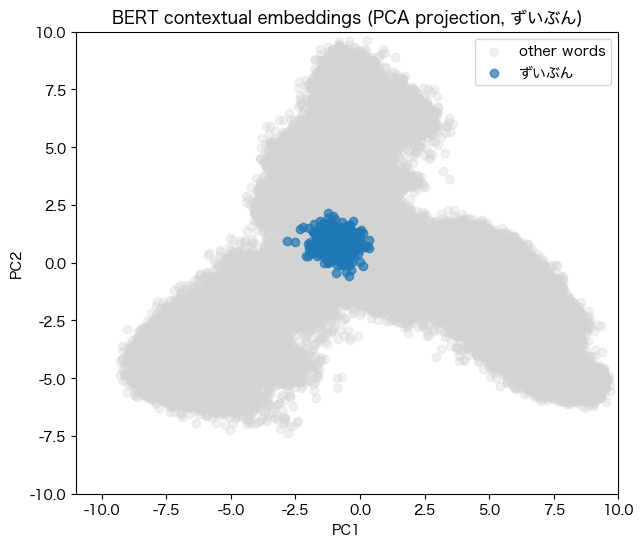

--- ずいぶん: PC1 low ---
  (-2.83) 第一ずいぶん前の終わった内容残してどうするの？
  (-2.52) ずいぶん前の依頼でまず何か提案するときは理由を書いてほしい。
  (-2.32) たとえば、メールでは「企画のたまご屋さん」のチラシなどの一次情報にずいぶんお詳しいかのような書きぶりでしたが、もし関係者やそれに近い方なのだとすれば、あなたは'''[[Wikipedia:自分自身の記事をつくらない]]に違反する可能性が高いです'''（違反しないように振る舞える方もいますが、あなたの場合、すでに問題のある行動を重ねすぎています）。
--- ずいぶん: PC1 high ---
  (+0.34) :それにしても資料を発見されるには、ずいぶんなご苦労ではありませんでしたか？
  (+0.33) ですから、発売日を過ぎたので「もう出典は必要ない」という判断で、「発売済みのため出典不要と考えるので除去」とか書いてあれば至極もっともな意見だと思いますが、編集した当事者としては、前出の要約欄の記述はそこを理解していないずいぶんと失礼に感じるのです。
  (+0.28) さて、Kabityuさんが議論に参加されている[[ノート:May (歌手)]]を偶然拝見し、過去の有用な記述を生かさないというずいぶんもったいないことが行われているな、と感じ、変則的ですが統合提案を提出いたしました。
--- ずいぶん: PC2 low ---
  (-0.56) ずいぶんご無沙汰しています。
  (-0.44) （ずいぶん性格の違うソフトですが）[[特別:ContentTranslation]]の翻訳先は自由に指定できるようなので、[[:en:Cloth hall]]の翻訳先として[[user:ツバル/sandbox1]]を指定して動かしてみました。
  (-0.38) ずいぶん遅れてのごあいさつになりますが、アカウントを作成してくださってありがとうございます。
--- ずいぶん: PC2 high ---
  (+2.15) 「Sureturn氏の発言（2011年1月5日 (水) 02:45 (UTC)）以降の井戸端でのakane700さんの発言に言葉の選択を除いて謝罪すべき「非」があるでしょうか。……それと、自分で話を余計こじらせてしまっているという自覚はあります

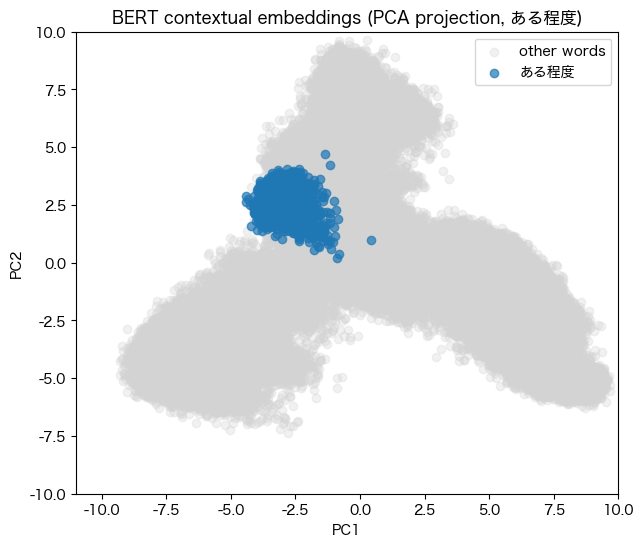

--- ある程度: PC1 low ---
  (-4.42) その後、八重歯にある程度の記述を転記するのもありでしょう（それほど必要とは思えませんでしたのでリダイレクト処理のみでしたが…）
  (-4.41) 参照方法のテンプレートを貼るだけでなく、ある程度文ごとの出典の追加を行って下さい。
  (-4.35) 「Wikipedia:ウィキプロジェクト 日本の地名」があまりに投げやりな状態であったことから、当時はある程度地名記事に成熟された方が立ち上げないと二ノ舞になるという風に感じておりました。
--- ある程度: PC1 high ---
  (+0.42) このうち{{tl|Keypress}}の{{tl|box-shadow}}利用は2012年10月24日以降であり、{{tl|box-shadow}}利用の実績があったのは、その他の244件ですが、この、その他244件は、スポーツクラブ（大部分がサッカークラブ）記事において、表に当該クラブのクラブカラーにちなんだ影を付けるために使われており（例：[[ACアルマレッザ飯能]]）、「表のヘッダ行にもクラブカラーが使われていたり」、「そもそもテンプレート内に、クラブカラーの表記があったり」という感じで、クラブカラーの情報が重ねて示されているだけであり、（見栄えはいいですが）もとより情報としては重複している物であり、これを「''これらが受け入れられている様子を見ると…ある程度仕方がないことだと受け入れられている''」と言える状態では無いと思います（IE8を使って影が付かない状態を見ても、「表」であることが見て取れなくなる訳ではなく、また、クラブカラーを知るのには困らないわけですから）。
  (-0.81) なおライターの方の[http://www.new-akiba.com/archives/2011/09/4_607.html 個人ブログでの言及]（これ自体は出典には使えないと考えます）を見るかぎり、同作品はシュールギャグを題材にしたものであるようなので、作品内容に踏み込んだ記述がが多少意味不明になってしまうのはある程度仕方ないようです。
  (-0.85) 情報収支という面で、各個人は対応の配分を極めて大切にすべきと考えており、相手のご理解が得られる限りにおいて、スルーする、スルーして頂くという対応は特に管理系

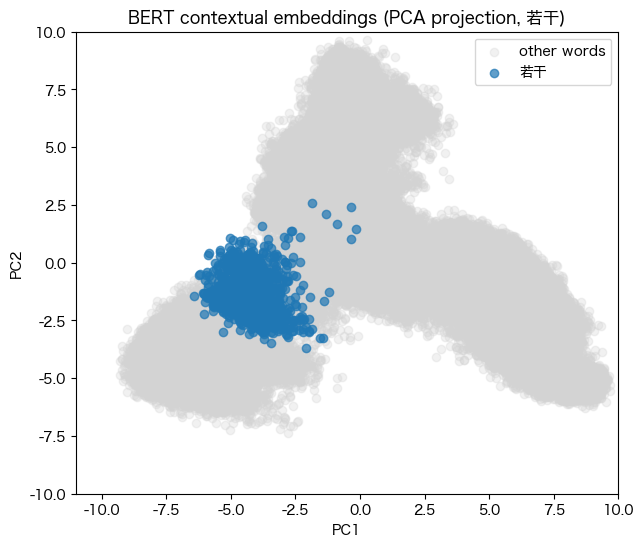

--- 若干: PC1 low ---
  (-6.41) 語尾を若干変えれば良いというものではありません。
  (-6.24) さて少し後回しに致しましたが当時の無政府主義や社会主義に関する注釈として[[階級闘争]]や[[プロレタリア独裁]]にみられるような暴力的な行為への指向をしばしば持ち合わせていたことへと若干の説明を増やすことに問題はないでしょうし説明もまとまるでしょうね。
  (-6.18) ''ワールドメイト会員向けの映像を若干配信したとしても''という発言をされており、「配信した」可能性については認めているわけでね。
--- 若干: PC1 high ---
  (-0.18) :また「支持者を通して書かせれば…」の部分も含め、Wikipediaに対して若干の誤解があるように思います。
  (-0.33) （また、お手数ですが画像説明の文体（１枚目は『…群生（日高市の巾着田）』となっているので、同様の文体にするか、双方とも「…にて」などに統一）についても、若干のご配慮をお願いします。
  (-0.35) :そういった事情もあり、ぱたごんさんもきっとそうなのだと思ったのですが……確かに若干の疑問もあったのも事実です。
--- 若干: PC2 low ---
  (-3.70) :: 若干不本意ですが、そう思われるならそれでも結構です。
  (-3.46) 私も若干困ってるのですよ。
  (-3.28) ところで、上でLoniceraさん、海獺さん、はるひさん等に幾度かご指摘頂いているように、幾らUNCで管理業務等に慣れているとはいえ、WPはWPで若干勝手が違うと思います。
--- 若干: PC2 high ---
  (+2.57) 貴殿の御対応に当たっては、「人物」項目を消去するならば　「来歴」に「・人物」を加えるなり、　編集で「人物」項目内の″wikipediaの方針に反する″文章だけを削除し、若干でも一文を残すなり、方法はいくらでもあったものと思われます。
  (+2.42) （また、お手数ですが画像説明の文体（１枚目は『…群生（日高市の巾着田）』となっているので、同様の文体にするか、双方とも「…にて」などに統一）についても、若干のご配慮をお願いします。
  (+2.11) :::::* [[水沢江刺駅]]…駅前の様子が若干わかりづらいのは否めませ

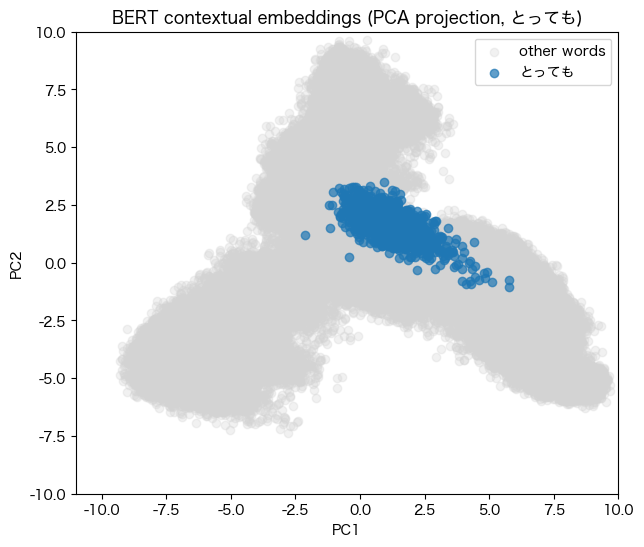

--- とっても: PC1 low ---
  (-2.12) アカウントとってもっと他の問題について取り組んでくれませんか？
  (-1.22) もし余裕があれば、スタイルマニュアルに沿った書き方（記事冒頭部一つとっても、生年月日の表記の仕方やカッコの使い方など、細かいガイドラインがあります）や、適切なカテゴリの付記などをしていただけると大変助かります。
  (-1.16) あなたはアカウントをとってもう8年近く活動されているのですから、ちゃんと方針を理解したうえで編集に臨んでください。
--- とっても: PC1 high ---
  (+5.77) 普段はささやかな事しかしてませんが、また変な事をしてたら教えて頂けるととってもありがたいです。
  (+5.77) Black-Riverさんとは考え方や、行動に多くの類似点を見つけられてとっても嬉しいです（ご迷惑でなければ良いのですが）今回はBlack-Riverさんに負けちゃいました。
  (+5.10) ::ご理解頂けてとっても嬉しいです。
--- とっても: PC2 low ---
  (-1.05) 普段はささやかな事しかしてませんが、また変な事をしてたら教えて頂けるととってもありがたいです。
  (-0.93) とっても嬉しいです。
  (-0.91) とっても感謝です。
--- とっても: PC2 high ---
  (+3.49) 野球記事における編集をいくつか確認しましたが、加筆、書き換え、記述位置の移動など、どれをとっても出典を伴なったものとはいえず、一部は差し戻させていただきました。
  (+3.33) :会話ページの節の使い方、署名、プレビュー、どれをとっても「''ルールを熟読''」したとは、とても思えません（これらがおかしくとも、通常は投稿ブロック対象ではありませんが、この程度の簡単な基本ルールは覚えて下さい）。
  (+3.27) 現在の方針では、どれをとっても宣伝という結論には至りません。


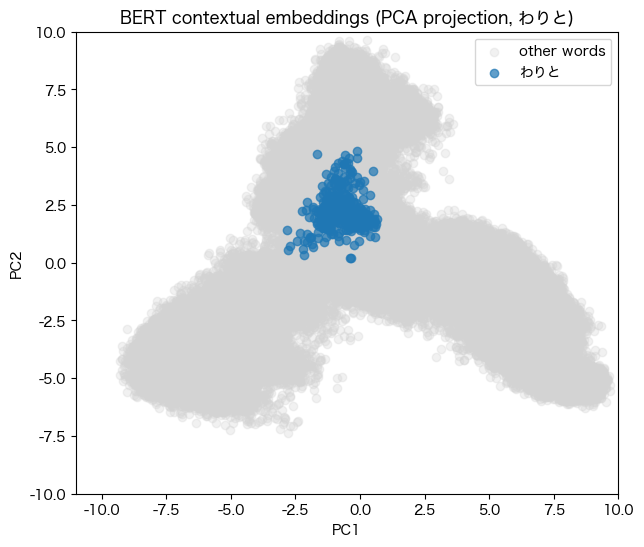

--- わりと: PC1 low ---
  (-2.81) 「コメント依頼、投稿ブロック依頼の提出の多さ（正直いえば、あまりに提出ペースが多くないでしょうか…？）」<br>「言葉の端々でのニュアンス的なこと。もう少しやんわりとした言い方ができれば、より望ましいのでは…？（言い方に「とげがある」ように感じることが、意見を何回か拝読する機会があったときに、正直自分の中では感じたのです。自分の思い過ごしならばよいのですけど）」
  (-2.80) 私が「自分語り」をした理由ですが･･･　お二方がネットに貴重な時間を注ぎ込み過ぎているように見えて、やんわりと「忠告」がしたくなったので、「[[Wikipedia:個人攻撃はしない|個人攻撃]]」にだけは絶対にならないよう、正直に、自分にとっては'''恥'''でしかない情報をさらけ出してでも「昔、自分も同じことをやっていた。あれは最悪の失敗だった」という語り口にさせていただきました。
  (-2.72) 忌憚なく申しますが、「やんわりと「忠告」がしたくなった」、「罪」などの言葉を用いるあたり、あなたの考えていることを理解し難いですし、これまでのあなたの編集内容を鑑み、[[Wikipedia:投稿ブロック依頼/Murakami akira, hokkaido 20211004]]を提出することにします。
--- わりと: PC1 high ---
  (+0.65) 具体的には、ウィキペディア英語版の「[[en:Kim Tae-hee#Career]]」を翻訳して「経歴」か「来歴」の項目を作るとわりとかんたんです。
  (+0.64) おれの推測では、Mariemonさんは、わりとご年配の方であり、インターネットやWikipediaにはいまのところたいして慣れていないのではないかと思います。
  (+0.59) 私は必要であるか必要でないかという意見を書いたのでその部分だけ引用されましたが「和暦を使った方が説明をしやすい記事（例えば、令和元年5月1日(元号改変日)に発売した）などは記載しても良いかと思います。」の併用する理由があるなら併用してもいいんじゃないという部分はわりと重要です。
--- わりと: PC2 low ---
  (+0.22) いつもお優しいメッセージを賜り、また芳しい香り漂うコーヒーをいただきまして、心身と

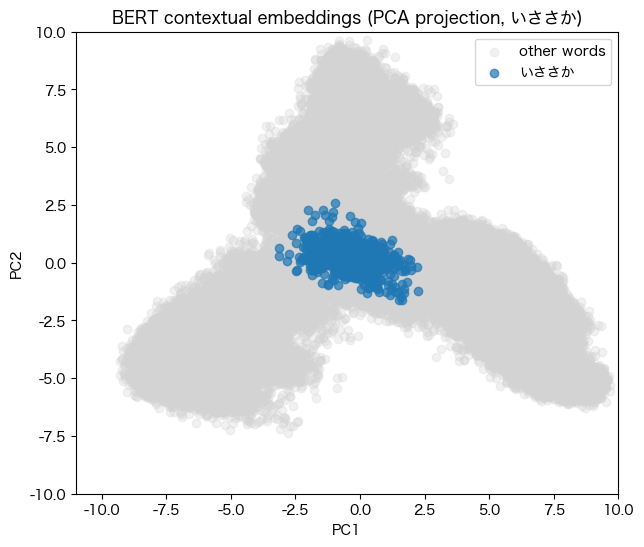

--- いささか: PC1 low ---
  (-3.14) 手元には、海産無脊椎動物に関する論文がいささか集積されておりますゆえ、今後もときたま Almandine さまの手になる記事におせっかいをしてしまうかもしれませんが、どうぞご寛恕いただければと思います。
  (-3.13) m:日本語版ウィクショナリーの整備の議論は4月8日を最後にとまっていましたので、僭越ながらいささかのまとめを行いました。
  (-2.82) 昔から艦船のインフォボックスに関してはいろいろな争いがあってそのまま来ているのですが、最近また[[利用者:ひななみ|ひななみ]]さんが精力的に改変なさっているようで、それがまた以前までの状態とかなり変化してきているので、以前のインフォボックス編集に関していささか関わっていた身からすると、あまり勝手にやられてもと感じている次第です。
--- いささか: PC1 high ---
  (+2.24) いささか失礼に思いました。
  (+2.21) こんなことをお願いするのは不躾でいささか恐縮ですが、Asturio Cantabrioさんに[[:es:Cocido]]の翻訳記事作成をお願いできないでしょうか。
  (+1.97) [[深大寺]]における修正についてですが、修正内容が「中途半端」と書かれたのはいささか心外です。
--- いささか: PC2 low ---
  (-1.61) VZP10224さんが私の編集を「編集内容をいちいちチェックする必要がないような既知の荒らし」と認識されているのでしたら、私自身は[[Wikipedia:荒らし|荒らし]]をおこなったつもりがないだけに、いささか残念に思います。
  (-1.60) いささか残念ですが、そのような事情があるなら仕方ないと思います。
  (-1.49) それにもかかわらず、湯どんぶりさんは「いささか残念」という前置きを置いた上で、私が提案理由を読んでいないと'''断言'''されました。
--- いささか: PC2 high ---
  (+2.58) 藤倉氏の批判に関する言及など、いささかも、百科事典に記載するに値しないでしょう。
  (+2.27) 「[[Wikipedia:外部リンクの選び方#掲載すべきでない外部リンク]]に「SNS（ソーシャル・ネットワーキング・サービス）およびそ

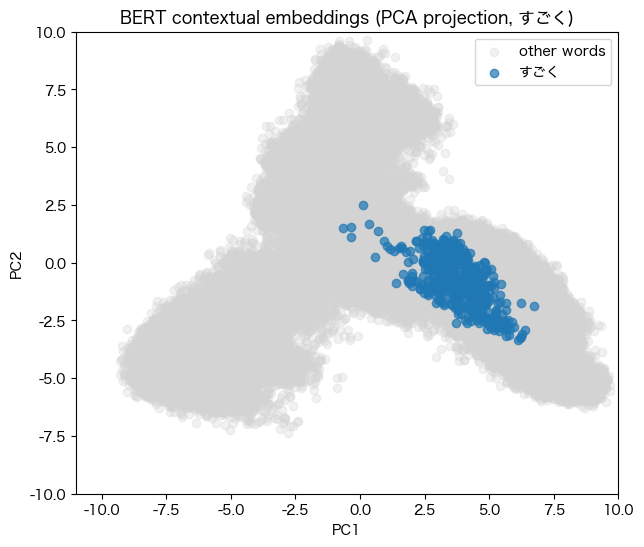

--- すごく: PC1 low ---
  (-0.67) また、日本に暮らすごく普通の学生、沙慈も世界の変革へと徐々に巻き込まれていく。
  (-0.37) * 隣の[[利用者:まいすごく|利用者ページ]]は自己紹介や作業用のスペースとして利用することができます。
  (-0.33) --まいすごく
--- すごく: PC1 high ---
  (+6.74) ホーリーブライト様の返信は私にとってすごくありがたいものでしたので返信を表示させたいです。
  (+6.37) というか、他のユーザーの方との交流ができるのがこのノートページくらいしかないので、何でもいいのでつぶやきにでも来ていただけるとすごくうれしいです。
  (+6.28) 私は地理学を学んだ学生だったのでこういう記事が増えるとすごくうれしいです。
--- すごく: PC2 low ---
  (-3.33) すごく迷惑です。
  (-3.28) 今までのIPのときもいろんなMSGをもらいましたがIP変わるまでの命でしたので、コテハン第一号MSGで、すごくうれしいです。
  (-3.20) ご意見を頂けてすごく助かりました、ありがとうございます。
--- すごく: PC2 high ---
  (+2.48) とりあえず、Cenatusu自身は数年にわたり'''私闘'''を繰り広げているが、今回の追認依頼、前回のWP99氏の依頼でもわかるように、事情に関心もなければ何についてのブロックかまったく知らないその他大勢、つまり'''私闘'''でブロックする海獺氏その他の管理者、あるいはCentaurusu氏のような数年前からいてFXST系ブロックに情熱を燃やすごく一部の利用者以外の利用者にとっては、どうでもよく、被害もなく（私闘を継続する一部利用者をはじめ、気になって仕方がない利用者の内心では大きな問題であるらしいが）そういう事態の変化、に私闘を続けるものとしては、危機感を抱いており、「関係ない話なら黙っててください」というコメント、2chでの個人情報暴露、殺害予告、悪質さの強調、ブロックの正当性を教育するような啓蒙活動あるいはあらし行為を執拗に行っているものと観察されます。
  (+1.67) 屁理屈でどうこう言っている訳では無いのです…仮に私が札幌の薄野のすごくおいしいラーメン屋さんを発見したとします

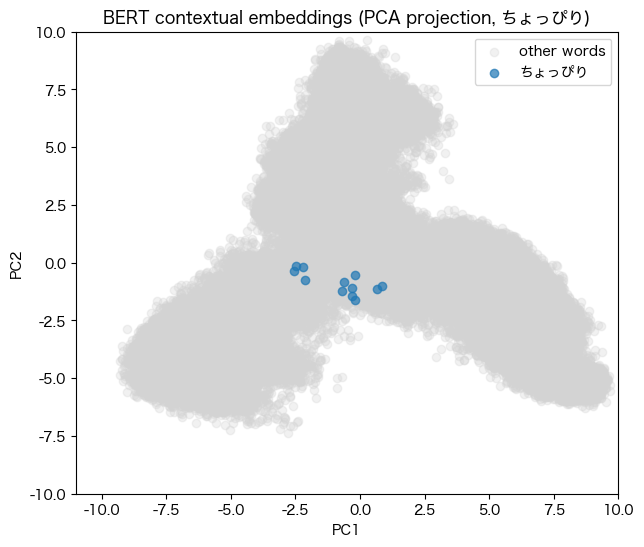

--- ちょっぴり: PC1 low ---
  (-2.57) 長文だったため今までのように読んでいないp tmpでも読めるように文章を、ほんのちょっぴりだけ丁寧に文章を清書しました。
  (-2.50) * 恋をちょっぴり忘れたあなたに（[[AbemaTV]]）
  (-2.19) 明らかにシューマン家とアルカンに、面識はちょっぴりあったのです。
--- ちょっぴり: PC1 high ---
  (+0.86) 何となく上げたコモンズ画像が、他言語の思わぬプロジェクトで使われてたりすると、ちょっぴりうれしいものですよ。
  (+0.67) でも後に、削除議論の途中に割り込んで私への個人批判を書かれた時には、正直ちょっぴりがっかりしました。
  (-0.20) ただ、正直言って、ちょっぴり面倒くさい人だとは思っておりますがね。
--- ちょっぴり: PC2 low ---
  (-1.62) 利用者名を変更されたとのことで、見慣れていた者としてはちょっぴり寂しい気もします。
  (-1.42) Nakaoka7675さんがノータッチの記事も「翻訳した記事」の中に含まれていたのでちょっぴり気になりました。
  (-1.24) いくつか私が書いた項目にリンクとしてつながっていることも、手前味噌ながらちょっぴり誇らしかったりしますf^^;。
--- ちょっぴり: PC2 high ---
  (-0.14) * 恋をちょっぴり忘れたあなたに（[[AbemaTV]]）
  (-0.18) 明らかにシューマン家とアルカンに、面識はちょっぴりあったのです。
  (-0.36) 長文だったため今までのように読んでいないp tmpでも読めるように文章を、ほんのちょっぴりだけ丁寧に文章を清書しました。


In [ ]:
# Fit PCA ONCE on all words together, then reuse the same projection for every
# subplot below -- this is what makes the per-word plots comparable to each
# other and to the "all words" plot (same PC1/PC2 axes throughout).
bert_pca2, bert_coords2, bert_labels2 = fit_pca_projection(bert_vectors_by_word)

plot_pca_scatter_precomputed(bert_coords2, bert_labels2, words,
                              "BERT contextual embeddings (PCA projection, all words)")

# show dots separated by word because colors are hard to distinguish when there are many words.
for word in words:
    # same xlim/ylim (and same underlying PCA fit) for every word so the plots are directly comparable.
    plot_pca_scatter_precomputed(
        bert_coords2, bert_labels2, [word],
        f"BERT contextual embeddings (PCA projection, {word})",
        xlim=(-11, 10), ylim=(-10, 10),
    )

    # show sentences at each end of the PCA projection (for this word's own points)
    mask = bert_labels2 == word
    coords = bert_coords2<mask>
    sents = bert_sentences_by_word[word]
    for axis, name in [(0, "PC1"), (1, "PC2")]:
        order = np.argsort(coords[:, axis])
        print(f"--- {word}: {name} low ---")
        for i in order[:3]:
            print(f"  ({coords[i, axis]:+.2f}) {sents[i]}")
        print(f"--- {word}: {name} high ---")
        for i in order[-3:][::-1]:
            print(f"  ({coords[i, axis]:+.2f}) {sents[i]}")


## Which dimensions do the modifiers vary along?

Raw embedding dimensions have no built-in labels — "dimension 347" doesn't mean anything by itself. The standard way to make PCA axes interpretable is:

1. Run PCA across **all** example vectors (pooled across every word) and check how much variance each component explains (scree plot).
2. For each of the top components, read the actual sentences sitting at the **extremes** of that axis — the contrast between the low-scoring and high-scoring sentences tells you what that axis is tracking (e.g. formality, negation/hedging, sentence length, degree strength, evaluative tone, etc.).
3. Project each word's average onto the same axes to see which words systematically lean toward one end vs. the other.

In [45]:
def pca_dimension_analysis(vectors_by_word, sentences_by_word, n_components=5):
    """Fit PCA across all words' vectors pooled together; return the fitted
    PCA object plus per-example scores, source sentences, and word labels."""
    words = list(vectors_by_word.keys())
    X = np.vstack([vectors_by_word[w] for w in words])
    sent_all = sum([sentences_by_word[w] for w in words], [])
    labels_all = np.concatenate([[w] * len(vectors_by_word[w]) for w in words])

    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(X)

    print("Explained variance ratio per component:")
    for i, ev in enumerate(pca.explained_variance_ratio_):
        print(f"  PC{i + 1}: {ev:.3f} ({ev * 100:.1f}%)")
    print(f"  cumulative (first {n_components}): {pca.explained_variance_ratio_.sum():.3f}")

    return pca, scores, sent_all, labels_all


def show_pc_extremes(scores, sentences, labels, component=0, top_k=5):
    """Print the sentences at the low and high extremes of a given PC —
    read these to figure out what that axis represents."""
    order = np.argsort(scores[:, component])
    print(f"=== PC{component + 1} — low extreme ===")
    for idx in order[:top_k]:
        print(f"  [{labels[idx]}] (score={scores[idx, component]:+.2f}) {sentences[idx]}")
    print(f"\n=== PC{component + 1} — high extreme ===")
    for idx in order[-top_k:][::-1]:
        print(f"  [{labels[idx]}] (score={scores[idx, component]:+.2f}) {sentences[idx]}")


def show_pc_range(scores, sentences, labels, component=0, n_bins=5, examples_per_bin=3):
    """
    Show example sentences spread across the *entire* range of a PC, not
    just the two extremes -- splits the sorted scores into n_bins
    equal-count bins (percentile bins) and prints a few evenly-spaced
    example sentences from each bin, low to high. Use this alongside (or
    instead of) show_pc_extremes when you want to see the middle of the
    range too, not just the tails.
    """
    order = np.argsort(scores[:, component])
    n = len(order)
    bin_edges = np.linspace(0, n, n_bins + 1).astype(int)

    for b in range(n_bins):
        bin_idx = order[bin_edges[b]:bin_edges[b + 1]]
        if len(bin_idx) == 0:
            continue
        lo, hi = scores[bin_idx[0], component], scores[bin_idx[-1], component]
        print(f"=== PC{component + 1} \u2014 bin {b + 1}/{n_bins} (score range {lo:+.2f} to {hi:+.2f}, n={len(bin_idx)}) ===")

        k = min(examples_per_bin, len(bin_idx))
        sample_positions = np.linspace(0, len(bin_idx) - 1, k).astype(int)
        for pos in sample_positions:
            idx = bin_idx[pos]
            print(f"  [{labels[idx]}] (score={scores[idx, component]:+.2f}) {sentences[idx]}")
        print()


def word_mean_scores_table(scores, labels, n_components):
    """Each word's average position along each PC — a compact 'profile' per word."""
    df = pd.DataFrame(scores[:, :n_components], columns=[f"PC{i + 1}" for i in range(n_components)])
    df["word"] = labels
    return df.groupby("word").mean()


Explained variance ratio per component:
  PC1: 0.133 (13.3%)
  PC2: 0.088 (8.8%)
  PC3: 0.065 (6.5%)
  PC4: 0.043 (4.3%)
  PC5: 0.038 (3.8%)
  cumulative (first 5): 0.367


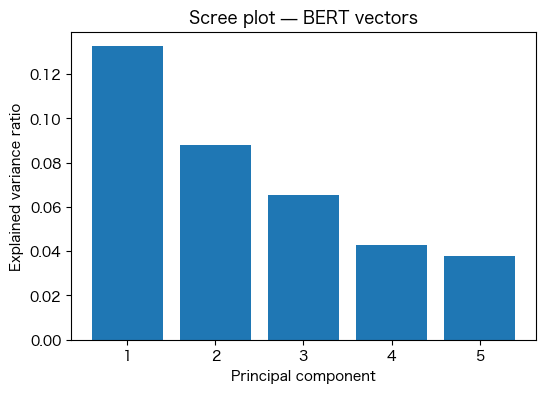

In [31]:
bert_pca, bert_pc_scores, bert_pc_sentences, bert_pc_labels = pca_dimension_analysis(
    bert_vectors_by_word, bert_sentences_by_word, n_components=5
)

plt.figure(figsize=(6, 4))
plt.bar(range(1, 6), bert_pca.explained_variance_ratio_)
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("Scree plot — BERT vectors")
plt.show()


In [44]:
# Read these to interpret what PC1 is tracking
show_pc_extremes(bert_pc_scores, bert_pc_sentences, bert_pc_labels, component=0, top_k=5)

# ...and these to see the full range, including the middle, not just the two extremes
show_pc_range(bert_pc_scores, bert_pc_sentences, bert_pc_labels, component=0, n_bins=5, examples_per_bin=3)


=== PC1 — low extreme ===
  [少し] (score=-9.29) そして改めてお願いしたいのは、こちらの節のタイトルにもありますように、少し調べたらわかりそうな内容もあるのですから、そのあたりはちゃんと「取捨選択」をしていただきたいて、「要出典タグ」をつけるなどしていただきたく思います。
  [少し] (score=-9.29) JapaneseAさん、少し私の愚痴を聞いてください。
  [少し] (score=-9.22) 出典を挙げて記事を加筆することは歓迎されることですが、持ち込まれる出典が少し調べればこのような問題がでてくるものばかりなのはいかがなものでしょうか。
  [少し] (score=-9.21) そういった事はなにもウィキペディアでなさらずとも、外を少し見回せば Twitter などのそれにふさわしい場がいくらでもあるのですから、そういった欲求はそちらの方で吐き出していってくださいますようお願いします。
  [少し] (score=-9.21) そういった事はなにもウィキペディアでなさらずとも、外を少し見回せばTwitterなどのそれにふさわしい場がいくらでもあるのですから、そういった欲求はそちらの方で吐き出していってくださいますようお願いします。

=== PC1 — high extreme ===
  [大変] (score=+9.69) この度は当方の思慮を欠いた独善的行為によりご迷惑をおかけしてしまい、大変申し訳ございませんでした。
  [大変] (score=+9.68) さて、[[LTA:ISECHIKA]]案件の件なのですけれども、各記事での歌詞転載荒らし頻発を受けて、2月28日に私が『[[:Wikipedia:削除依頼/LTA:ISECHIKAによる歌詞転載案件 20110228]]』を作っていたんですが、各記事にサブページへのリンクを貼り忘れてしまったため、今回の新規依頼を立てて下さった貴殿を始め、多くの方のお手数をお掛けすることとなってしまいまして大変申し訳ございません。
  [大変] (score=+9.62) この度はご不快の念をおかけし、大変申し訳ございませんでした。
  [大変] (score=+9.59) この度は、ご迷惑をお掛けしてしまい大変申し訳ございませんでした。
  [大変] (s

NameError: name 'show_pc_range' is not defined

In [48]:
# Read these to interpret what PC2 is tracking
# show_pc_extremes(bert_pc_scores, bert_pc_sentences, bert_pc_labels, component=1, top_k=5)

# ...and these to see the full range, including the middle, not just the two extremes
show_pc_range(bert_pc_scores, bert_pc_sentences, bert_pc_labels, component=1, n_bins=5, examples_per_bin=5)


=== PC2 — bin 1/5 (score range -7.39 to -3.80, n=21036) ===
  [少し] (score=-7.39) 議長を差し置いて編集してしまい少し申し訳なく思います……任せて下さりありがとうございました。
  [大変] (score=-5.15) 大変申し訳ありませんがたとえIPユーザーであっても無期限ブロックになることをご承知おき下さい。
  [大変] (score=-4.69)  英語版の記事でも、他の言語によるウィキの記事でも、アーティスト名はあくまでも「Lipps Inc.」が基本であり、勝手に「リップス」という風に変えられるのは、大変困惑した次第です。
  [少し] (score=-4.25) こんにちは．初めまして．ラクダ関係の編集について少し確認させてください．まず1点目．この編集[https://ja.wikipedia.org/w/index.php?title=%E3%83%95%E3%82%BF%E3%82%B3%E3%83%96%E3%83%A9%E3%82%AF%E3%83%80&diff=75487307&oldid=71891760]において、OHSRW様ご自身が、「フタコブラクダと Wild Bactrian camelは別亜種であるとみなされた。」とお書きになっておられます．別亜種と分けられただけであれば同種であることは越えないのでおそらく勘違いか何かだろうと修正したのですが、そうではないのですか？
  [大変] (score=-3.80) ::: 私の見ましたところ、履歴の継承は問題なく行われている様で、大変結構な状態であるかと思います。

=== PC2 — bin 2/5 (score range -3.80 to -1.45, n=21037) ===
  [大変] (score=-3.80) ご意見は大変参考になりますので、また何かありましたらご遠慮なくお願いします。
  [少し] (score=-3.35) 青木高校生さんは以前から複数の利用者に指摘されているようですが、即時削除の適用はもう少し慎重に考えて頂けませんか。
  [少し] (score=-2.84) ただ、そもそも私の質問の表現がわかりづらかったため、何について質問しているのかもう少し明確にすべきであったとい

In [52]:
# show words for とても
df[df["hedge"] == "とても"].head(5)


,hedge,sentence
44,とても,新しい情報の追記はとてもありがたいのですが、その追記により文章全体の焦点がぼやけてしまわない...
47,とても,[[ソテツ類]]についても、とても良い投稿だと思います。
49,とても,:あれは内容的にはすべてActinium様のものですし、結果的にとても面白い記事になったと感...
50,とても,私も新記事への推薦はこれがはじめてで、他の方の支持がいただけたのはとても嬉しいことでした。
83,とても,バーンスターを頂くのは初めてなので、とてもうれしいです。


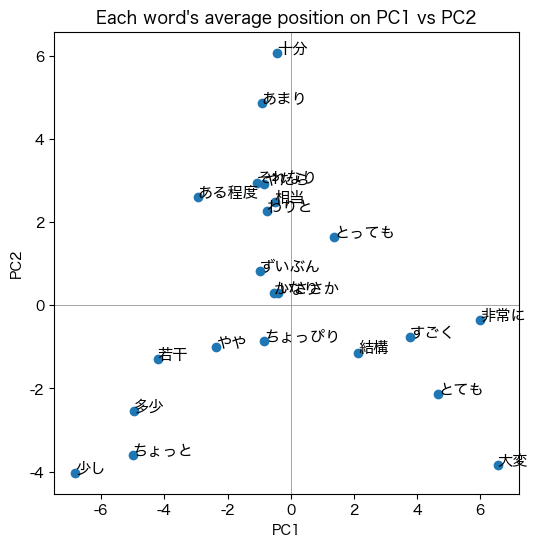

In [49]:
plt.figure(figsize=(6, 6))
plt.scatter(bert_word_profile["PC1"], bert_word_profile["PC2"])
for word, row in bert_word_profile.iterrows():
    plt.annotate(word, (row["PC1"], row["PC2"]), fontsize=11)
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Each word's average position on PC1 vs PC2")
plt.show()


## Part B: Word2Vec-based collocate comparison

Represents each word by the average embedding of the words that tend to surround it (classic distributional semantics). Words with similar surrounding-word profiles are used in similar ways.

In [64]:
def get_context_words(sentences, target_word, window=4):
    """
    Tokenize with fugashi (MeCab) and grab +/- `window` tokens around each
    occurrence of target_word, along with the source sentence.

    Matches by *character span* rather than requiring a single token to
    equal target_word exactly -- MeCab sometimes splits a target word into
    multiple morphemes (e.g. ある程度 -> ある + 程度, それなり -> それ + なり),
    so an exact single-token match would silently find zero occurrences for
    those words and produce an empty vector array downstream. Also handles
    multiple occurrences of the word within the same sentence.
    """
    from fugashi import Tagger
    tagger = Tagger()

    contexts, kept_sentences = [], []
    for sent in sentences:
        tokens = [tok.surface for tok in tagger(sent)]

        # reconstruct each token's character span in the original sentence
        offsets = []
        cursor = 0
        for t in tokens:
            idx = sent.find(t, cursor)
            if idx == -1:
                offsets.append(None)
                continue
            offsets.append((idx, idx + len(t)))
            cursor = idx + len(t)

        search_from = 0
        while True:
            idx = sent.find(target_word, search_from)
            if idx == -1:
                break
            target_start, target_end = idx, idx + len(target_word)

            token_idx = [
                i for i, off in enumerate(offsets)
                if off is not None and off[0] < target_end and off[1] > target_start
            ]
            if token_idx:
                left = tokens[max(0, token_idx[0] - window):token_idx[0]]
                right = tokens[token_idx[-1] + 1:token_idx[-1] + 1 + window]
                contexts.append(left + right)
                kept_sentences.append(sent)

            search_from = idx + max(1, len(target_word))

    return contexts, kept_sentences


def train_word2vec_on_corpus(all_sentences, vector_size=100):
    """Train Word2Vec directly on the pooled example sentences across all words."""
    from gensim.models import Word2Vec
    from fugashi import Tagger
    tagger = Tagger()
    tokenized = [[tok.surface for tok in tagger(sent)] for sent in all_sentences]
    return Word2Vec(sentences=tokenized, vector_size=vector_size, window=5, min_count=1, sg=1)


def average_context_vector(contexts, w2v_model, sentences=None):
    vecs, kept_sentences = [], []
    for i, ctx in enumerate(contexts):
        word_vecs = [w2v_model.wv[w] for w in ctx if w in w2v_model.wv]
        if word_vecs:
            vecs.append(np.mean(word_vecs, axis=0))
            if sentences is not None:
                kept_sentences.append(sentences[i])
    vecs = np.array(vecs)
    return (vecs, kept_sentences) if sentences is not None else vecs


def context_vectors_multi(word_sentences, w2v_model, window=4):
    vectors_result, sentences_result = {}, {}
    for word, sents in word_sentences.items():
        contexts, kept = get_context_words(sents, word, window=window)
        vecs, kept2 = average_context_vector(contexts, w2v_model, sentences=kept)
        vectors_result[word] = vecs
        sentences_result[word] = kept2
    return vectors_result, sentences_result


In [66]:
word_sentences = {w: df[df['hedge'] == w]['sentence'].tolist() for w in words}
all_sentences = [s for sents in word_sentences.values() for s in sents]
w2v_model = train_word2vec_on_corpus(all_sentences)

w2v_vectors_by_word, w2v_sentences_by_word = context_vectors_multi(word_sentences, w2v_model)


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


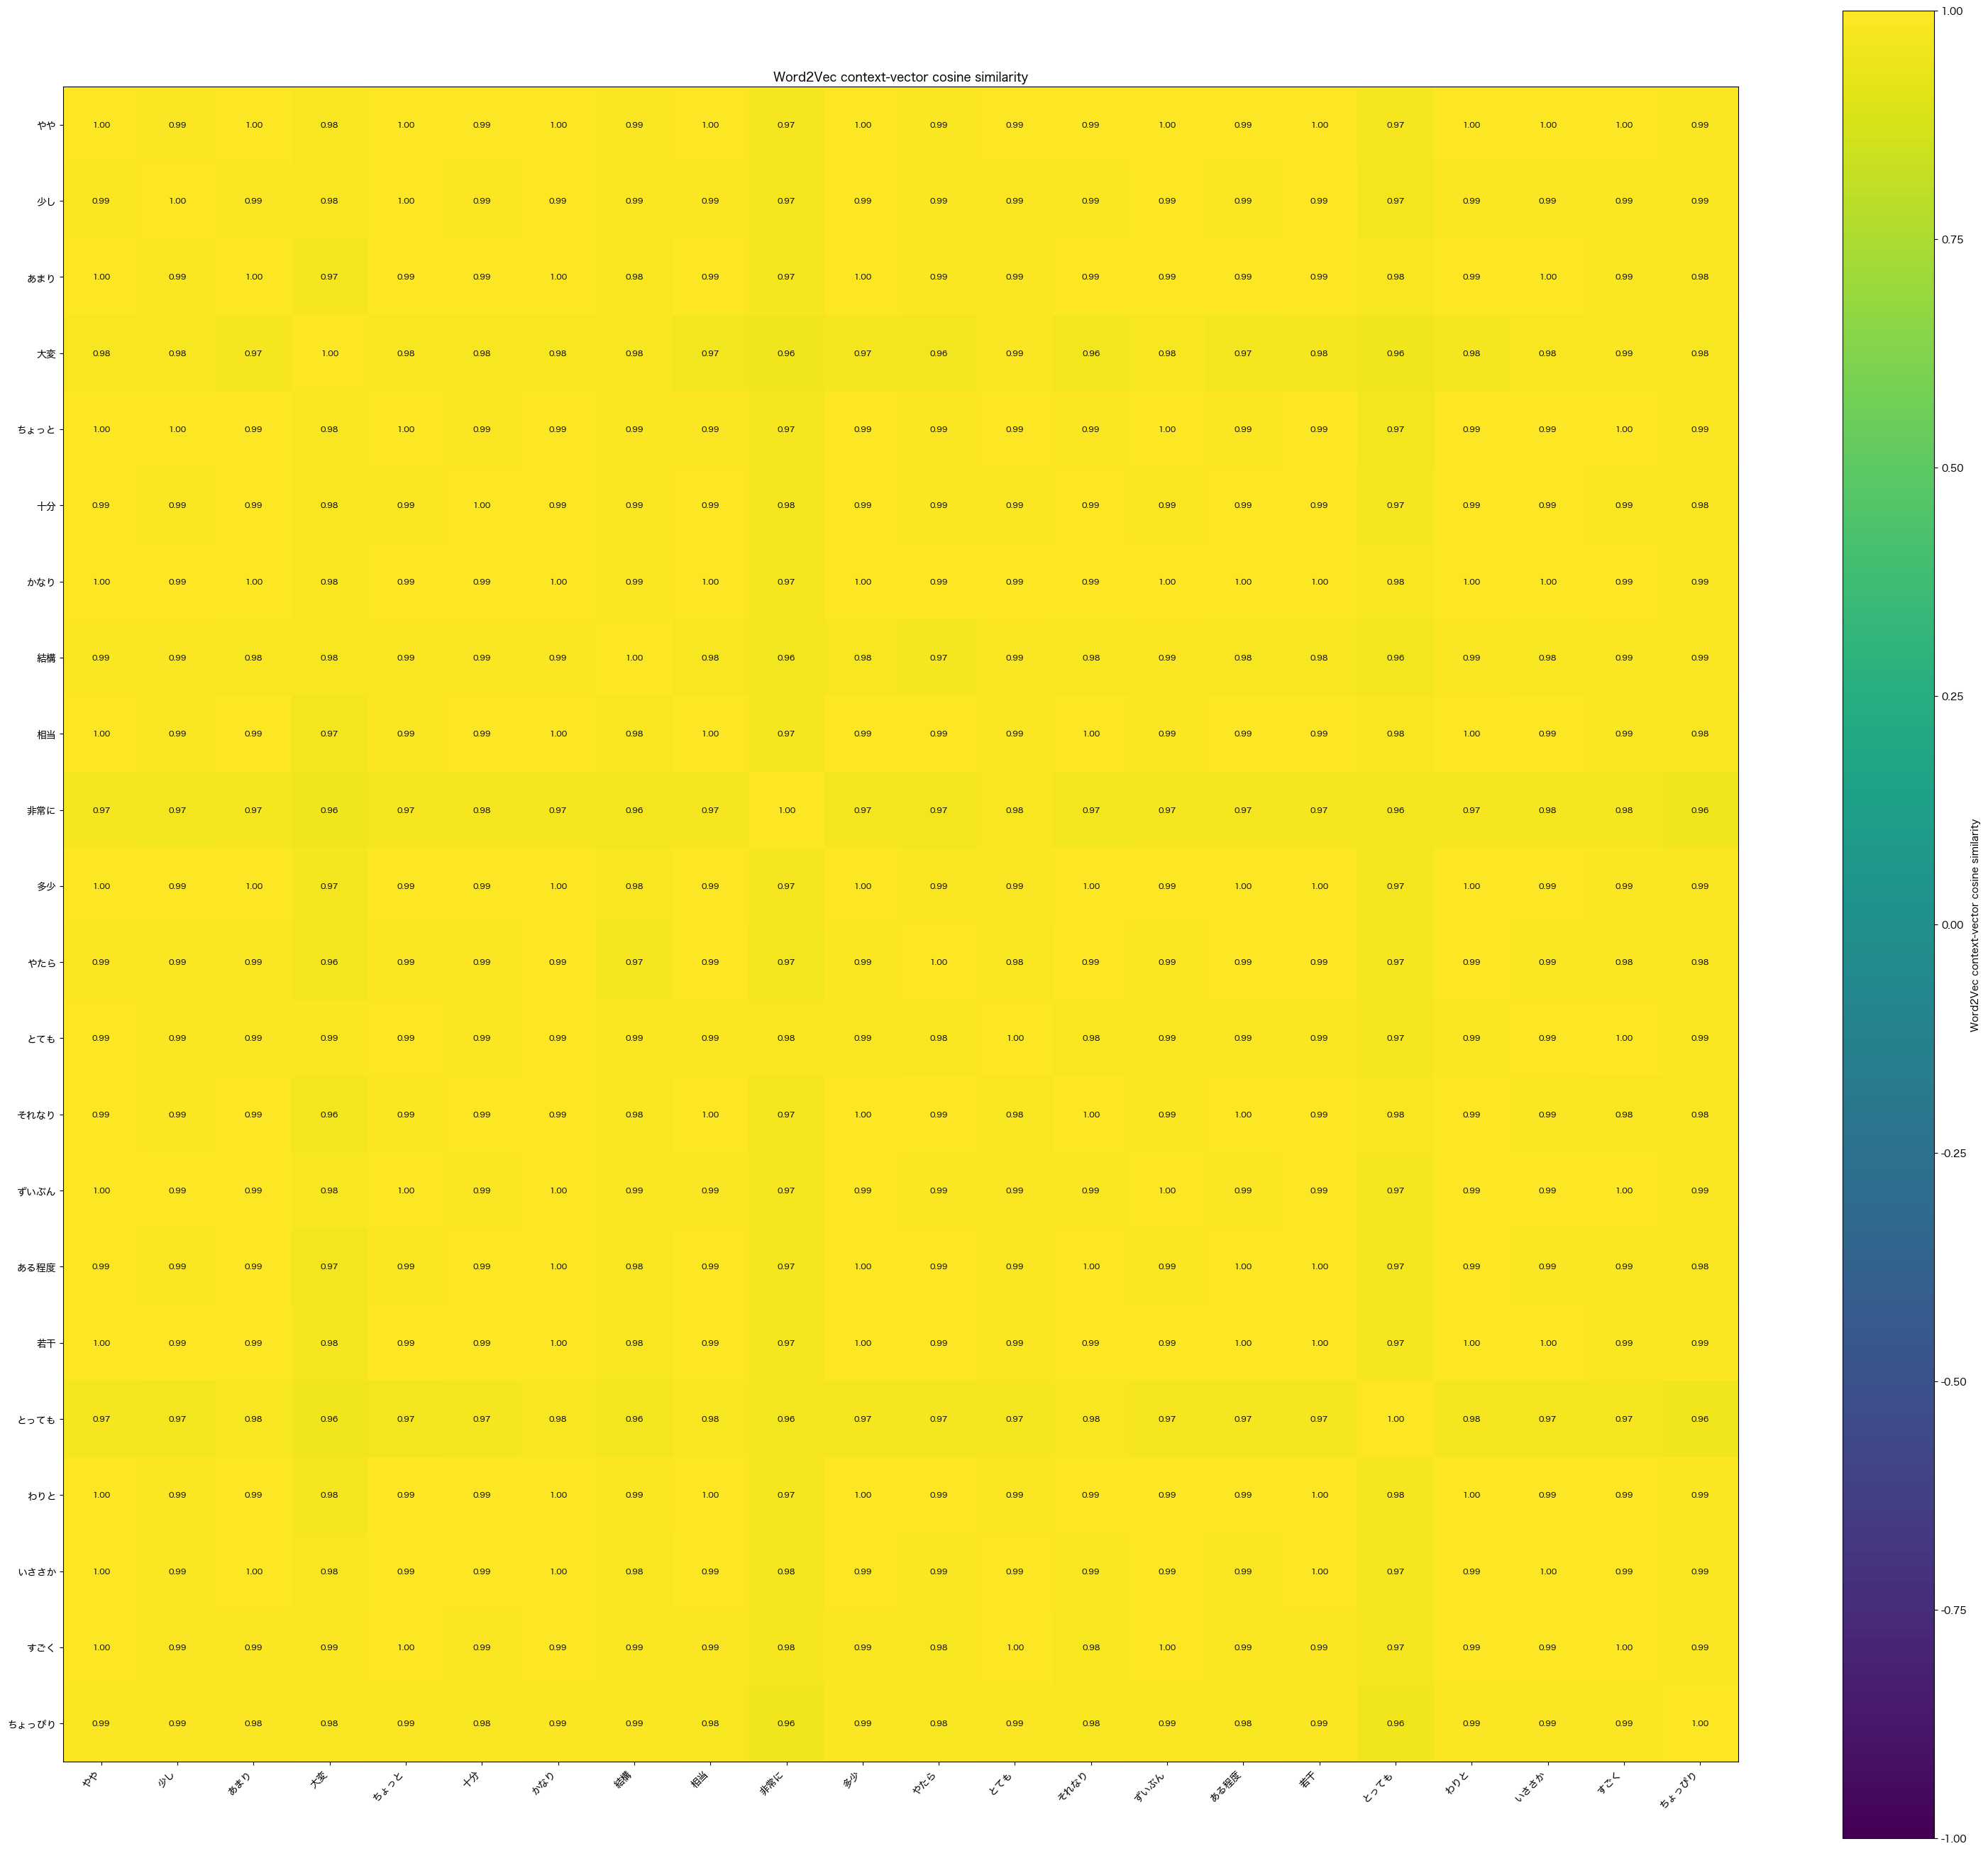

In [69]:
check_no_empty(w2v_vectors_by_word)
w2v_sim_matrix = centroid_similarity_matrix(w2v_vectors_by_word)
plot_matrix(w2v_sim_matrix, "Word2Vec context-vector cosine similarity", vmin=-1, vmax=1)


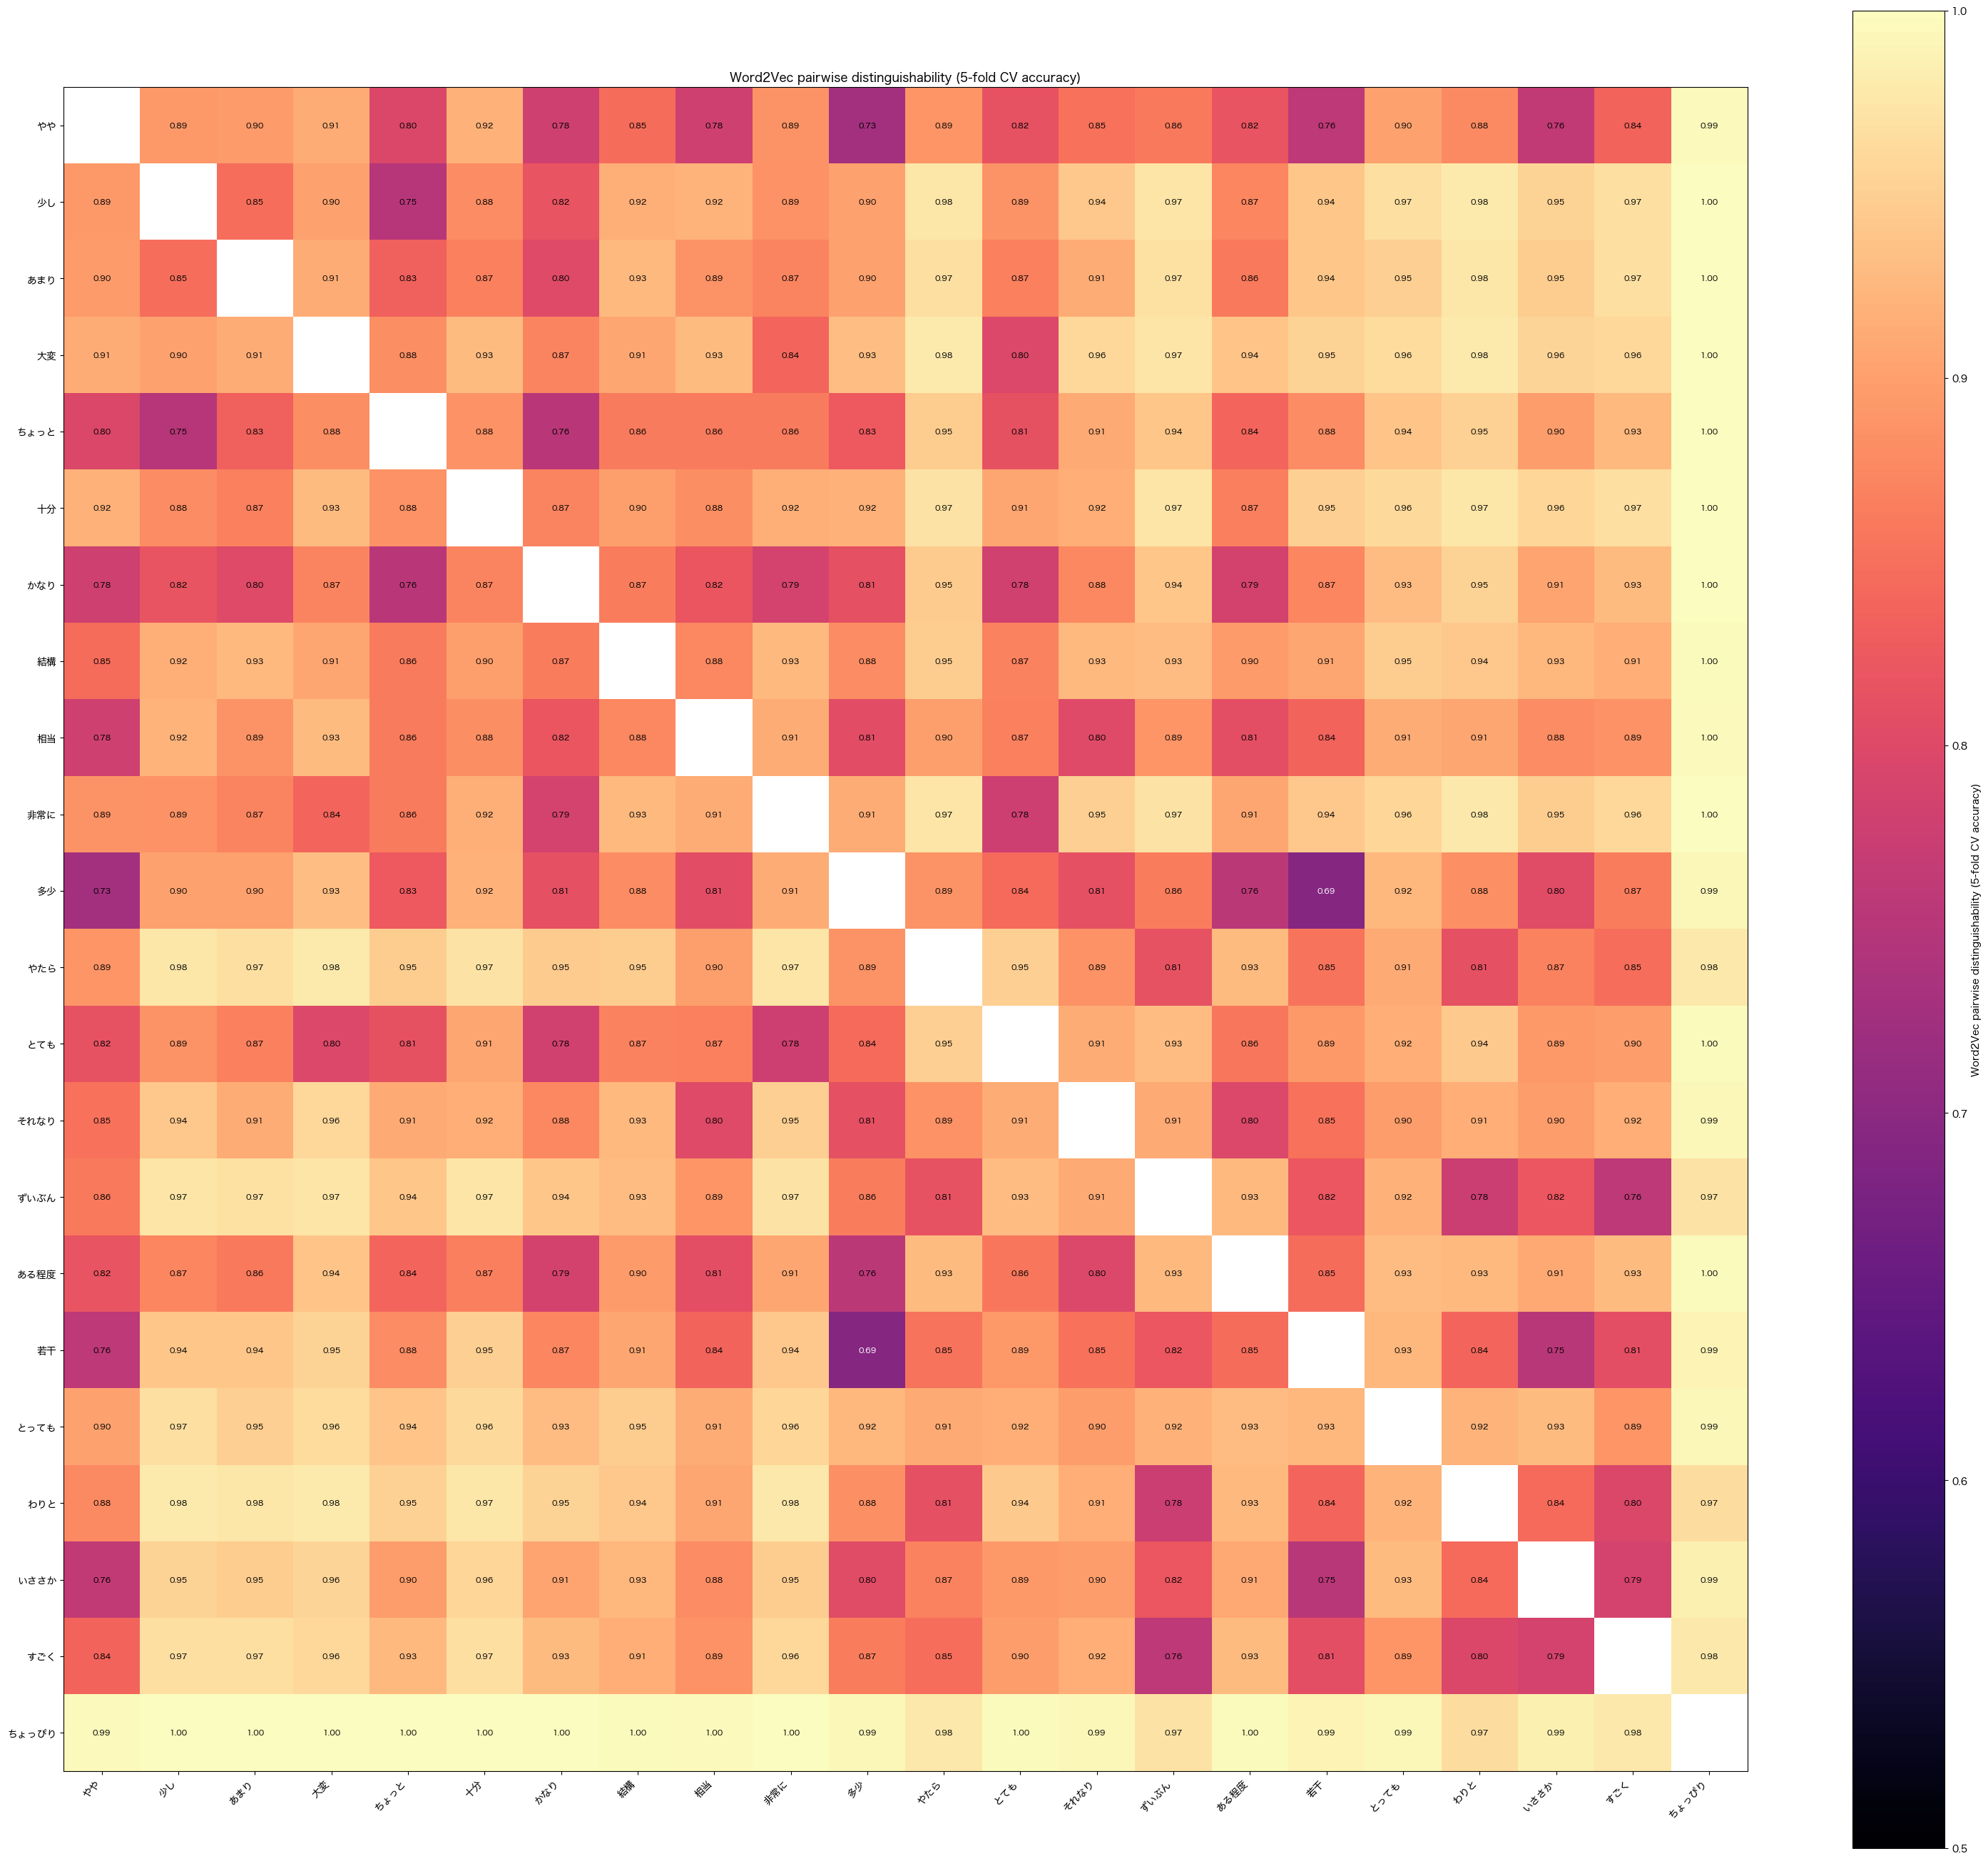

In [70]:
w2v_accuracy_matrix = pairwise_classifier_accuracy_matrix(w2v_vectors_by_word)
plot_matrix(w2v_accuracy_matrix, "Word2Vec pairwise distinguishability (5-fold CV accuracy)", vmin=0.5, vmax=1.0, cmap="magma")


### Same per-word / shared-axes view, for the Word2Vec vectors

Same approach as the BERT section: fit PCA once on all words together, then reuse that single projection (and shared axis limits) for the "all words" plot and every per-word plot, so they're directly comparable to each other.

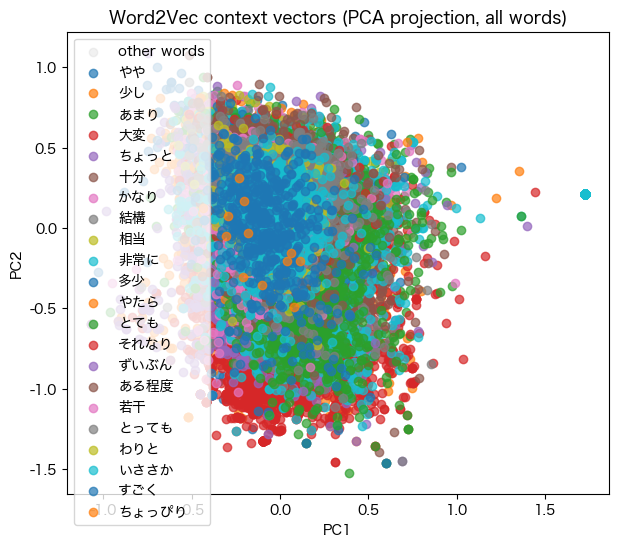

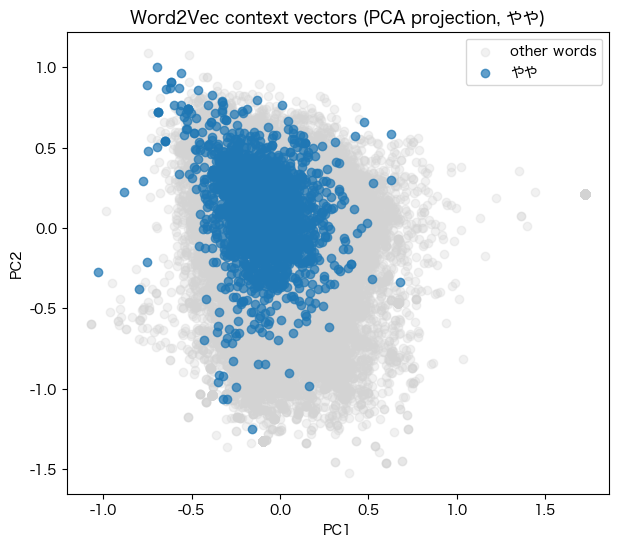

--- やや: PC1 low ---
  (-1.03) == ややや ==
  (-0.88) == やや日刊カルト新聞 ==
  (-0.80) === やや具体的 ===
--- やや: PC1 high ---
  (+0.68) ややこしい人だ。
  (+0.63) Gowithitjamさんとやや意見の相違があるようですが、対話という場を設けていただいて助かります。
  (+0.63) [http://ja.wikipedia.org/w/index.php?diff=next&oldid=43730364 「Uaa氏が存続票を投じたAV女優記事はほとんど削除されていることも考慮されてください。」]というのもやや強引な意見だと思います。
--- やや: PC2 low ---
  (-1.25) ややこしくて申し訳ございません。
  (-1.07) ややこしくてすみません。
  (-1.06) ややこしくしてしまい申し訳ございません。
--- やや: PC2 high ---
  (+1.00) [[やや日刊カルト新聞]]の削除依頼を出しています。
  (+0.96) やや日刊カルト新聞の記者のプライバシーを侵害する行為を行ない、やや日刊カルト新聞側がコメント欄から記者のプライバシーに関連する情報を削除している事実があることを確認しないまま勝手に誤解して「一切削除していない」などというデマを書き、デマであることを指摘されても謝罪すらせずに、教えてやったのだから感謝しろと言われたところで、こちらに感謝の気持ちなど湧くわけがないことを追記しておきます。
  (+0.91) html |website=[[藤倉善郎|やや日刊カルト新聞社]]|access-date=2023-02-19 |language=ja}}</ref>。


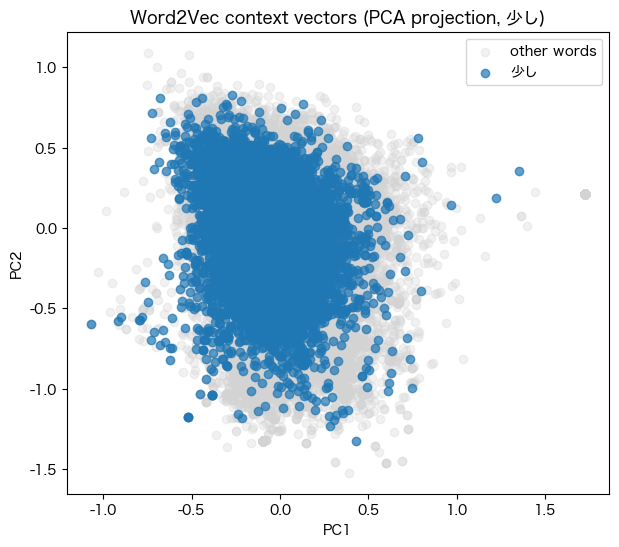

--- 少し: PC1 low ---
  (-1.07) == 少し ==
  (-0.92) == 少し質問 ==
  (-0.90) == もう少し ==
--- 少し: PC1 high ---
  (+1.35) 少しご意見とは異なった形であったかもしれませんが、改名を実行させていただきました。
  (+1.22) 少しは反映して欲しい。
  (+0.97) Black-Riverさんの基準でもこのへんは境界線にあると思いますので、こちらの意見を少し反映させてください。
--- 少し: PC2 low ---
  (-1.33) 少しお待ち下さい。
  (-1.23) 少しお待ちください。
  (-1.19) 少しお待ちいただけますか。
--- 少し: PC2 high ---
  (+0.83) 少し教会史を知るようになった人からは「19世紀以降のロシアはカトリックから悪影響を受けた」と仰る声はたまに聞きますが、ウクライナ限定で言う人は、私は一般信徒レベルからは聞いた事がありません。
  (+0.81) 少し[[強迫性障害]]気味なところがあるため、必ずそうしてください。
  (+0.81) 現在、[[沖佳苗]]、少し前に[[南條愛乃]]と[[内田彩]]で、[[プロジェクト:芸能人]]に由来、あるいは似たスタイルを提案をしたのですが、どうにも劣勢です。


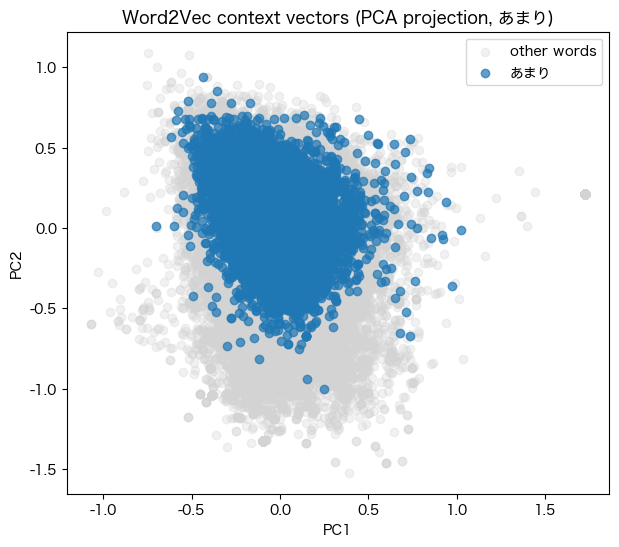

--- あまり: PC1 low ---
  (-0.70) 　　　　あまりにしつこく差し戻しているため対応のほどよろしくお願いします。
  (-0.62) あまりに「放送前の作品を入れるのはよくない」ということに囚われすぎているのではないでしょうか？
  (-0.60) あまりに誤字脱字などが多いと修正に手間がかかり、コミュニティの疲弊の原因ともなりますので、失礼を承知でお願いさせていただきます。
--- あまり: PC1 high ---
  (+1.02) まだあまりご意見が頂けていないので、プロジェクトに参加されている方にお知らせに参りました。
  (+0.97) あまりご存じないことには手を出されないよう、ご忠告申し上げます。
  (+0.94) あまり重要なことではないのですが、お願いがあります。
--- あまり: PC2 low ---
  (-1.00) あまりです。
  (-0.94) あまり急ぎません。
  (-0.82) == あまり歓迎いたしませんリスト ==
--- あまり: PC2 high ---
  (+0.94) ただ、日本の高山植物では中部山岳地帯や大雪山などの高山帯以外にも、標高800メートルあまりのアポイ岳や最高標高500メートル以下の礼文島などにれっきとした高山植物群落があり、それら高山帯以外の高山植物群落についても記事内でかなりのウエイトを置いた説明をしているので、「日本の高山植物相は日本の高山帯に生育する植物相である」といった書き出しはちょっと無理かと思います。
  (+0.85) あまりバスク関係の項目を作成することはないと思いますが、もし作成することがあったらポータルにも追加しようと思います。
  (+0.79) )あまりペーパーマリオRPG以外のペーパーマリオシリーズの記述と比較しないようにお願いします。


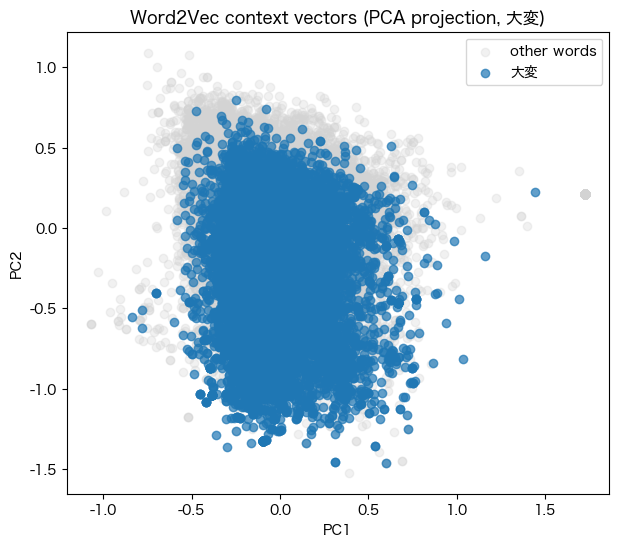

--- 大変: PC1 low ---
  (-0.84) == いろいろ大変 ==
  (-0.78) == 大変貴重 ==
  (-0.78) == 大変失礼ながら ==
--- 大変: PC1 high ---
  (+1.44) 大変興味深いご意見ですが、そうしたご提案はここに書かれるよりも、当該タグのガイドラインページのノートに書かれるべきではないかと思います。
  (+1.16) 大変重要なご連絡をありがとうございます。
  (+1.04) この観点から管理者さんに査読頂いて、もっと加筆してほしい、分かりづらいなどなどご意見頂けたら大変助かります。
--- 大変: PC2 low ---
  (-1.46) 大変助かります。
  (-1.46)  大変ありがとうございます。
  (-1.46) 大変ありがとうございます。
--- 大変: PC2 high ---
  (+0.80) # 大変多くの項目で記述の削除を行っているようですが、それらの項目について十分な知識をお持ちなのでしょうか。
  (+0.74) 登場人物が大変多く、主要人物節を設けるならばどこまでを主要人物にするかはノートでの話し合いも必要なのではないかと思います。
  (+0.73) また[[超!えどっ娘 天下大変!!]]における「そのため、この時間は閑散していたが、当番組のスタートで日曜日夜11時台前半枠が賑わうようになった。」というのは118.


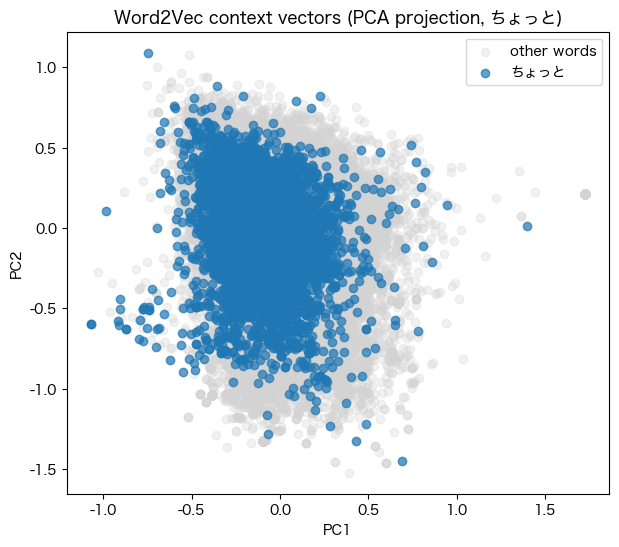

--- ちょっと: PC1 low ---
  (-1.07) == ちょっと ==
  (-1.07) ==ちょっと==
  (-0.99) == ちょっと・・・ ==
--- ちょっと: PC1 high ---
  (+1.40) ちょっとご意見を伺いたいのですが、[[2011年の日本競馬]]においてメジロ牧場閉鎖の記述が追加されましたが、これを「東日本大震災関連」に移すべきかどうか迷っております。
  (+0.94) ちょっと耳の痛い意見もありますが、お二人とも非常にいいコメントを出して下さったと思います。
  (+0.86) ちょっと意見変更です。
--- ちょっと: PC2 low ---
  (-1.45) ちょっと。
  (-1.33) ちょっとお待ち下さい。
  (-1.28) ちょっとすみません。
--- ちょっと: PC2 high ---
  (+1.09) ちょっと[[仮面ライダー電王]]で概要部分を大幅に削減されているのを見て、それをきっかけに履歴を追ってみたのですが、編集方法の是非はともかくとしても、正直なところもう少しノートページでの提起とか、そういったやり方もあってはいいんじゃないかとは思いました。
  (+0.88) ちょっと自治体の記事の編集に集中するので早急な返信はできませんのでご容赦ください。
  (+0.82) ちょっと女ヤプールの統合は早すぎるような…とりあえず、[[統合依頼]]の対処報告をお願いします。


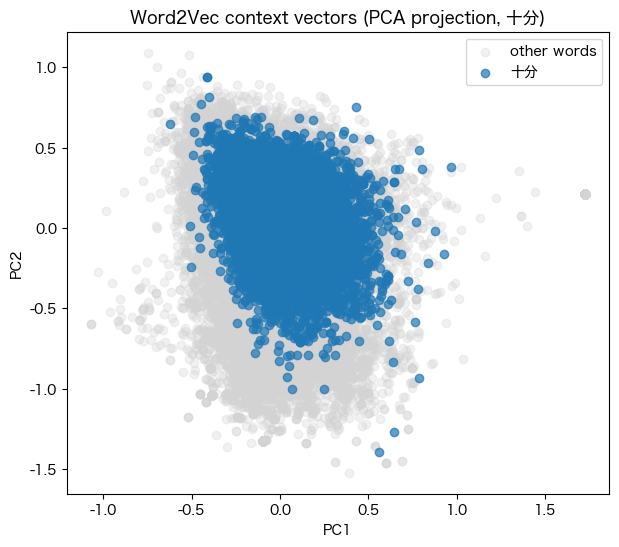

--- 十分: PC1 low ---
  (-0.62) * 十分条件: スーパークルーズ能力を有しているならば第5世代である
  (-0.51) ***十分確認されてたのですね．その上でこの反応ですか．はあ．--[[利用者:AyaTademaru|AyaTademaru]]（[[利用者‐会話:AyaTademaru|会話]]） 2019年11月13日 (水) 14:36 (UTC)
  (-0.51) == 出典が不十分です ==
--- 十分: PC1 high ---
  (+0.97) 二次ソースの内容を敢えて断定的な言葉を用いて書く行為は書き手の意見を十分に反映している=作為が感じられる書き方だと指摘されても仕方ないのではないでしょうか？
  (+0.93) 私はただ記事の充実を望んでいるのみですから、かの自称霊能力者についても正確にその自称する功績が虚構であることを記事に反映できれば十分です。
  (+0.88) 十分ご承知のこととは存じますが、冷静なご対応を何卒お願いいたします。
--- 十分: PC2 low ---
  (-1.39) 十分感謝。
  (-1.27) 十分留意いたします。
  (-1.00) 十分理解いたしました。
--- 十分: PC2 high ---
  (+0.94) ＞学制の違いは当時の教育政策の状況によるもので、専修学校時の経済科は十分に経済学部に該当すると認識されると考えて良いようです。
  (+0.94) 学制の違いは当時の教育政策の状況によるもので、専修学校時の経済科は十分に経済学部に該当すると認識されると考えて良いようです。
  (+0.81) 村田重治死后对日本海军士气打击颇大，包括联合舰队司令长官古贺峰一亲自下令于全军发表讣告，南云忠一更是亲自奔赴村田老家长崎县南高来郡慰问其家属，据说山本五十六生前也十分的信赖村田重治，偷袭珍珠港时所用的浅水鱼雷改进就是聆听了村田重治的意见。


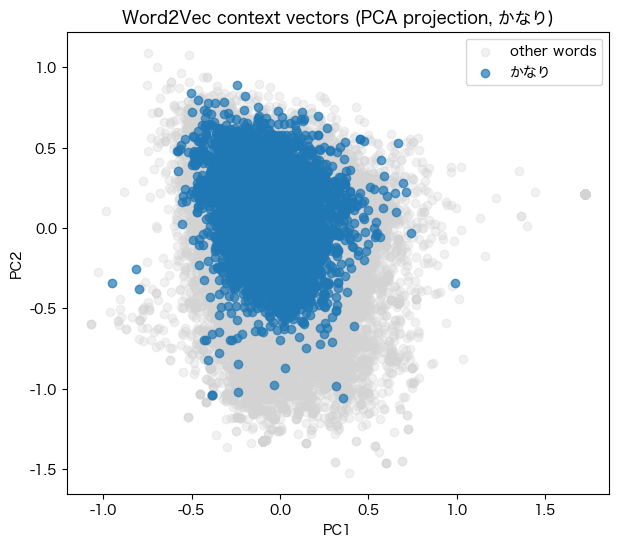

--- かなり: PC1 low ---
  (-0.95) == かなり純情 ==
  (-0.82) <nowiki>==かなり==、==見出し==</nowiki>とはいったいどういった意味でつけられたのでしょうか？
  (-0.80) === かなり具体的 ===
--- かなり: PC1 high ---
  (+0.99) かなり失礼だと考えますが。
  (+0.74) 「投稿内容については追及しない」などと仰っている時点であなたのご意見は論理的に破綻しているため、客観性を欠いた的はずれなご意見にしかなり得ていないのです。
  (+0.71) ::オスマン帝国とビザンツ帝国の戦争でオスマン側に元ビザンツ軍人がいた、というのはかなり重要なことだと思いますが。
--- かなり: PC2 low ---
  (-1.06) かなり嬉しいです。
  (-1.04) かなり遅くなりましたので忘れているかもしれませんがよろしくお願いします。
  (-1.04) かなり遅くなりましたが「クリスマスおめでとうございます」そして「あけましておめでとうございます」。
--- かなり: PC2 high ---
  (+0.89) #:「かなり著名な人物」とする、人物の情報源を記事中に[[Wikipedia:出典を明記する]]の書式に従って記載して下さい。
  (+0.84) :::四、かなり後代の古代中国史書『周書』（六世紀）であるが、「百済伝」では「百済は蓋馬（現在の北朝鮮北方の高原地帯、すなわち、高句麗の北方）の韓に属する。扶余族の別種で昔、「魏志」で述べられている仇台という者がいた場所（すなわち、漢時代の玄菟郡）である。初めての国は帯方（郡の地域）においてである」ほどである。
  (+0.82) IHS・ジェーンズでは、この艦級のかなりの数の艦が、この艦級の全ての艦に備わっているハルソナーに加えて、曳航および可変深度ソナーにより対潜能力が強化されている、とこれまで伝えてきた。


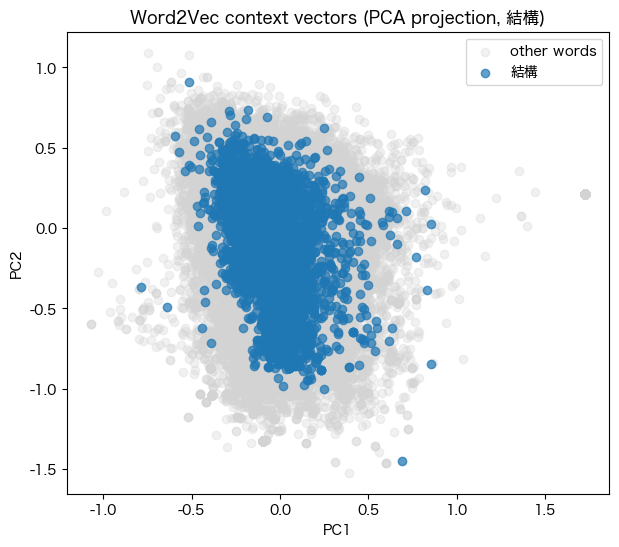

--- 結構: PC1 low ---
  (-0.79) == ストレス、結構 ==
  (-0.64) == 返信は結構です ==
  (-0.59) しかも費用も結構・・・)、「羽衣新天地」については、もし今後立項の可能性があると判断されれば、まだリンク先が出来ていない内部リンク、いわゆる「赤リンク」にしておくと、将来的に楽になる可能性がありますので、ご一考頂けたらと思います。
--- 結構: PC1 high ---
  (+0.86) 結構大変だ。
  (+0.85) なお、私は[[Wikipedia:スタブ]]という考え方は結構重要な考え方だと思っています。
  (+0.83) コメント依頼はShigeru-a24さんの行動指針の一助とすべくご用意いたしましたので、これをきっかけにそうお考えいただけることは結構だと思います。
--- 結構: PC2 low ---
  (-1.45) 結構。
  (-1.00) 結構です。
  (-0.98) なお、本メールにつきましては個人名、連絡先等を除き公表していただきまして結構でございます。
--- 結構: PC2 high ---
  (+0.91) 結構ラムサール条約登録地とかぶっているので、もし同じ記事を書くときにはついでに加筆していただけると助かります。
  (+0.73) バルカンはどこの国にも結構ロマの政党があるようです。
  (+0.73) [https://ja.wikipedia.org/w/index.php?title=%E8%B5%A4%E9%81%93%E3%82%AE%E3%83%8B%E3%82%A2&oldid=prev&diff=66278886 こちら]の件、ジブラルタルの様な海外領土を持つ国（当然島国が前提ですが）がある事そのものは想像出来たのですが、砕けて言えば「隣接・近隣の大陸側に『結構な』面積の領土を持っているにも関わらず、あえて島側に首都を置いてる」事を指しているのかと考えていました。


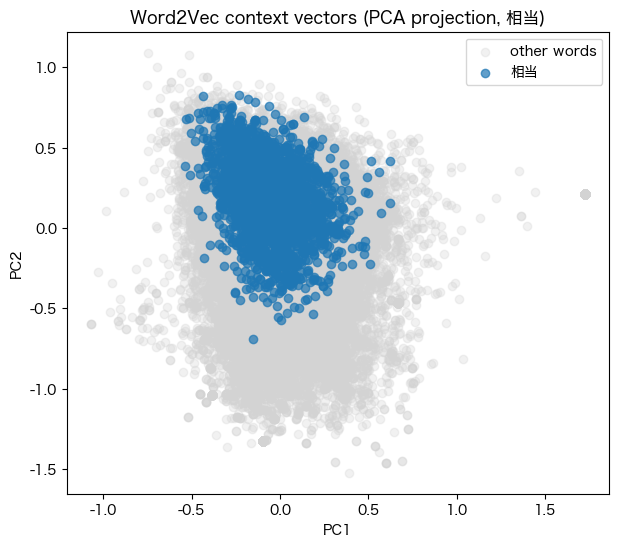

--- 相当: PC1 low ---
  (-0.54) Chambers 発音記号も「ペナイン」相当、[http://www.visitbritain.jp/things-to-see-and-do/itineraries/walking/england/pennine-way.aspx 英国政府観光庁]もペナインでした。
  (-0.53) 　wiki:東京都大会(もしくは相当大会)入賞以上と規定しております。
  (-0.51) | 42||[[ノート:相当因果関係]]||{{n/a}}||移動されるため
--- 相当: PC1 high ---
  (+0.62) というのも「議論や試行の結果」とは、編集者たちの主観に基づくものかもしれません（ウィキペディアを閲覧している人の数に比べれば相当少ないものだと思われます）。
  (+0.62) :::::::::現時点で指摘事項は相当反映されているはずですが。
  (+0.57) 万が一私のこのど下手な説明でハポニアラさんが納得されたのであれば即時削除を貼ればいいだけですし、そうでない場合ももしワーナー成増さんが削除が相当だと考えた場合は削除依頼を提出するでしょう。
--- 相当: PC2 low ---
  (-0.69) 相当我慢しました。
  (-0.57) 芦毛沢温泉の記事ですが、大変申し訳ありませんがstub相当です。
  (-0.56) 貴方のやってることは対話拒否にあたり、投稿ブロック（二度目ですので長期ですね）に相当します。
--- 相当: PC2 high ---
  (+0.83) [[県]]⇔[[:en:Prefecture]]」や「[[大佐]]⇔[[:en:Colonel]]」は、同程度の規模や権能を持つ地方の行政機関や軍隊の相当する階級へのリンクであり、根本的に違います。
  (+0.82) 　　　“是的少爷”，因为刚才那句话的威慑，二皇子对楚风越发的恭敬了，因为二皇子在楚风的时间相当于说是最多的，而且二皇子已经看见了楚风的许多强悍的东西，就比如那个可以加快凝炼魔力的魔法阵，自己是亲身体会了的，如果楚风愿意大规模的使用的话。
  (+0.80) [[アメリカ合衆国]]は相当な大国なので'''そもそも、[[コソボ]]がニュースになっているから'''といわれるのもわかりません。


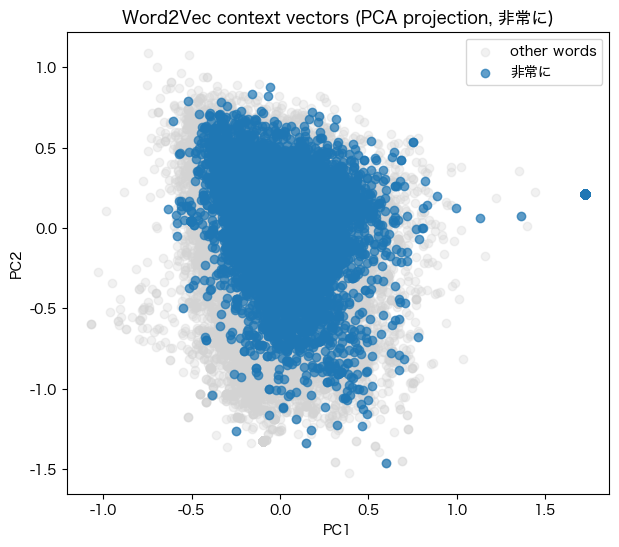

--- 非常に: PC1 low ---
  (-0.64) == 非常に短い記事・無出典記事の作成はおやめください ==
  (-0.61) また、非常に[[因島市]]にご愛着がおありのようですが、他の方もおっしゃっていますが、何でもかんでも記述する前に「[[WP:NOT]]」をお読みください。
  (-0.59) == 非常に短いイラストレーターについての記事作成中止のお願い ==
--- 非常に: PC1 high ---
  (+1.72) ウィキペディア日本語版の運営にも深く関与する理事会の[[:m:Wikimedia Foundation elections/2021/Candidates/ja|候補者]]の選出に際し、投票資格をお持ちの数少ないユーザーの一人であるDays for archaeologyさんのご意見を反映することは非常に重要だと考えています。
  (+1.72) ウィキペディア日本語版の運営にも深く関与する理事会の[[:m:Wikimedia Foundation elections/2021/Candidates/ja|候補者]]の選出に際し、投票資格をお持ちの数少ないユーザーの一人であるBonfire12さんのご意見を反映することは非常に重要だと考えています。
  (+1.72) ウィキペディア日本語版の運営にも深く関与する理事会の[[:m:Wikimedia Foundation elections/2021/Candidates/ja|候補者]]の選出に際し、投票資格をお持ちの数少ないユーザーの一人であるSigurejoさんのご意見を反映することは非常に重要だと考えています。
--- 非常に: PC2 low ---
  (-1.46) 非常に助かります。
  (-1.34) 非常に助かりました。
  (-1.26) 非常に有難うございました／御苦労さまでした！
--- 非常に: PC2 high ---
  (+0.88) 非常に著名な作家の小説や、著名な学者の歴史的に見て重要な論文であるならば当然記載して言及されて然るべきでしょうが、そうとはいえないものまで網羅的に載せることは推奨されません。
  (+0.83) [[非常に小さい素数]]を編集しておられましたが、[[:en:Minimal prime (recreation

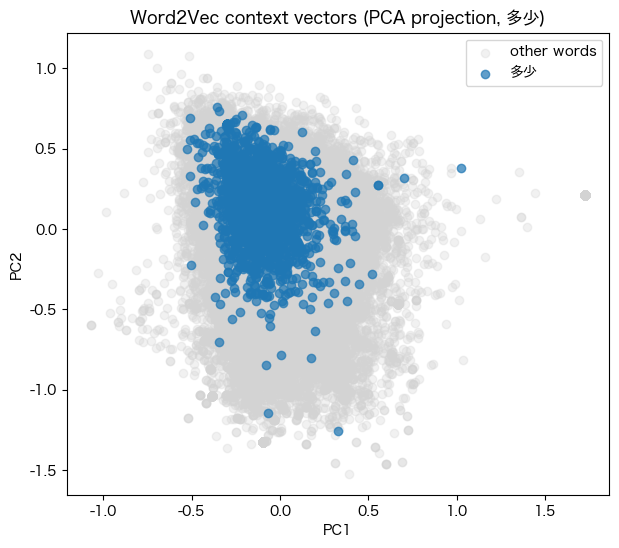

--- 多少: PC1 low ---
  (-0.53) とにかく、他は多少は・・・と言うのも無いでもありませんが、著作権侵害が繰り返される虞がある限りは、ブロックの解除は困難であるとお心得頂くとよろしいかと思います。
  (-0.51) 多少の誤植（誤字脱字など、内容に響かないもの）は訂正できますので信頼性には大きく響きません{{smaller|（酷いほど多ければ別ですが）}}。
  (-0.51) :::: 多少の「文字の誤字脱字」はまあ仕方がないですが、それ以外でも連続投稿をされているように見えます。
--- 多少: PC1 high ---
  (+1.03) 多少理不尽な意見の中にだって、もしかしたら建設的な物があるかもしれません。
  (+0.70) 多少補足意見を書き記してあります。
  (+0.55) 今回の私の愚意を意識して戴き、今後Geistlichさんの編集方針に多少なりとも反映して戴ければ幸いで御座居ます。
--- 多少: PC2 low ---
  (-1.26) 多少お許しください。
  (-1.15) 多少長文失礼いたしました。
  (-0.85) バイオバーデンと滅菌の記事には、Akanijiさんの御返事を参考にさせていただいて多少加筆いたしました。
--- 多少: PC2 high ---
  (+0.76) 多少の「アンチDump」が現れているわけではなく、「Dump氏がまっとうな提案に対してちゃんと応対しないのでしびれを切らしているひとが続出している」ということであると思います。
  (+0.74) 没人多少中国人认为政治不需要改革。
  (+0.71) とりわけ、多少思い出のある[[レティーロ (ブエノスアイレス)]]区の記事が作成されていたのには感激いたしました。


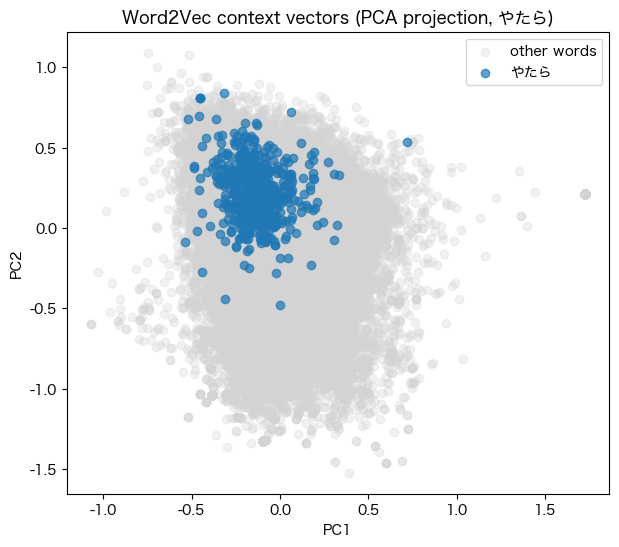

--- やたら: PC1 low ---
  (-0.54) == やたらに貴方が問題になるのは、何かがあるのかも？
  (-0.52) :＞無闇やたら
  (-0.49) 　むやみやたらに、WikipediaのURLを参照にしなさんな。
--- やたら: PC1 high ---
  (+0.72) やたらと「意見を変える」といって意見を変えたことすら表明もしない、釈明もしないで実際の発言とは異なる編集をする利用者がウィキペディアで避難されるケースはよくありますよ。
  (+0.33) ::#自分の意見をやたらと宣伝したがる
  (+0.32) '''こんにちは、かもゆかもやたらさん。
--- やたら: PC2 low ---
  (-0.48) やたらめったら付け加えないようお願いします。
  (-0.44) 上では説明をかなりすっとばして手順だけやたら書いてしまいましたが、今回も取り急ぎ手順のみ。
  (-0.28) ただ、Janpaulさん、今まで私がやってきたことをやたらちお噛みついて来たりと私のことを邪魔者だと思っていませんか？
--- やたら: PC2 high ---
  (+0.84) むやみやたらに「登場作品」を記述することは好ましく無いというのがコンセンサスです。
  (+0.81) [[ノート:東京放送ホールディングス#関連記事でやたらと「TBSホールディングス」に書き換えられる件]]にてご回答お願いします。
  (+0.81) 再度修正される場合は、その理由を[[ノート:東京放送ホールディングス#関連記事でやたらと「TBSホールディングス」に書き換えられる件|ノートページ]]にて回答ください。


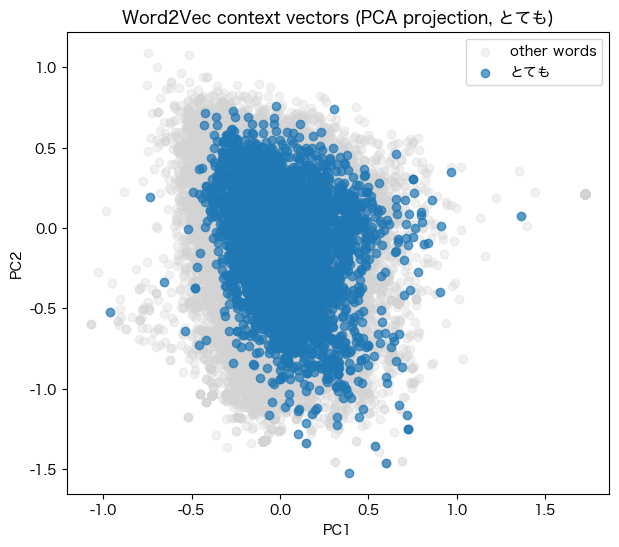

--- とても: PC1 low ---
  (-0.96) == とてもひどい ==
  (-0.74) 　私　は　日本語　が　とても　へた　です。
  (-0.66) == 私はとても悔しい ==
--- とても: PC1 high ---
  (+1.36) とても重要なことだと思います。
  (+0.97) :とても貴重なご意見ありがとうございます。
  (+0.91) 実際、面倒な解説書を読まなくても老若男女、国籍を問わずみな直感で操作していますから、人間の性質を理解することはとても重要だと思うのです。
--- とても: PC2 low ---
  (-1.52) とても嬉しくありがとうございます。
  (-1.46) とても助かります。
  (-1.36) とても感謝いたします。
--- とても: PC2 high ---
  (+0.76) タマモクロスはとても人気のある馬ですから、多くの利用者が関心を持っています。
  (+0.74) とても有名なタレントさんであれば、宣伝にはならないでしょう。
  (+0.73) [[高柳光寿]]氏はとても有名な歴史学者です。


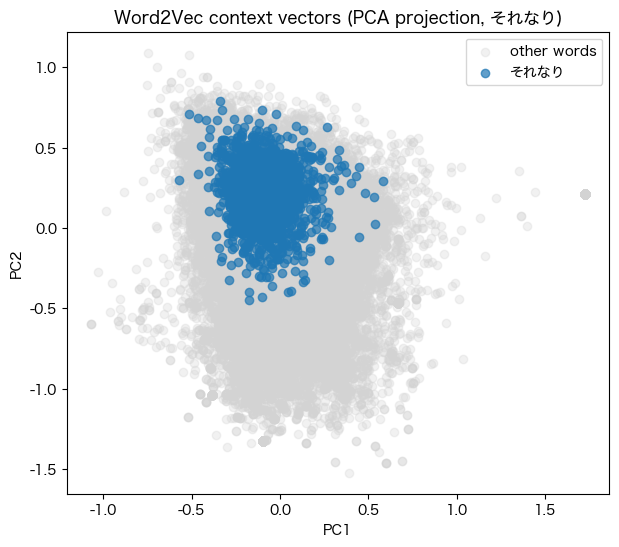

--- それなり: PC1 low ---
  (-0.57) 　　　それなりの扱いをさせていただきます。
  (-0.51) それなりの[[Wikipedia:著名性]]を確保した応援団も存在します。
  (-0.47) SUM-946Eさんが編集された[[谷村有美]]、[[谷村有美のそれなりに+]]について、編集の取り消し提案を[[ノート:谷村有美のそれなりに+#コミュニティFM局関連の記述削除について取り消し提案|ノート:谷村有美のそれなりに+]]で行っております。
--- それなり: PC1 high ---
  (+0.58) カヴァー曲がオリコントップ10入りをしたということで作品としての記事の重要性はそれなりにあると思い単独記事を書き上げてみましたが、ジョバンニが一晩でやってくれましたさんのおっしゃる通り、[[Wikipedia:ウィキプロジェクト 楽曲]]の「統合・分割関連」に合わせました。
  (+0.54) 　なお、ほかの方のご意見もちゃんとそれなりに取り入れておりますので、現在過去以外で「これってよくよく考えると不要だよね？」っていうのがありましたら、「どうですか？」と私に投げかけてください。
  (+0.53) 私は上掲の再掲文のように常にWikipediaの「目的」や「方針」や「ガイドライン」などのルールに実際に文字で書かれていることのみを根拠として意見を言っているのですが、私への反対意見は上掲の例のようにルールを勘違いしたものや「ルールにはそう書かれていても当てはまらない（と思う）」「ルールにはそう書かれていなくても、それはルールに反する（と思う）」というようなものが大半です（そういう意見はそれなりにＯＫと思いますが、私がそういうことを言えば「独自研究」とされ議論にならず否定されますから極めてアンフェアなロケーションです。
--- それなり: PC2 low ---
  (-0.45) 　思い返せば…ですが貴殿も私もPooh456さんに対して事前警告を行ってきましたしそれなりに助言もしてきました。
  (-0.43) これ以上問題のIPユーザー馬鹿にするようでしたら、それなりに対処しますのでよろしくお願いします。
  (-0.40) 次、このようなことがございましたら、それなりの対処を管理者にお願いすることがありますので、ご了承ください。

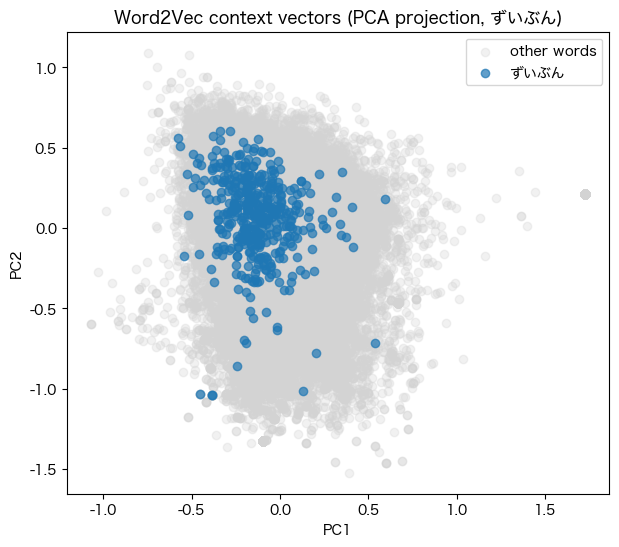

--- ずいぶん: PC1 low ---
  (-0.58) ::ずいぶん以前に、[[ホショト]]のノートに典拠をご提示いただいていたのを確認。
  (-0.57) ずいぶん前に[[Wikipedia‐ノート:カテゴリの方針/ 2010年までの過去ログ#本項目と同名カテゴリ]]で議論された形跡はあるのですが、議論の成果がカテゴリ関連の方針文書や実際の編集に反映されてこなかったようです。
  (-0.54) ::::ずいぶん遅くなってしまいましたが、当時にご丁寧に注意いただいたこと、御礼申し上げます。
--- ずいぶん: PC1 high ---
  (+0.60) ずいぶんとご立派な思考回路ですね。
  (+0.53) ずいぶん早くご連絡頂けたことを幸いに思います。
  (+0.41) ずいぶんご無沙汰しています。
--- ずいぶん: PC2 low ---
  (-1.04) ずいぶん遅くなりましたが、[[木村草弥]]を編集してみました。
  (-1.04) ずいぶん遅くなりました。
  (-1.03) ずいぶん遅くなってしまい、申し訳ありません。
--- ずいぶん: PC2 high ---
  (+0.61) （ずいぶん性格の違うソフトですが）[[特別:ContentTranslation]]の翻訳先は自由に指定できるようなので、[[:en:Cloth hall]]の翻訳先として[[user:ツバル/sandbox1]]を指定して動かしてみました。
  (+0.60) ずいぶんと難波学園に固執しているようですが、事実と異なることをネットを使い公にしていると、逆に訴えられてしまいます。
  (+0.57) :::::ずいぶんと世間を小ばかにした方のようです。


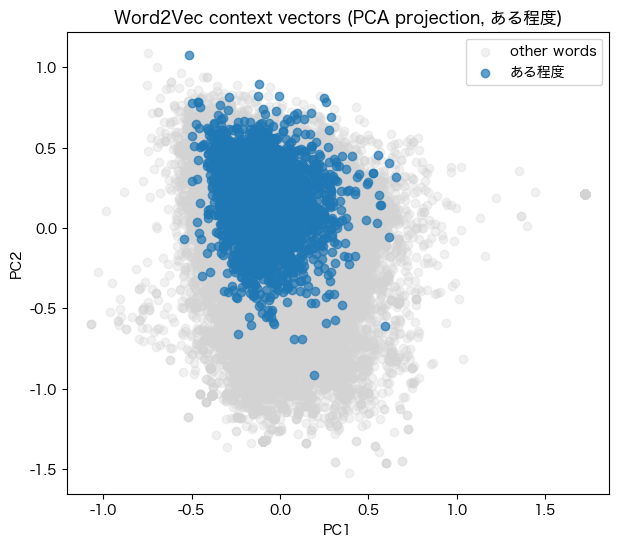

--- ある程度: PC1 low ---
  (-0.55) :::::*:ある程度確認終わりました。
  (-0.51) ある程度[[ウマ#人間によるウマ利用の歴史]]に委ね（加筆の余地はありますけど）、[[クセノポン]]に触れてから、ルネサンスで再発見させましょうか。
  (-0.50) それで北小学校についてなんですがとらもん192様が加筆してくださった施設需要に西棟と書かれていますが、私は北小学校出身である程度は北小学校について詳しいのですが、西棟と言うところが記憶に存在しません。
--- ある程度: PC1 high ---
  (+0.66) 「記事全体がその事物の「解説」であるはず」とのご意見もある程度は理解できるのですが、記事には出典や外部リンクなど、「解説」とは直接関係しない内容の節も含まれるので、その事物の主要事項を記載した節に「解説」という名を付すことに特段の問題はないと思う次第です。
  (+0.62) あなたが日本語が書けないにしても、ノートのいろいろな意見は読めばある程度分かるでしょう。
  (+0.62) 今の状態では、擁護意見が圧倒的に多いので、文章を抽出・整理した上で、誤審に批判的な意見をある程度バランスよく載せるべきじゃないかと思われます。
--- ある程度: PC2 low ---
  (-0.91) ある程度お待ちしますが、出典が示されない場合には独自研究として該当記述を除去しますので、ご留意願います。
  (-0.69) :ある程度ですよね、ある程度。
  (-0.69) ある程度答えたぞ。
--- ある程度: PC2 high ---
  (+1.08) ある程度[[ウマ#人間によるウマ利用の歴史]]に委ね（加筆の余地はありますけど）、[[クセノポン]]に触れてから、ルネサンスで再発見させましょうか。
  (+0.90) 一般＝ある程度の人数の人々（または、それより多人数の人々）　であって　一般＝世間一般　とは限りません。
  (+0.82) 韓国国内に旭日旗を絡めて相手を貶めるという文化的な下地があったから、奇誠庸の主張もある程度は韓国国内で支持されたのであって、奇誠庸が契機になって旭日旗への非難が行われるようになったというのは違うのではないかということです。


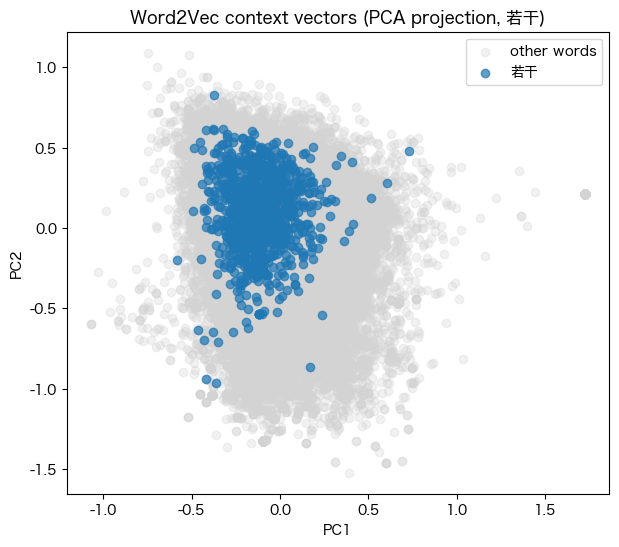

--- 若干: PC1 low ---
  (-0.58) 私としてもOrcanoさんがいつまでも(2011年ワン県)に拘り続けているようにも見えて来ましたし、彼方陣さんにつきましても[http://ja.wikipedia.org/w/index.php?title=%E3%83%8E%E3%83%BC%E3%83%88%3A%E3%83%88%E3%83%AB%E3%82%B3%E6%9D%B1%E9%83%A8%E3%83%AF%E3%83%B3%E5%9C%B0%E9%9C%87_%282011%E5%B9%B4%29&action=historysubmit&diff=40806096&oldid=40804758 若干苦言]めいたことも仰っていますし、それぞれがちょっと熱くなっているんじゃないか感はあると思います。
  (-0.49) [http://ja.wikipedia.org/w/index.php?title=%E9%BB%92%E5%B2%A9%E5%88%A9%E9%9B%84&oldid=42293937 こちらの記事]なのですが、私にはどうしても即時削除に見えませんため、[http://ja.wikipedia.org/w/index.php?title=%E9%BB%92%E5%B2%A9%E5%88%A9%E9%9B%84&oldid=42295784 若干の整形とsdタグの除去を行いました]。
  (-0.48) つまりもともと記法に若干の（しかし文法上致命的な）問題点があり、私がそれに上書きで自動処理をかけたため、今回の問題が起こったと考えられます。
--- 若干: PC1 high ---
  (+0.73) 若干とりとめのない意見となってしまいましたが、意図は通じましたでしょうか？
  (+0.61) その上で、パウロ２００３さんの意見に若干腑に落ちない点がございますのでご説明させて頂きたいと思います。
  (+0.52) 文字のみのお付き合いですので、誤解を生じやすいですが、若干のご意見を交換させていただきたいだけであり、他意ありませんのでなにとぞご理解よろしくお願いいたします。
--- 若干: PC2 low ---
  (-0.97) 返信が若干遅れてしまい申し訳ありません。
  (-0.94) 若干返事が遅れましてす

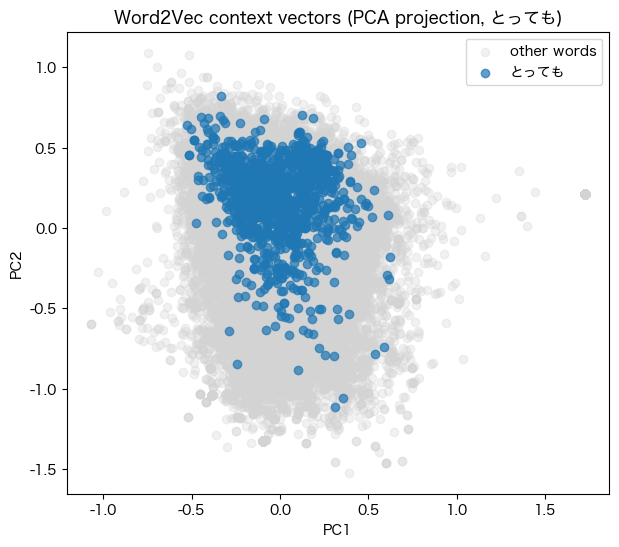

--- とっても: PC1 low ---
  (-0.53) Kokoron21さんは『学会員にとってもこれらの動画は「信仰心や教義を侮蔑する」存在であることは間違いな』いと記述されていますが、文中の「学会員」が創価学会員を指すものとして、彼らがそのように考えているという根拠はあるのでしょうか。
  (-0.51) また、大野裕之のウェブサイトには著書としてですが本書が挙げられています<ref>{{Cite web |title=大野裕之／劇団とっても便利 |url=http://www.
  (-0.51) ISBN 978-0-7864-2425-2<ref>{{Cite web |title=大野裕之／劇団とっても便利 |url=http://www.
--- とっても: PC1 high ---
  (+0.62) 管理者伝言版へ荒らしとして報告し、しかるべき対処をとってもらうことを考えます。
  (+0.61) とっても大変だと思うのに頑張ってくださっているPenn Stationさまに感謝いたします。
  (+0.61) やはりこのお方のご意見はとっても参考になります、以後気をつけていかないとね(*･ω･*)
--- とっても: PC2 low ---
  (-1.11) とっても感謝です。
  (-1.06) とっても嬉しいです。
  (-0.88) とっても嬉しかったです。
--- とっても: PC2 high ---
  (+0.82) たとえばあなたが係わった北支の｢第1軍｣隷下部隊をとっても｢野戦機関砲中隊｣一個が抜けています。
  (+0.70) 白拍子花子さんにとっても極めて関係のある話題かと思いますので、ぜひチェックしてみてください。
  (+0.70) いえ、地元の[[小売店]]主にとってもコンビニは出歯るかもしれません。


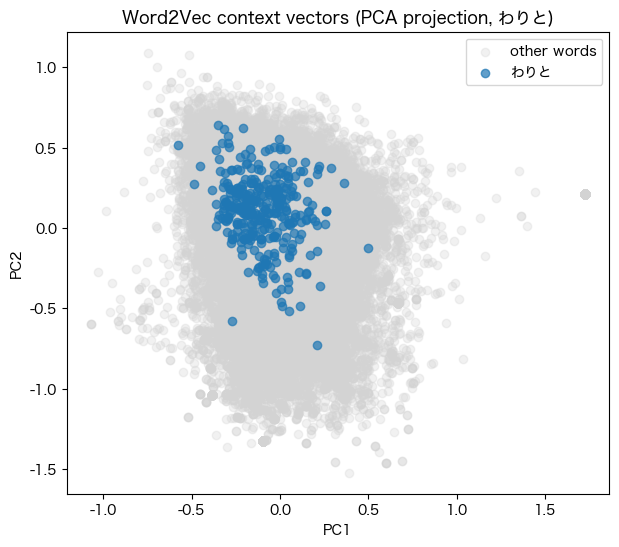

--- わりと: PC1 low ---
  (-0.58) *わりと最近に[[WP:TRANS|翻訳のガイドライン]]というルールができています。
  (-0.49) *執拗にコピペ呼ばわりと言う前に、まず、自分がきちんとされたらいかがですか。
  (-0.45) 出没頻度：わりと頻繁
--- わりと: PC1 high ---
  (+0.50) 私は必要であるか必要でないかという意見を書いたのでその部分だけ引用されましたが「和暦を使った方が説明をしやすい記事（例えば、令和元年5月1日(元号改変日)に発売した）などは記載しても良いかと思います。」の併用する理由があるなら併用してもいいんじゃないという部分はわりと重要です。
  (+0.36) メモリースティックと深い関わりという点で重要があると思い、95のFAT利用に関してもそうですが、ソニー製品に使われる目的として生まれた意味も強いメディアです。
  (+0.29) おれの推測では、Mariemonさんは、わりとご年配の方であり、インターネットやWikipediaにはいまのところたいして慣れていないのではないかと思います。
--- わりと: PC2 low ---
  (-0.73) そちらをもって返信は終わりといたします。
  (-0.58) 終わりと言いましたが、最後に一つ。
  (-0.51) 「コメント依頼、投稿ブロック依頼の提出の多さ（正直いえば、あまりに提出ペースが多くないでしょうか…？）」<br>「言葉の端々でのニュアンス的なこと。もう少しやんわりとした言い方ができれば、より望ましいのでは…？（言い方に「とげがある」ように感じることが、意見を何回か拝読する機会があったときに、正直自分の中では感じたのです。自分の思い過ごしならばよいのですけど）」
--- わりと: PC2 high ---
  (+0.64) : 電波時計でもわりと保守や気候によって[https://twitter.com/JJY_NICT 停波します]ので、1秒 単位のずれも避けたい状況では stratum 1　の [[NTP]] サーバーである [[NICT]] の https://www.
  (+0.62) :::わたしのウィキペディアの項目の編集の論理（ロジック）や指摘のしかたは、わりと"学術的"なのかも知れません。
  

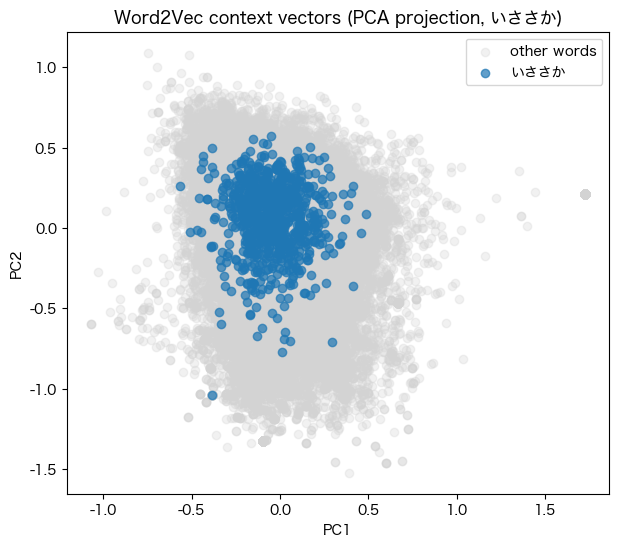

--- いささか: PC1 low ---
  (-0.56) しかし、いささか[http://ja.wikipedia.org/wiki/%E5%88%A9%E7%94%A8%E8%80%85:Himetv]の編集は乱暴な気がしますが。
  (-0.51) == いささか主観に寄り過ぎです。
  (-0.47) (1) 記事「[[太田哲三]]」について、私の会話にあなたからご連絡がありましたが（[https://ja.wikipedia.org/w/index.php?title=利用者‐会話%3APooh456&type=revision&diff=67510472&oldid=67178229 差分]）いささか文意が分かりかねるご連絡でしたので、「[[ノート:太田哲三#太田の肩書について]]」に議論の場を設け、私の見解を詳しく書きました。
--- いささか: PC1 high ---
  (+0.49) 「『F1レーシング日本版』　6月情報号、三栄書房、2008年、64頁」の記事たったひとつを以って、'''後の評価'''とするのはいささか乱暴だと思います。
  (+0.46) いささか、ご対応としては残念です。
  (+0.41) そういえば、ヤロスラヴ賢公は「ツァーリ」だけでなく、「カハン」とよばれたことがありますが、「カハン」は彼の称号であったことは、いささか考えがたいです。
--- いささか: PC2 low ---
  (-1.04) いささか遅くなりましたが、ButuCCさんの誤解について説明します。
  (-0.77) いささか失礼に思いました。
  (-0.71) いささか疑問です。
--- いささか: PC2 high ---
  (+0.57) 申しあげるべきかと思いますので、大変失礼なことを申しあげますと、最初のあまり友好的でない（お言葉をお借りしますと書き投げの）コメントや、投稿履歴などを拝見した際に、特に政治や経済やその他社会に関する記事において自覚的・非自覚的を別にしてなにかしらの政治イデオロギーに大きく基づいた記事の編集・削除をなさっているのではないかとも思い、本件もその一つであるかもしれないと考えました（彼のお弟子さんの荻原博子さんは、安倍政権の政策にいささか否定的な見解を示したようです）。
  (+0.55) 早速ではございます

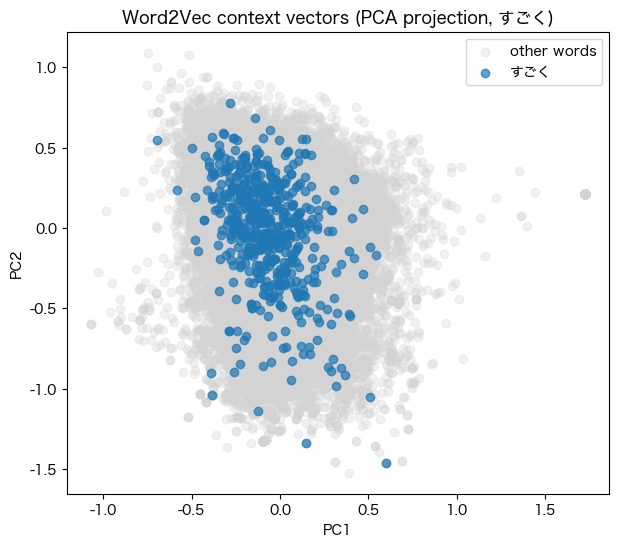

--- すごく: PC1 low ---
  (-0.69) ものすごく心苦しい・・・。
  (-0.58) == 「すごくおいしいうた」の記述について ==
  (-0.50) ::あの～・・・ものすごく今寝耳に水な感じになっていますが・・・どういう事なのかが詳しく書かれていないので、今、ものすごく動揺しており・・・分かりません。
--- すごく: PC1 high ---
  (+0.60) すごく助かります。
  (+0.54) 日本と各国との関係については記事が不足気味であったことから作成していただくことはものすごく素晴らしいことだと思うのですが、あれはいずれも外国版の翻訳で参考文献もありません。
  (+0.51) すごくうれしいよ。
--- すごく: PC2 low ---
  (-1.46) すごく助かります。
  (-1.34) すごく助かりました。
  (-1.14) すごく疲れました。
--- すごく: PC2 high ---
  (+0.78) <nowiki>{{保護依頼|七之輔20110205}}</nowiki>とかわざわざ改変するの、<font color="red">'''ものすごく陰湿'''</font>で<font color="red">'''かっこわるい'''</font>ですよ。
  (+0.69) 屁理屈でどうこう言っている訳では無いのです…仮に私が札幌の薄野のすごくおいしいラーメン屋さんを発見したとします。
  (+0.61) 確かにあれはすごく難しい案件ではありましたけど、Hideokun同志の「被依頼者の投稿ブロックに積極的ではないですが、逆に問題が全くないとも思わないのでコメントといたします。今まで独自の国としてではなく、様々な国の地域として扱われてきたウクライナの歴史における悲劇の部分が端的に出ているように感じます。現状、ウクライナは自らの歴史を再考している時期であり、視点を変えれば様々な考え方が現れるのもいたしかたありません。ですので今回の諍いもやむを得ない部分があることも感じます。ただ、その部分でガイドラインにもありますが、『これはウィキペディア日本語版なので、わたしたちの読者に便利なように、日本語の情報源はできるだけ提供されるべきであり、外国語の情報源より常に優先して使われるべきです』となっており、ウクラ

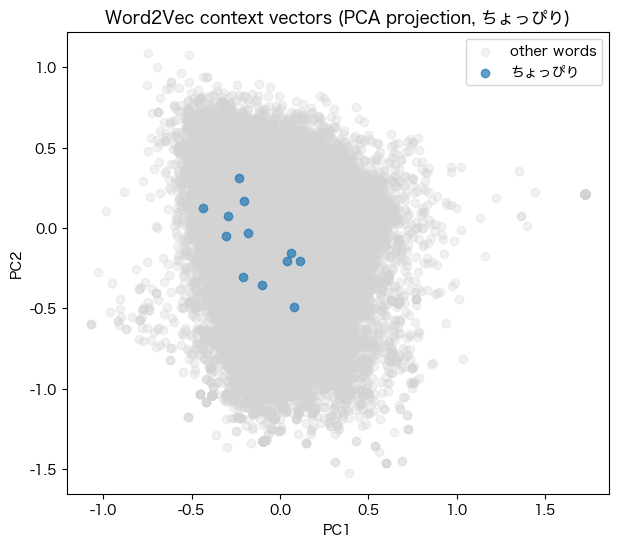

--- ちょっぴり: PC1 low ---
  (-0.44) * 恋をちょっぴり忘れたあなたに（[[AbemaTV]]）
  (-0.30) いくつか私が書いた項目にリンクとしてつながっていることも、手前味噌ながらちょっぴり誇らしかったりしますf^^;。
  (-0.29) 長文だったため今までのように読んでいないp tmpでも読めるように文章を、ほんのちょっぴりだけ丁寧に文章を清書しました。
--- ちょっぴり: PC1 high ---
  (+0.12) 何となく上げたコモンズ画像が、他言語の思わぬプロジェクトで使われてたりすると、ちょっぴりうれしいものですよ。
  (+0.08) 記事の性質上やむを得ないですが、固有名詞が多く、読むのに少々骨が折れる点がちょっぴり大変でした。
  (+0.06) ただ、正直言って、ちょっぴり面倒くさい人だとは思っておりますがね。
--- ちょっぴり: PC2 low ---
  (-0.49) 記事の性質上やむを得ないですが、固有名詞が多く、読むのに少々骨が折れる点がちょっぴり大変でした。
  (-0.35) Nakaoka7675さんがノータッチの記事も「翻訳した記事」の中に含まれていたのでちょっぴり気になりました。
  (-0.31) でも後に、削除議論の途中に割り込んで私への個人批判を書かれた時には、正直ちょっぴりがっかりしました。
--- ちょっぴり: PC2 high ---
  (+0.31) 私は季節をちょっぴり先取りし、多数の書籍を購入して、空いた時間に「読書の秋」を堪能しております。
  (+0.17) 明らかにシューマン家とアルカンに、面識はちょっぴりあったのです。
  (+0.13) * 恋をちょっぴり忘れたあなたに（[[AbemaTV]]）


In [ ]:
# Fit PCA ONCE on all words together, then reuse the same projection for every
# subplot below -- this is what makes the per-word plots comparable to each
# other and to the "all words" plot (same PC1/PC2 axes throughout).
w2v_pca2, w2v_coords2, w2v_labels2 = fit_pca_projection(w2v_vectors_by_word)

# use the same axis limits everywhere, based on the full range of points (with a small margin)
# -- word2vec vector scale is different from BERT's, so we compute this instead of reusing
# the BERT xlim/ylim values.
margin = 0.05
x_range = w2v_coords2[:, 0].max() - w2v_coords2[:, 0].min()
y_range = w2v_coords2[:, 1].max() - w2v_coords2[:, 1].min()
w2v_xlim = (w2v_coords2[:, 0].min() - margin * x_range, w2v_coords2[:, 0].max() + margin * x_range)
w2v_ylim = (w2v_coords2[:, 1].min() - margin * y_range, w2v_coords2[:, 1].max() + margin * y_range)

plot_pca_scatter_precomputed(w2v_coords2, w2v_labels2, words,
                              "Word2Vec context vectors (PCA projection, all words)")

# show dots separated by word because colors are hard to distinguish when there are many words.
for word in words:
    # same xlim/ylim (and same underlying PCA fit) for every word so the plots are directly comparable.
    plot_pca_scatter_precomputed(
        w2v_coords2, w2v_labels2, [word],
        f"Word2Vec context vectors (PCA projection, {word})",
        xlim=w2v_xlim, ylim=w2v_ylim,
    )

    # show sentences at each end of the PCA projection (for this word's own points)
    mask = w2v_labels2 == word
    coords = w2v_coords2<mask>
    sents = w2v_sentences_by_word[word]
    for axis, name in [(0, "PC1"), (1, "PC2")]:
        order = np.argsort(coords[:, axis])
        print(f"--- {word}: {name} low ---")
        for i in order[:3]:
            print(f"  ({coords[i, axis]:+.2f}) {sents[i]}")
        print(f"--- {word}: {name} high ---")
        for i in order[-3:][::-1]:
            print(f"  ({coords[i, axis]:+.2f}) {sents[i]}")


The same dimension-analysis functions work on the Word2Vec vectors too — just swap in `w2v_vectors_by_word` / `w2v_sentences_by_word`.

In [73]:
w2v_pca, w2v_pc_scores, w2v_pc_sentences, w2v_pc_labels = pca_dimension_analysis(
    w2v_vectors_by_word, w2v_sentences_by_word, n_components=5
)
show_pc_extremes(w2v_pc_scores, w2v_pc_sentences, w2v_pc_labels, component=0, top_k=5)
show_pc_range(w2v_pc_scores, w2v_pc_sentences, w2v_pc_labels, component=0, n_bins=5, examples_per_bin=3)


Explained variance ratio per component:
  PC1: 0.113 (11.3%)
  PC2: 0.087 (8.7%)
  PC3: 0.073 (7.3%)
  PC4: 0.051 (5.1%)
  PC5: 0.046 (4.6%)
  cumulative (first 5): 0.368
=== PC1 — low extreme ===
  [ちょっと] (score=-1.07) ==ちょっと==
  [少し] (score=-1.07) == 少し ==
  [ちょっと] (score=-1.07) == ちょっと ==
  [やや] (score=-1.03) == ややや ==
  [ちょっと] (score=-0.99) == ちょっと・・・ ==

=== PC1 — high extreme ===
  [非常に] (score=+1.72) ウィキペディア日本語版の運営にも深く関与する理事会の[[:m:Wikimedia Foundation elections/2021/Candidates/ja|候補者]]の選出に際し、投票資格をお持ちの数少ないユーザーの一人であるJjjj1475さんのご意見を反映することは非常に重要だと考えています。
  [非常に] (score=+1.72) ウィキペディア日本語版の運営にも深く関与する理事会の[[:m:Wikimedia Foundation elections/2021/Candidates/ja|候補者]]の選出に際し、投票資格をお持ちの数少ないユーザーの一人であるKt footballさんのご意見を反映することは非常に重要だと考えています。
  [非常に] (score=+1.72) ウィキペディア日本語版の運営にも深く関与する理事会の[[:m:Wikimedia Foundation elections/2021/Candidates/ja|候補者]]の選出に際し、投票資格をお持ちの数少ないユーザーの一人であるテルちゃんさんのご意見を反映することは非常に重要だと考えています。
  [非常に] (score=+1.72) ウィキペディア日本語版の運営にも深く関与する理事会の[[:m:Wikimedia Foundation elections/20

In [80]:
w2v_word_profile = word_mean_scores_table(w2v_pc_scores, w2v_pc_labels, n_components=5)
w2v_word_profile.sort_values("PC4", ascending=False)


,PC1,PC2,PC3,PC4,PC5
word,,,,,
大変,-0.024119,-0.336808,0.143067,0.160422,0.013357
とっても,-0.001848,0.198573,0.045034,0.089005,0.136434
あまり,-0.067459,0.104500,-0.070502,0.036208,-0.029270
やや,-0.109670,0.103012,-0.009323,0.005324,-0.047096
いささか,-0.048314,0.064957,-0.069342,0.003870,-0.075355
それなり,-0.087982,0.213100,-0.064055,0.003867,0.066088
結構,-0.045948,-0.158900,-0.113874,0.003652,-0.023450
多少,-0.109755,0.131417,-0.049026,-0.002525,0.025228
すごく,-0.070790,-0.022586,0.016445,-0.003158,-0.039152


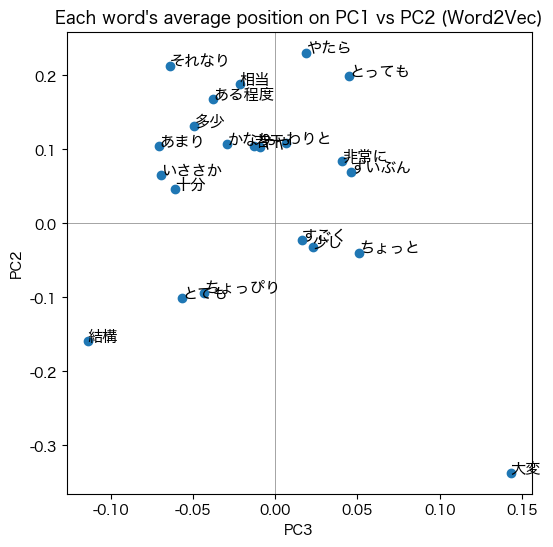

In [77]:
plt.figure(figsize=(6, 6))
plt.scatter(w2v_word_profile["PC3"], w2v_word_profile["PC2"])
for word, row in w2v_word_profile.iterrows():
    plt.annotate(word, (row["PC3"], row["PC2"]), fontsize=11)
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.xlabel("PC3")
plt.ylabel("PC2")
plt.title("Each word's average position on PC1 vs PC2 (Word2Vec)")
plt.show()


## Save results

Export the matrices and word profiles to CSV for use outside the notebook.

In [ ]:
bert_sim_matrix.to_csv("bert_similarity_matrix.csv")
bert_accuracy_matrix.to_csv("bert_distinguishability_matrix.csv")
bert_word_profile.to_csv("bert_word_pc_profile.csv")
w2v_sim_matrix.to_csv("word2vec_similarity_matrix.csv")
w2v_accuracy_matrix.to_csv("word2vec_distinguishability_matrix.csv")
print("saved 5 CSV files")


## Interpreting the results

- **Centroid cosine similarity matrix**: higher = that pair's typical usage contexts are more alike overall.
- **Pairwise distinguishability matrix (classifier CV accuracy)**: near 0.50 = hard to tell the pair apart (near-interchangeable usage); near 1.0 = clearly distinct usage niches. Often more informative than raw cosine similarity since it accounts for how spread out each word's own usage is.
- **Scree plot**: how much of the total variation across all words' examples is captured by the first few PCs. If PC1 alone explains a large share, there's likely one dominant axis of variation across your modifiers.
- **PC extremes (read the sentences)**: this is where you actually find out what a dimension of variation *means* — e.g. one axis might separate hedged/uncertain statements from confident assertions, another might separate formal from casual register, another might track sentence length or negation.
- **Word profile table / PC1 vs PC2 scatter**: shows which words systematically lean toward one end of each axis — this is the closest thing to "the dimensions along which these modifiers vary," grounded in what you actually read in the extreme examples rather than an assumed label.
- For a more rigorous grouping, consider hierarchical clustering (`scipy.cluster.hierarchy`) on `1 - bert_sim_matrix`.